### **WP3.6 - Final Model Evaluation, Sensitivity Analysis, and Cluster Profiles**

This notebook brings together the final WP3 model outputs and evaluates them as a clinical risk-ranking problem rather than only a yes/no classifier. The primary modelling dataset is the `shap_guided_reduced_feature_set`, with larger feature matrices kept as sensitivity checks.

##### **Notebook Outline**

- **3.6.1 Comparative model analysis**: all-model table, recommended model table, ensemble testing, and best-model selection.
- **3.6.2 Threshold analysis**: balanced precision-recall threshold, optimal F1 threshold, fixed-recall thresholds, and cost-sensitive thresholds.
- **3.6.3 High-risk strata analysis**: top-risk groups and readmission capture.
- **3.6.4 Feature-set sensitivity analyses**: full versus reduced matrices and Top-N SHAP feature subsets.
- **3.6.5 Calibration analysis**: Brier score, calibration bins, and decision-curve style summaries.
- **3.6.6 Time-frame and cutoff analysis**: cutoff-proximal errors, wider psychiatric readmission windows, and non-psychiatric marker sensitivity.
- **3.6.7 Cluster-based patient profile analysis**: broad patient-profile clusters and fixed-k sensitivity.
- **3.6.8 Statistical uncertainty and exploratory tests**: bootstrap confidence intervals, paired comparisons, and cluster-profile tests.
- **3.6.9 Final threshold and run provenance**: final operating threshold, run inputs, and model agreement checks.
- **3.6.10 Method audit and stress checks**: leakage controls, reproducibility notes, and admission-context checks.
- **3.6.11 Combined curves and exports**: final plots, workbook, and consolidated CSV-table workbook.

In [1]:
#import libraries used for final model evaluation, sensitivity checks, and reduced-feature modelling
import os
import time
import warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
from scipy import sparse
from scipy import stats
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")
import matplotlib.pyplot as plt
from collections import Counter
import re

try:
    from statsmodels.stats.proportion import proportion_confint
    proportion_confint_available = True
except Exception:
    proportion_confint = None
    proportion_confint_available = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

#gradient boosting imports are defined once here as wp3.6 also runs reduced-feature sensitivity models
try:
    from lightgbm import LGBMClassifier
    lightgbm_available = True
    lightgbm_import_error = None
except Exception as error:
    LGBMClassifier = None
    lightgbm_available = False
    lightgbm_import_error = error

try:
    from xgboost import XGBClassifier
    xgboost_available = True
    xgboost_import_error = None
except Exception as error:
    XGBClassifier = None
    xgboost_available = False
    xgboost_import_error = error

print("LightGBM available:", lightgbm_available)
if not lightgbm_available:
    print("LightGBM import error:", lightgbm_import_error)
print("XGBoost available:", xgboost_available)
if not xgboost_available:
    print("XGBoost import error:", xgboost_import_error)

Matplotlib is building the font cache; this may take a moment.


LightGBM available: True
XGBoost available: True


### **Setup Paths and Output Folders**

All WP3.6 paths are defined once here. The downstream cells should reuse these variables rather than redefining folders, which keeps the notebook easier to rerun after WP3.2-WP3.4 are refreshed.




In [5]:
#define shared project paths and output folders used across wp3.6
current_path = Path.cwd().resolve()
project_path = None
#loop through each item in this feature block
for candidate_path in [current_path] + list(current_path.parents):
    if (candidate_path / "code").exists():
        project_path = candidate_path
        break

if project_path is None:
    project_path = Path("/Users/ahthini/Desktop/DissProject")
output_path = project_path / "outputs"
wp3_input_variant = "shap_guided_reduced_feature_set"

#wp3 output folders
wp3_1_output_path = output_path / "WP3_1"
wp3_2_output_path = output_path / "WP3_2"
wp3_3_output_path = output_path / "WP3_3"
wp3_4_output_path = output_path / "WP3_4"
wp3_5_output_path = output_path / "WP3_5"
wp3_6_output_path = output_path / "WP3_6"
wp3_output_path = output_path / "WP3"
wp3_feature_audit_output_path = output_path / "WP3_feature_audit"
wp4_csv_output_path = output_path / "WP4" / "csv_tables"
wp2_3_dataset_path = output_path / "t2_3_engineered_dataset.csv"

wp3_6_csv_output_path = wp3_6_output_path / "csv_tables"
wp3_6_image_output_path = wp3_6_output_path / "images"
reduced_sensitivity_output_path = wp3_6_output_path / "reduced_feature_sensitivity"
reduced_sensitivity_csv_path = reduced_sensitivity_output_path / "csv_tables"
reduced_sensitivity_image_path = reduced_sensitivity_output_path / "images"

for folder_path in [wp3_6_output_path, wp3_6_csv_output_path, wp3_6_image_output_path,
    wp3_output_path, reduced_sensitivity_output_path, reduced_sensitivity_csv_path,
    reduced_sensitivity_image_path]:
    folder_path.mkdir(parents=True, exist_ok=True)

print("WP3 input variant:", wp3_input_variant)
print("WP3.1 input folder:", wp3_1_output_path)
print("WP3.2 input folder:", wp3_2_output_path)
print("WP3.3 input folder:", wp3_3_output_path)
print("WP3.4 input folder:", wp3_4_output_path)
print("WP3.5 neural comparator folder:", wp3_5_output_path)
print("WP3 feature audit folder:", wp3_feature_audit_output_path)
print("WP3.6 output folder:", wp3_6_output_path)
print("WP3.6 CSV table folder:", wp3_6_csv_output_path)
print("WP3.6 image folder:", wp3_6_image_output_path)
print("Reduced-feature sensitivity output folder:", reduced_sensitivity_output_path)

WP3 input variant: shap_guided_reduced_feature_set
WP3.1 input folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_1
WP3.2 input folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_2
WP3.3 input folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_3
WP3.4 input folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_4
WP3.5 neural comparator folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_5
WP3 feature audit folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_feature_audit
WP3.6 output folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_6
WP3.6 CSV table folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_6/csv_tables
WP3.6 image folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_6/images
Reduced-feature sensitivity output folder: /Users/ahthini/Desktop/DissProject/outputs/WP3_6/reduced_feature_sensitivity


### **Reusable Helper Functions**

These helpers keep the notebook tolerant of missing model folders when some WP3 notebooks have not been rerun yet.




In [6]:
#load csv only when it exists and optionally tag its source
def read_csv_if_available(file_path, dataset_label=None):
    file_path = Path(file_path)
    if file_path.exists():
        loaded_df = pd.read_csv(file_path)
        if dataset_label is not None:
            loaded_df["source_file"] = str(file_path)
            loaded_df["source_label"] = dataset_label
        return loaded_df
    print("Missing file skipped:", file_path)
    return None

#standardise threshold labels from different notebooks into one naming scheme
def normalise_threshold_role(threshold_role):
    role_text = str(threshold_role).strip().lower().replace("-", "_").replace(" ", "_")
    role_text = role_text.replace("training_f1_threshold", "official")
    role_text = role_text.replace("official_threshold", "official")
    role_text = role_text.replace("recall_sensitivity", "training_youden")
    role_text = role_text.replace("held_out", "heldout")
    if role_text in ["nan", "none", ""]:
        return None
    if "balanced_precision_recall" in role_text or "balanced_precision" in role_text:
        return "balanced_precision_recall"
    if "official" in role_text:
        return "official"
    if "selected" in role_text:
        return "selected"
    if "training_f1" in role_text:
        return "training_f1"
    if "youden" in role_text:
        return "training_youden"
    if "recall" in role_text:
        return "recall_oriented"
    if "exploratory" in role_text or "heldout" in role_text:
        return "heldout_f1"
    if "default" in role_text:
        return "default"
    if "reference" in role_text:
        return "reference"
    return role_text

#infer the threshold type from an explicit column or from the model label
def infer_threshold_role(row):
    if "threshold_role" in row.index and pd.notna(row.get("threshold_role")):
        normalised_role = normalise_threshold_role(row.get("threshold_role"))
        if normalised_role is not None:
            return normalised_role
    model_text = str(row.get("model", "")).lower()
    if "balanced precision" in model_text or "precision-recall" in model_text or "precision recall" in model_text:
        return "balanced_precision_recall"
    if "official" in model_text:
        return "official"
    if "selected" in model_text:
        return "selected"
    if "training f1" in model_text:
        return "training_f1"
    if "held-out" in model_text or "held out" in model_text:
        return "heldout_f1"
    if "youden" in model_text:
        return "training_youden"
    if "recall" in model_text:
        return "recall_oriented"
    if "default" in model_text:
        return "default"
    if "reference" in model_text:
        return "reference"
    return "reported"

#add notebook, model family, model group, and threshold context to a results table
def add_model_context(performance_df, source_notebook, model_family, model_group):
    performance_df = performance_df.copy()
    performance_df.insert(0, "source_notebook", source_notebook)
    performance_df.insert(1, "model_family", model_family)
    performance_df.insert(2, "model_group", model_group)
    performance_df["threshold_role_normalised"] = performance_df.apply(infer_threshold_role, axis=1)
    return performance_df

#find the predicted risk/probability column in a saved prediction table
def find_probability_column(prediction_df):
    probability_candidates = [column for column in prediction_df.columns
        if "prob" in column.lower() or "risk" in column.lower()]
    if probability_candidates:
        return probability_candidates[0]
    raise ValueError("No probability column found in prediction file.")

#find the true outcome column in a saved prediction table
def find_outcome_column(prediction_df):
    outcome_candidates = ["readmitted_30d", "true_readmitted_30d", "y_true", "outcome", "label"]
    #loop through each item in this feature block
    for column in outcome_candidates:
        if column in prediction_df.columns:
            return column
    raise ValueError("No outcome column found in prediction file.")

#calculate threshold-based classification metrics from predicted probabilities
def evaluate_probability_at_threshold(model_label, y_true, y_probability, threshold):
    y_predicted = (np.asarray(y_probability) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_predicted, labels=[0, 1]).ravel()
    return {"model": model_label,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_predicted),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_predicted),
        "precision": precision_score(y_true, y_predicted, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_predicted, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "f1_score": f1_score(y_true, y_predicted, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc_average_precision": average_precision_score(y_true, y_probability),
        "brier_score": brier_score_loss(y_true, y_probability),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp}

#load saved predictions and standardise probability, outcome, and model context columns
def load_prediction_file(file_path, source_notebook, model_family, model_group):
    prediction_df = read_csv_if_available(file_path)
    if prediction_df is None:
        return None
    probability_column = find_probability_column(prediction_df)
    outcome_column = find_outcome_column(prediction_df)
    prediction_df = prediction_df.copy()
    prediction_df["predicted_probability"] = prediction_df[probability_column]
    prediction_df["readmitted_30d"] = prediction_df[outcome_column]
    prediction_df["source_notebook"] = source_notebook
    prediction_df["model_family"] = model_family
    prediction_df["model_group"] = model_group
    prediction_df["source_file"] = str(file_path)
    return prediction_df

#clean worksheet names so they are valid for excel output
def make_safe_sheet_name(sheet_name):
    safe_name = str(sheet_name).replace("/", "_").replace("\\", "_").replace(":", "_")
    return safe_name[:31]

**Register expected model output files**

The paths below follow the file and folder naming used in WP3.2, WP3.3, and WP3.4. Missing files are skipped so the notebook can still run while later models are pending.

In [ ]:
#register expected performance, prediction, and threshold files from wp3.2-wp3.5
model_output_registry = [
    {"source_notebook": "WP3.2", "model_family": "Reference baseline", "model_group": "reference_baseline",
     "performance_file": None,
     "prediction_file": wp3_2_output_path / "reference_baseline" / "t3_2_reference_baseline_test_predictions.csv",
     "threshold_file": None},
    {"source_notebook": "WP3.2", "model_family": "Logistic regression", "model_group": "logistic_regression",
     "performance_file": wp3_2_output_path / "logistic_regression" / "t3_2_logistic_regression_performance.csv",
     "prediction_file": wp3_2_output_path / "logistic_regression" / "t3_2_logistic_regression_test_predictions.csv",
     "threshold_file": None},
    {"source_notebook": "WP3.2", "model_family": "Tuned logistic regression", "model_group": "tuned_logistic_regression",
     "performance_file": wp3_2_output_path / "tuned_logistic_regression" / "t3_2_tuned_logistic_regression_performance.csv",
     "prediction_file": wp3_2_output_path / "tuned_logistic_regression" / "t3_2_tuned_logistic_regression_test_predictions.csv",
     "threshold_file": None},
    {"source_notebook": "WP3.2", "model_family": "Calibrated tuned logistic regression", "model_group": "calibrated_tuned_logistic_regression",
     "performance_file": wp3_2_output_path / "calibrated_tuned_logistic_regression" / "t3_2_calibrated_tuned_logistic_regression_performance.csv",
     "prediction_file": wp3_2_output_path / "calibrated_tuned_logistic_regression" / "t3_2_calibrated_tuned_logistic_regression_test_predictions.csv",
     "threshold_file": None},
    {"source_notebook": "WP3.3", "model_family": "Random Forest", "model_group": "random_forest",
     "performance_file": wp3_3_output_path / "random_forest" / "t3_3_random_forest_performance.csv",
     "prediction_file": wp3_3_output_path / "random_forest" / "t3_3_random_forest_test_predictions.csv",
     "threshold_file": wp3_3_output_path / "random_forest" / "t3_3_random_forest_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.3", "model_family": "Regularised Random Forest", "model_group": "regularised_random_forest",
     "performance_file": wp3_3_output_path / "regularised_random_forest" / "t3_3_regularised_random_forest_performance.csv",
     "prediction_file": wp3_3_output_path / "regularised_random_forest" / "t3_3_regularised_random_forest_test_predictions.csv",
     "threshold_file": wp3_3_output_path / "regularised_random_forest" / "t3_3_regularised_random_forest_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.4", "model_family": "XGBoost", "model_group": "xgboost",
     "performance_file": wp3_4_output_path / "xgboost" / "t3_4_xgboost_performance.csv",
     "prediction_file": wp3_4_output_path / "xgboost" / "t3_4_xgboost_test_predictions.csv",
     "threshold_file": wp3_4_output_path / "xgboost" / "t3_4_xgboost_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.4", "model_family": "Targeted XGBoost", "model_group": "xgboost_targeted",
     "performance_file": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_performance.csv",
     "prediction_file": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_test_predictions.csv",
     "threshold_file": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.4", "model_family": "Calibrated Targeted XGBoost", "model_group": "calibrated_targeted_xgboost",
     "performance_file": wp3_4_output_path / "calibrated_targeted_xgboost" / "t3_4_calibrated_targeted_xgboost_performance.csv",
     "prediction_file": wp3_4_output_path / "calibrated_targeted_xgboost" / "t3_4_calibrated_targeted_xgboost_test_predictions.csv",
     "threshold_file": wp3_4_output_path / "calibrated_targeted_xgboost" / "t3_4_calibrated_targeted_xgboost_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.4", "model_family": "LightGBM", "model_group": "lightgbm",
     "performance_file": wp3_4_output_path / "lightgbm" / "t3_4_lightgbm_performance.csv",
     "prediction_file": wp3_4_output_path / "lightgbm" / "t3_4_lightgbm_test_predictions.csv",
     "threshold_file": wp3_4_output_path / "lightgbm" / "t3_4_lightgbm_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.4", "model_family": "Targeted LightGBM", "model_group": "lightgbm_targeted",
     "performance_file": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_performance.csv",
     "prediction_file": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_test_predictions.csv",
     "threshold_file": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.4", "model_family": "Calibrated Targeted LightGBM", "model_group": "calibrated_targeted_lightgbm",
     "performance_file": wp3_4_output_path / "calibrated_targeted_lightgbm" / "t3_4_calibrated_targeted_lightgbm_performance.csv",
     "prediction_file": wp3_4_output_path / "calibrated_targeted_lightgbm" / "t3_4_calibrated_targeted_lightgbm_test_predictions.csv",
     "threshold_file": wp3_4_output_path / "calibrated_targeted_lightgbm" / "t3_4_calibrated_targeted_lightgbm_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.4", "model_family": "CatBoost", "model_group": "catboost",
     "performance_file": wp3_4_output_path / "catboost" / "t3_4_catboost_performance.csv",
     "prediction_file": wp3_4_output_path / "catboost" / "t3_4_catboost_test_predictions.csv",
     "threshold_file": wp3_4_output_path / "catboost" / "t3_4_catboost_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.4", "model_family": "Targeted CatBoost", "model_group": "catboost_targeted",
     "performance_file": wp3_4_output_path / "catboost_targeted" / "t3_4_catboost_targeted_performance.csv",
     "prediction_file": wp3_4_output_path / "catboost_targeted" / "t3_4_catboost_targeted_test_predictions.csv",
     "threshold_file": wp3_4_output_path / "catboost_targeted" / "t3_4_catboost_targeted_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.4", "model_family": "Calibrated Targeted CatBoost", "model_group": "calibrated_targeted_catboost",
     "performance_file": wp3_4_output_path / "calibrated_targeted_catboost" / "t3_4_calibrated_targeted_catboost_performance.csv",
     "prediction_file": wp3_4_output_path / "calibrated_targeted_catboost" / "t3_4_calibrated_targeted_catboost_test_predictions.csv",
     "threshold_file": wp3_4_output_path / "calibrated_targeted_catboost" / "t3_4_calibrated_targeted_catboost_test_threshold_comparison.csv"},
    {"source_notebook": "WP3.5", "model_family": "PyTorch MLP - small_regularised", "model_group": "pytorch_mlp_small_regularised",
     "performance_file": wp3_5_output_path / "csv_tables" / "t3_5_pytorch_mlp_small_regularised_performance.csv",
     "prediction_file": wp3_5_output_path / "csv_tables" / "t3_5_pytorch_mlp_small_regularised_test_predictions.csv",
     "threshold_file": wp3_5_output_path / "csv_tables" / "t3_5_pytorch_mlp_small_regularised_validation_threshold_search.csv"},
    {"source_notebook": "WP3.5", "model_family": "PyTorch MLP - current_reference", "model_group": "pytorch_mlp_current_reference",
     "performance_file": wp3_5_output_path / "csv_tables" / "t3_5_pytorch_mlp_current_reference_performance.csv",
     "prediction_file": wp3_5_output_path / "csv_tables" / "t3_5_pytorch_mlp_current_reference_test_predictions.csv",
     "threshold_file": wp3_5_output_path / "csv_tables" / "t3_5_pytorch_mlp_current_reference_validation_threshold_search.csv"},
    {"source_notebook": "WP3.5", "model_family": "PyTorch MLP - wide_regularised", "model_group": "pytorch_mlp_wide_regularised",
     "performance_file": wp3_5_output_path / "csv_tables" / "t3_5_pytorch_mlp_wide_regularised_performance.csv",
     "prediction_file": wp3_5_output_path / "csv_tables" / "t3_5_pytorch_mlp_wide_regularised_test_predictions.csv",
     "threshold_file": wp3_5_output_path / "csv_tables" / "t3_5_pytorch_mlp_wide_regularised_validation_threshold_search.csv"},
    {"source_notebook": "WP3.5", "model_family": "Processed-feature TabTransformer", "model_group": "tabtransformer_style",
     "performance_file": wp3_5_output_path / "csv_tables" / "t3_5_tabtransformer_style_performance.csv",
     "prediction_file": wp3_5_output_path / "csv_tables" / "t3_5_tabtransformer_style_test_predictions.csv",
     "threshold_file": wp3_5_output_path / "csv_tables" / "t3_5_tabtransformer_style_validation_threshold_search.csv"},
    {"source_notebook": "WP3.5", "model_family": "Sequence-subset Tabular MLP", "model_group": "sequence_subset_tabular_mlp",
     "performance_file": wp3_5_output_path / "csv_tables" / "t3_5_sequence_subset_tabular_mlp_performance.csv",
     "prediction_file": wp3_5_output_path / "csv_tables" / "t3_5_sequence_subset_tabular_mlp_test_predictions.csv",
     "threshold_file": wp3_5_output_path / "csv_tables" / "t3_5_sequence_subset_tabular_mlp_validation_threshold_search.csv"},
    {"source_notebook": "WP3.5", "model_family": "Hourly Clinical GRU", "model_group": "hourly_clinical_gru",
     "performance_file": wp3_5_output_path / "csv_tables" / "t3_5_hourly_clinical_gru_performance.csv",
     "prediction_file": wp3_5_output_path / "csv_tables" / "t3_5_hourly_clinical_gru_test_predictions.csv",
     "threshold_file": wp3_5_output_path / "csv_tables" / "t3_5_hourly_clinical_gru_validation_threshold_search.csv"},
    {"source_notebook": "WP3.5", "model_family": "Hourly Clinical LSTM", "model_group": "hourly_clinical_lstm",
     "performance_file": wp3_5_output_path / "csv_tables" / "t3_5_hourly_clinical_lstm_performance.csv",
     "prediction_file": wp3_5_output_path / "csv_tables" / "t3_5_hourly_clinical_lstm_test_predictions.csv",
     "threshold_file": wp3_5_output_path / "csv_tables" / "t3_5_hourly_clinical_lstm_validation_threshold_search.csv"},
    {"source_notebook": "WP3.5", "model_family": "Hybrid Tabular + Hourly Clinical GRU", "model_group": "hybrid_tabular_hourly_clinical_gru",
     "performance_file": wp3_5_output_path / "csv_tables" / "t3_5_hybrid_tabular_hourly_clinical_gru_performance.csv",
     "prediction_file": wp3_5_output_path / "csv_tables" / "t3_5_hybrid_tabular_hourly_clinical_gru_test_predictions.csv",
     "threshold_file": wp3_5_output_path / "csv_tables" / "t3_5_hybrid_tabular_hourly_clinical_gru_validation_threshold_search.csv"},
    {"source_notebook": "WP3.5", "model_family": "Hybrid Tabular + Hourly Clinical LSTM", "model_group": "hybrid_tabular_hourly_clinical_lstm",
     "performance_file": wp3_5_output_path / "csv_tables" / "t3_5_hybrid_tabular_hourly_clinical_lstm_performance.csv",
     "prediction_file": wp3_5_output_path / "csv_tables" / "t3_5_hybrid_tabular_hourly_clinical_lstm_test_predictions.csv",
     "threshold_file": wp3_5_output_path / "csv_tables" / "t3_5_hybrid_tabular_hourly_clinical_lstm_validation_threshold_search.csv"}]

print("Registered model output groups:", len(model_output_registry))

Registered model output groups: 24


### **3.6.1 Comparative Model Analysis**

**Load all model performance rows**

This creates the complete row-level comparison table, preserving all thresholds reported by WP3.2-WP3.4. This table is intentionally broad: it keeps default, training-selected, recall-oriented, balanced precision-recall, and calibration rows so that later sections can select different operating points cleanly.




In [ ]:
#load all available performance files and add notebook/model context
performance_frames = []
for model_output in model_output_registry:
    performance_file = model_output.get("performance_file")
    if performance_file is None:
        continue
    performance_df = read_csv_if_available(performance_file)
    if performance_df is not None:
        performance_frames.append(add_model_context(performance_df,
            model_output["source_notebook"], model_output["model_family"], model_output["model_group"]))

if performance_frames:
    all_model_performance_df = pd.concat(performance_frames, ignore_index=True)
else:
    all_model_performance_df = pd.DataFrame()

#separate any reference baseline rows that are stored inside baseline model performance files
if not all_model_performance_df.empty and "model" in all_model_performance_df.columns:
    reference_baseline_mask = all_model_performance_df["model"].astype(str).str.contains("Reference baseline", case=False, na=False)
    all_model_performance_df.loc[reference_baseline_mask, "model_family"] = "Reference baseline"
    all_model_performance_df.loc[reference_baseline_mask, "model_group"] = "reference_baseline"
    all_model_performance_df.loc[reference_baseline_mask, "threshold_role_normalised"] = "reference"

all_model_performance_df.to_csv(wp3_6_csv_output_path / "t3_6_all_model_performance_rows.csv", index=False)
wp3_all_model_file = wp3_output_path / "t3_6_all_wp3_model_performance_comparison.csv"
all_model_performance_df.to_csv(wp3_all_model_file, index=False)

print("Available model performance rows:", len(all_model_performance_df))
if not all_model_performance_df.empty:
    display(all_model_performance_df.head(20))

Available model performance rows: 92


,source_notebook,model_family,model_group,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc_average_precision,brier_score,true_negatives,false_positives,false_negatives,true_positives,training_time_seconds,train_inference_time_seconds,test_inference_time_seconds,test_inference_time_per_admission_ms,threshold_role_normalised,threshold_role,evaluation_subset,subset_admissions
0,WP3.2,Reference baseline,reference_baseline,Reference baseline,0.50,0.8024,0.5000,0.0000,0.0000,1.0000,0.0000,0.5000,0.1976,0.1585,37852,0,9319,0,0.0152,0.0030,0.0007,0.0000,reference,NaN,NaN,NaN
1,WP3.2,Logistic regression,logistic_regression,Logistic regression,0.50,0.7413,0.7041,0.4030,0.6425,0.7657,0.4953,0.7803,0.5536,0.1801,28982,8870,3332,5987,58.5341,0.1691,0.0416,0.0009,reported,NaN,NaN,NaN
2,WP3.2,Logistic regression,logistic_regression,Logistic regression,0.57,0.7865,0.6990,0.4661,0.5544,0.8437,0.5064,0.7803,0.5536,0.1801,31935,5917,4153,5166,58.5341,0.1691,0.0416,0.0009,reported,NaN,NaN,NaN
3,WP3.2,Logistic regression,logistic_regression,Logistic regression,0.50,0.7413,0.7041,0.4030,0.6425,0.7657,0.4953,0.7803,0.5536,0.1801,28982,8870,3332,5987,58.5341,0.1691,0.0416,0.0009,reported,NaN,NaN,NaN
4,WP3.2,Logistic regression,logistic_regression,Logistic regression balanced precision-recall ...,0.61,0.8060,0.6926,0.5091,0.5052,0.8801,0.5071,0.7803,0.5536,0.1801,33312,4540,4611,4708,58.5341,0.1691,0.0416,0.0009,balanced_precision_recall,NaN,NaN,NaN
5,WP3.2,Tuned logistic regression,tuned_logistic_regression,Tuned logistic regression,0.50,0.7420,0.7041,0.4037,0.6414,0.7668,0.4955,0.7801,0.5534,0.1800,29024,8828,3342,5977,191.9028,0.1589,0.0395,0.0008,reported,NaN,NaN,NaN
6,WP3.2,Tuned logistic regression,tuned_logistic_regression,Tuned logistic regression,0.56,0.7815,0.6989,0.4570,0.5624,0.8355,0.5043,0.7801,0.5534,0.1800,31625,6227,4078,5241,191.9028,0.1589,0.0395,0.0008,reported,NaN,NaN,NaN
7,WP3.2,Tuned logistic regression,tuned_logistic_regression,Tuned logistic regression,0.48,0.7264,0.7038,0.3879,0.6665,0.7411,0.4904,0.7801,0.5534,0.1800,28052,9800,3108,6211,191.9028,0.1589,0.0395,0.0008,reported,NaN,NaN,NaN
8,WP3.2,Tuned logistic regression,tuned_logistic_regression,Tuned logistic regression balanced precision-r...,0.61,0.8063,0.6914,0.5100,0.5014,0.8814,0.5057,0.7801,0.5534,0.1800,33362,4490,4646,4673,191.9028,0.1589,0.0395,0.0008,balanced_precision_recall,NaN,NaN,NaN
9,WP3.2,Calibrated tuned logistic regression,calibrated_tuned_logistic_regression,Calibrated tuned logistic regression,0.50,0.8375,0.6268,0.7335,0.2786,0.9751,0.4038,0.7799,0.5534,0.1234,36909,943,6723,2596,66.6056,0.4815,0.1225,0.0026,reported,NaN,NaN,NaN


**Load available prediction files**

Saved test predictions allow high-risk strata analysis, post-hoc threshold summaries, calibration summaries, and context checks without refitting models.

In [ ]:
#load available test prediction files
prediction_frames = []
for model_output in model_output_registry:
    prediction_file = model_output.get("prediction_file")
    if prediction_file is None:
        continue
    prediction_df = load_prediction_file(prediction_file,
        model_output["source_notebook"], model_output["model_family"], model_output["model_group"])
    if prediction_df is not None:
        prediction_frames.append(prediction_df)

if prediction_frames:
    all_prediction_df = pd.concat(prediction_frames, ignore_index=True)
else:
    all_prediction_df = pd.DataFrame()

print("Available prediction rows:", len(all_prediction_df))
if not all_prediction_df.empty:
    print("Prediction model groups:")
    print(all_prediction_df["model_family"].value_counts())

Available prediction rows: 932759
Prediction model groups:
model_family
Reference baseline                       47171
Logistic regression                      47171
Tuned logistic regression                47171
Calibrated tuned logistic regression     47171
Random Forest                            47171
Regularised Random Forest                47171
XGBoost                                  47171
Targeted XGBoost                         47171
Calibrated Targeted XGBoost              47171
LightGBM                                 47171
Targeted LightGBM                        47171
Calibrated Targeted LightGBM             47171
CatBoost                                 47171
Targeted CatBoost                        47171
Calibrated Targeted CatBoost             47171
PyTorch MLP - small_regularised          47171
PyTorch MLP - current_reference          47171
PyTorch MLP - wide_regularised           47171
Processed-feature TabTransformer         47171
Sequence-subset Tabular MLP        

**Simple and LightGBM-heavy probability ensemble check**

This is an evaluation-only sensitivity check. It averages saved full-cohort model probabilities from the strongest model families, then tests LightGBM-heavy blends to see whether the best single model gains anything from the neural/boosting ensemble signal. It does not retrain models, so any final ensemble rule should be fixed before being treated as a primary result.



In [ ]:
#build fixed and lightgbm-heavy probability ensembles from saved full-cohort model predictions
#this checks whether complementary model scores improve pr-auc without retraining.
base_ensemble_members = ["Targeted LightGBM", "Targeted XGBoost", "Targeted CatBoost", "PyTorch MLP - current_reference"]

#simple averages test whether different model families add complementary ranking signal.
ensemble_candidate_sets = {
    "Ensemble - boosting top 3 average": {"members": ["Targeted LightGBM", "Targeted XGBoost", "Targeted CatBoost"]},
    "Ensemble - boosting plus neural average": {"members": base_ensemble_members},
    "Ensemble - LightGBM/XGBoost average": {"members": ["Targeted LightGBM", "Targeted XGBoost"]}}

#lightgbm-heavy blends test whether the best single model should receive extra influence.
#each weight means: final score = weight * targeted lightgbm + (1 - weight) * boosting-plus-neural average.
for lightgbm_weight in [0.50, 0.60, 0.70, 0.80, 0.90]:
    remaining_weight = 1 - lightgbm_weight
    blend_weights = {"Targeted LightGBM": lightgbm_weight + remaining_weight / len(base_ensemble_members)}
    for member in ["Targeted XGBoost", "Targeted CatBoost", "PyTorch MLP - current_reference"]:
        blend_weights[member] = remaining_weight / len(base_ensemble_members)
    ensemble_candidate_sets[f"Ensemble - LightGBM-heavy blend {int(lightgbm_weight * 100)}"] = {
        "members": base_ensemble_members,
        "weights": blend_weights,
        "blend_note": f"{lightgbm_weight:.2f} targeted lightgbm plus {remaining_weight:.2f} boosting-neural average"}

ensemble_model_performance_df = pd.DataFrame()
ensemble_threshold_tradeoff_df = pd.DataFrame()
ensemble_prediction_df = pd.DataFrame()

#remove prior wp3.6 ensemble rows if this cell is rerun interactively.
if "all_model_performance_df" in globals() and not all_model_performance_df.empty:
    existing_ensemble_mask = all_model_performance_df.get("source_notebook", pd.Series(index=all_model_performance_df.index, dtype=object)).eq("WP3.6") & \
        all_model_performance_df.get("model_family", pd.Series(index=all_model_performance_df.index, dtype=object)).astype(str).str.startswith("Ensemble -")
    all_model_performance_df = all_model_performance_df.loc[~existing_ensemble_mask].copy()
if "all_prediction_df" in globals() and not all_prediction_df.empty:
    existing_prediction_ensemble_mask = all_prediction_df.get("source_notebook", pd.Series(index=all_prediction_df.index, dtype=object)).eq("WP3.6") & \
        all_prediction_df.get("model_family", pd.Series(index=all_prediction_df.index, dtype=object)).astype(str).str.startswith("Ensemble -")
    all_prediction_df = all_prediction_df.loc[~existing_prediction_ensemble_mask].copy()
if all_prediction_df.empty:
    print("Probability ensemble skipped because saved predictions are unavailable.")
else:
    id_columns = [col for col in ["subject_id", "hadm_id"] if col in all_prediction_df.columns]
    if len(id_columns) < 2:
        print("Probability ensemble skipped because subject_id/hadm_id columns are unavailable.")
    else:
        ensemble_rows = []
        ensemble_threshold_rows = []
        ensemble_prediction_frames = []
        available_prediction_models = set(all_prediction_df["model_family"].dropna())

        #loop through each ensemble rule and create one probability score per admission.
        for ensemble_name, ensemble_config in ensemble_candidate_sets.items():
            candidate_models = ensemble_config["members"]
            available_models = [model_family for model_family in candidate_models if model_family in available_prediction_models]

            if len(available_models) < 2:
                print("Ensemble skipped due to insufficient available models:", ensemble_name, available_models)
                continue

            merged_predictions = None
            #merge each member model onto the same admission rows before averaging.
            for model_family in available_models:
                model_predictions = all_prediction_df.loc[all_prediction_df["model_family"].eq(model_family),
                    id_columns + ["readmitted_30d", "predicted_probability"]].copy()
                model_predictions = model_predictions.rename(columns={"predicted_probability": model_family})
    
                if merged_predictions is None:
                    merged_predictions = model_predictions
                else:
                    #join the derived features back to the admission table
                    merged_predictions = merged_predictions.merge(model_predictions, on=id_columns + ["readmitted_30d"], how="inner")

            if merged_predictions is None or merged_predictions.empty:
                continue

            raw_weights = ensemble_config.get("weights")
            if raw_weights:
                active_weights = {model_family: raw_weights[model_family] for model_family in available_models}
                weight_sum = sum(active_weights.values())
                active_weights = {model_family: weight / weight_sum for model_family, weight in active_weights.items()}
                merged_predictions["predicted_probability"] = sum(
                    active_weights[model_family] * merged_predictions[model_family] for model_family in available_models)
                ensemble_weight_text = ", ".join([f"{model_family}: {active_weights[model_family]:.3f}" for model_family in available_models])
            else:
                merged_predictions["predicted_probability"] = merged_predictions[available_models].mean(axis=1)
                ensemble_weight_text = "equal weights"

            #search thresholds only after the probability ranking is fixed.
            ensemble_threshold_df = pd.DataFrame([evaluate_probability_at_threshold(ensemble_name,
                merged_predictions["readmitted_30d"], merged_predictions["predicted_probability"], threshold)
                for threshold in np.round(np.arange(0.01, 1.00, 0.01), 2)])
            ensemble_threshold_df["precision_recall_gap"] = (ensemble_threshold_df["precision"] - ensemble_threshold_df["recall_sensitivity"]).abs()
            ensemble_threshold_df["threshold_role_normalised"] = "ensemble_threshold_search"
            ensemble_threshold_df["source_notebook"] = "WP3.6"
            ensemble_threshold_df["model_family"] = ensemble_name
            ensemble_threshold_df["model_group"] = ensemble_name.lower().replace(" - ", "_").replace(" ", "_")
            ensemble_threshold_df["ensemble_members"] = ", ".join(available_models)
            ensemble_threshold_df["ensemble_weights"] = ensemble_weight_text
            ensemble_threshold_df["ensemble_blend_note"] = ensemble_config.get("blend_note", "simple average")

            #choose a usable balanced precision-recall operating point for each ensemble.
            usable_thresholds = ensemble_threshold_df.loc[(ensemble_threshold_df["true_positives"] + ensemble_threshold_df["false_positives"] >= 25) &
                (ensemble_threshold_df["true_positives"] >= 25) &
                (ensemble_threshold_df["precision"] >= 0.05) &
                (ensemble_threshold_df["recall_sensitivity"] >= 0.05)].copy()
            if usable_thresholds.empty:
                selected_ensemble_row = ensemble_threshold_df.sort_values(["f1_score", "pr_auc_average_precision"], ascending=False).iloc[0].copy()
                selected_ensemble_row["recommended_threshold_label"] = "ensemble best F1 threshold"
                selected_ensemble_row["threshold_selection_note"] = "Fallback selected because no usable balanced ensemble threshold was available."
            else:
                selected_ensemble_row = usable_thresholds.sort_values(["precision_recall_gap", "f1_score", "pr_auc_average_precision"],
                    ascending=[True, False, False]).iloc[0].copy()
                selected_ensemble_row["recommended_threshold_label"] = "ensemble closest usable precision-recall threshold"
                selected_ensemble_row["threshold_selection_note"] = "Exploratory ensemble selected by closest usable precision-recall balance."

            ensemble_rows.append(selected_ensemble_row)
            ensemble_threshold_rows.append(ensemble_threshold_df)
            output_predictions = merged_predictions[id_columns + ["readmitted_30d", "predicted_probability"]].copy()
            output_predictions["model_family"] = ensemble_name
            output_predictions["model_group"] = selected_ensemble_row["model_group"]
            output_predictions["source_notebook"] = "WP3.6"
            output_predictions["ensemble_members"] = ", ".join(available_models)
            output_predictions["ensemble_weights"] = ensemble_weight_text
            output_predictions["ensemble_blend_note"] = ensemble_config.get("blend_note", "simple average")
            output_predictions["threshold"] = float(selected_ensemble_row["threshold"])
            output_predictions["predicted_class"] = (output_predictions["predicted_probability"] >= float(selected_ensemble_row["threshold"])).astype(int)
            ensemble_prediction_frames.append(output_predictions)

        ensemble_model_performance_df = pd.DataFrame(ensemble_rows)
        ensemble_threshold_tradeoff_df = pd.concat(ensemble_threshold_rows, ignore_index=True) if ensemble_threshold_rows else pd.DataFrame()
        ensemble_prediction_df = pd.concat(ensemble_prediction_frames, ignore_index=True) if ensemble_prediction_frames else pd.DataFrame()

        #save this table or artefact for later review
        if not ensemble_model_performance_df.empty:
            ensemble_model_performance_df.to_csv(wp3_6_csv_output_path / "t3_6_probability_ensemble_performance.csv", index=False)
            ensemble_threshold_tradeoff_df.to_csv(wp3_6_csv_output_path / "t3_6_probability_ensemble_thresholds.csv", index=False)
            ensemble_prediction_df.to_csv(wp3_6_csv_output_path / "t3_6_probability_ensemble_predictions.csv", index=False)
            all_model_performance_df = pd.concat([all_model_performance_df, ensemble_model_performance_df], ignore_index=True)
            all_prediction_df = pd.concat([all_prediction_df, ensemble_prediction_df], ignore_index=True)
            print("Probability ensemble rows added:", len(ensemble_model_performance_df))
            display(ensemble_model_performance_df[["model_family", "ensemble_members", "ensemble_weights", "threshold", "roc_auc",
                "pr_auc_average_precision", "brier_score", "precision", "recall_sensitivity", "specificity", "f1_score"]].round(4))
        else:
            print("No probability ensemble rows were created.")

Probability ensemble rows added: 8


,model_family,ensemble_members,ensemble_weights,threshold,roc_auc,pr_auc_average_precision,brier_score,precision,recall_sensitivity,specificity,f1_score
34,Ensemble - boosting top 3 average,"Targeted LightGBM, Targeted XGBoost, Targeted ...",equal weights,0.35,0.8003,0.5953,0.1199,0.5338,0.5258,0.8870,0.5298
40,Ensemble - boosting plus neural average,"Targeted LightGBM, Targeted XGBoost, Targeted ...",equal weights,0.41,0.8004,0.5958,0.1265,0.5291,0.5314,0.8835,0.5302
36,Ensemble - LightGBM/XGBoost average,"Targeted LightGBM, Targeted XGBoost",equal weights,0.37,0.8002,0.5947,0.1214,0.5350,0.5255,0.8875,0.5302
35,Ensemble - LightGBM-heavy blend 50,"Targeted LightGBM, Targeted XGBoost, Targeted ...","Targeted LightGBM: 0.625, Targeted XGBoost: 0....",0.36,0.8012,0.5965,0.1208,0.5303,0.5322,0.8839,0.5313
34,Ensemble - LightGBM-heavy blend 60,"Targeted LightGBM, Targeted XGBoost, Targeted ...","Targeted LightGBM: 0.700, Targeted XGBoost: 0....",0.35,0.8012,0.5964,0.1201,0.5307,0.5327,0.8840,0.5317
33,Ensemble - LightGBM-heavy blend 70,"Targeted LightGBM, Targeted XGBoost, Targeted ...","Targeted LightGBM: 0.775, Targeted XGBoost: 0....",0.34,0.8011,0.5963,0.1194,0.5306,0.5332,0.8839,0.5319
32,Ensemble - LightGBM-heavy blend 80,"Targeted LightGBM, Targeted XGBoost, Targeted ...","Targeted LightGBM: 0.850, Targeted XGBoost: 0....",0.33,0.8009,0.5961,0.1189,0.5299,0.5321,0.8838,0.5310
31,Ensemble - LightGBM-heavy blend 90,"Targeted LightGBM, Targeted XGBoost, Targeted ...","Targeted LightGBM: 0.925, Targeted XGBoost: 0....",0.32,0.8006,0.5958,0.1185,0.5296,0.5326,0.8835,0.5311


**Recommended threshold row per model**

The main recommendation now follows your project's precision-recall balance request. A guard prevents degenerate rows from being selected, such as an extreme threshold that predicts no positive cases. If a saved balanced precision-recall row is unusable, the notebook falls back to the closest usable precision-recall balance.




In [ ]:
#select one recommended threshold row for each model family
threshold_priority = {"balanced_precision_recall": 0, "official": 1, "selected": 2, "training_f1": 2,
    "heldout_f1": 2, "reported": 3, "default": 4, "training_youden": 5, "recall_oriented": 5,
    "reference": 0}

recommended_threshold_labels = {"balanced_precision_recall": "balanced precision-recall threshold",
    "official": "official threshold", "selected": "selected threshold", "reference": "reference threshold",
    "training_f1": "training F1 threshold", "reported": "reported threshold",
    "default": "default threshold", "training_youden": "training Youden threshold",
    "recall_oriented": "recall-oriented threshold", "heldout_f1": "held-out exploratory F1 threshold"}

#add numeric metric fields used to judge whether each saved threshold is usable
def add_threshold_selection_fields(frame):
    frame = frame.copy()
    for metric_column in ["precision", "recall_sensitivity", "f1_score", "roc_auc", "pr_auc_average_precision",
            "true_positives", "false_positives", "false_negatives", "true_negatives"]:
        if metric_column in frame.columns:
            frame[metric_column] = pd.to_numeric(frame[metric_column], errors="coerce")
    frame["predicted_positive_count"] = frame.get("true_positives", 0).fillna(0) + frame.get("false_positives", 0).fillna(0)
    frame["precision_recall_gap"] = (frame.get("precision", np.nan) - frame.get("recall_sensitivity", np.nan)).abs()
    frame["threshold_is_usable"] = ((frame["predicted_positive_count"] >= 25) &
        (frame.get("true_positives", 0).fillna(0) >= 25) &
        (frame.get("precision", 0).fillna(0) >= 0.05) &
        (frame.get("recall_sensitivity", 0).fillna(0) >= 0.05))
    frame["threshold_is_balanced_usable"] = frame["threshold_is_usable"] & (frame["precision_recall_gap"] <= 0.25)
    frame.loc[frame["threshold_role_normalised"].eq("reference"), ["threshold_is_usable", "threshold_is_balanced_usable"]] = True
    frame["threshold_priority"] = frame["threshold_role_normalised"].map(threshold_priority).fillna(9)
    frame["sort_pr_auc"] = pd.to_numeric(frame.get("pr_auc_average_precision"), errors="coerce")
    frame["sort_roc_auc"] = pd.to_numeric(frame.get("roc_auc"), errors="coerce")
    frame["sort_f1"] = pd.to_numeric(frame.get("f1_score"), errors="coerce")
    return frame

#choose one recommended threshold row using reference rows first, then balanced usable thresholds
def select_recommended_threshold_row(model_rows):
    model_rows = model_rows.copy()
    if model_rows["threshold_role_normalised"].eq("reference").any():
        return model_rows.loc[model_rows["threshold_role_normalised"].eq("reference")].iloc[0]

    usable_rows = model_rows.loc[model_rows["threshold_is_usable"]].copy()
    if usable_rows.empty:
        #if every candidate is degenerate, retain the best ranking metrics but mark that no usable threshold was found.
        fallback_row = model_rows.sort_values(["sort_pr_auc", "sort_roc_auc", "sort_f1"], ascending=False).iloc[0].copy()
        fallback_row["threshold_selection_note"] = "No usable positive-prediction threshold was available in saved rows."
        fallback_row["recommended_threshold_label"] = "no usable threshold available"
        return fallback_row

    balanced_rows = usable_rows.loc[usable_rows["threshold_role_normalised"].eq("balanced_precision_recall") &
        usable_rows["threshold_is_balanced_usable"]].copy()
    if not balanced_rows.empty:
        selected_row = balanced_rows.sort_values(["precision_recall_gap", "sort_f1", "sort_pr_auc", "sort_roc_auc"],
            ascending=[True, False, False, False]).iloc[0].copy()
        selected_row["threshold_selection_note"] = "Usable balanced precision-recall threshold selected."
        return selected_row

    #if the saved balanced row was degenerate, choose the usable row where precision and recall are closest.
    #this keeps the chosen balance principle while avoiding zero-positive thresholds.
    selected_row = usable_rows.sort_values(["precision_recall_gap", "sort_f1", "sort_pr_auc", "sort_roc_auc"],
        ascending=[True, False, False, False]).iloc[0].copy()
    selected_row["threshold_selection_note"] = "Fallback: closest usable precision-recall balance because the saved balanced row was degenerate or unavailable."
    selected_row["recommended_threshold_label"] = "closest usable precision-recall threshold"
    return selected_row

if all_model_performance_df.empty:
    recommended_model_comparison_df = pd.DataFrame()
else:
    ranking_df = all_model_performance_df.copy()
    ranking_df["threshold_role_normalised"] = ranking_df["threshold_role_normalised"].apply(normalise_threshold_role)
    ranking_df = add_threshold_selection_fields(ranking_df)
    recommended_rows = []

    #loop through each item in this feature block
    for _, model_rows in ranking_df.groupby("model_family", sort=False):
        recommended_rows.append(select_recommended_threshold_row(model_rows))
    recommended_model_comparison_df = pd.DataFrame(recommended_rows)
    if "recommended_threshold_label" not in recommended_model_comparison_df.columns:
        recommended_model_comparison_df["recommended_threshold_label"] = np.nan
    recommended_model_comparison_df["recommended_threshold_label"] = recommended_model_comparison_df["recommended_threshold_label"].fillna(
        recommended_model_comparison_df["threshold_role_normalised"].map(recommended_threshold_labels))
    recommended_model_comparison_df["recommended_threshold_label"] = recommended_model_comparison_df["recommended_threshold_label"].fillna(
        recommended_model_comparison_df["threshold_role_normalised"])
    recommended_model_comparison_df["threshold_selection_note"] = recommended_model_comparison_df.get(
        "threshold_selection_note", pd.Series(index=recommended_model_comparison_df.index, dtype="object")).fillna("Recommended threshold selected from saved model outputs.")
    recommended_model_comparison_df = recommended_model_comparison_df.sort_values(
        ["pr_auc_average_precision", "roc_auc", "f1_score"], ascending=False)
    recommended_model_comparison_df = recommended_model_comparison_df.drop(
        columns=["threshold_priority", "sort_pr_auc", "sort_roc_auc", "sort_f1"], errors="ignore")
    recommended_model_comparison_df["model_selection_rank"] = range(1, len(recommended_model_comparison_df) + 1)

#zero-positive recommended threshold guard: stop early if the top-ranked row would poison downstream analyses
if not recommended_model_comparison_df.empty:
    positive_prediction_count = recommended_model_comparison_df.get("predicted_positive_count", pd.Series(dtype=float)).fillna(0)
    non_reference_mask = ~recommended_model_comparison_df["threshold_role_normalised"].eq("reference")
    degenerate_rows = recommended_model_comparison_df.loc[non_reference_mask & (positive_prediction_count <= 0)]
    if not degenerate_rows.empty:
        display(degenerate_rows[["model_family", "model", "threshold", "precision", "recall_sensitivity", "true_positives", "false_positives"]])
        raise ValueError("A recommended threshold predicted no positive cases. Rerun threshold selection or inspect the saved threshold-search rows before continuing.")

#save this table or artefact for later review
recommended_model_comparison_df.to_csv(wp3_6_csv_output_path / "t3_6_recommended_model_performance_comparison.csv", index=False)
recommended_model_comparison_df.to_csv(wp3_output_path / "t3_6_recommended_wp3_model_performance_comparison.csv", index=False)

print("Recommended model comparison rows:", len(recommended_model_comparison_df))
if not recommended_model_comparison_df.empty:
    display(recommended_model_comparison_df[["model_selection_rank", "source_notebook", "model_family", "model",
        "recommended_threshold_label", "threshold", "precision_recall_gap", "threshold_is_usable", "threshold_is_balanced_usable",
        "roc_auc", "pr_auc_average_precision", "balanced_accuracy", "precision", "recall_sensitivity",
        "specificity", "f1_score", "brier_score", "threshold_selection_note"]])

Recommended model comparison rows: 32


,model_selection_rank,source_notebook,model_family,model,recommended_threshold_label,threshold,precision_recall_gap,threshold_is_usable,threshold_is_balanced_usable,roc_auc,pr_auc_average_precision,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,brier_score,threshold_selection_note
95,1,WP3.6,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 50,closest usable precision-recall threshold,0.36,0.001935,True,True,0.801201,0.596463,0.708094,0.530311,0.532246,0.883943,0.531277,0.120845,Fallback: closest usable precision-recall bala...
96,2,WP3.6,Ensemble - LightGBM-heavy blend 60,Ensemble - LightGBM-heavy blend 60,closest usable precision-recall threshold,0.35,0.001993,True,True,0.801181,0.596398,0.708349,0.530682,0.532675,0.884022,0.531677,0.120073,Fallback: closest usable precision-recall bala...
97,3,WP3.6,Ensemble - LightGBM-heavy blend 70,Ensemble - LightGBM-heavy blend 70,closest usable precision-recall threshold,0.34,0.002562,True,True,0.801081,0.596265,0.708551,0.530649,0.533212,0.883890,0.531927,0.119424,Fallback: closest usable precision-recall bala...
98,4,WP3.6,Ensemble - LightGBM-heavy blend 80,Ensemble - LightGBM-heavy blend 80,closest usable precision-recall threshold,0.33,0.002274,True,True,0.800888,0.596055,0.707948,0.529864,0.532139,0.883758,0.530999,0.118896,Fallback: closest usable precision-recall bala...
93,5,WP3.6,Ensemble - boosting plus neural average,Ensemble - boosting plus neural average,closest usable precision-recall threshold,0.41,0.002328,True,True,0.800431,0.595777,0.707467,0.529060,0.531387,0.883546,0.530221,0.126525,Fallback: closest usable precision-recall bala...
99,6,WP3.6,Ensemble - LightGBM-heavy blend 90,Ensemble - LightGBM-heavy blend 90,closest usable precision-recall threshold,0.32,0.003012,True,True,0.800596,0.595763,0.708044,0.529556,0.532568,0.883520,0.531058,0.118489,Fallback: closest usable precision-recall bala...
43,7,WP3.4,Targeted LightGBM,Targeted LightGBM balanced precision-recall th...,balanced precision-recall threshold,0.32,0.022900,True,True,0.800200,0.595400,0.705500,0.541800,0.518900,0.892000,0.530100,0.118200,Usable balanced precision-recall threshold sel...
92,8,WP3.6,Ensemble - boosting top 3 average,Ensemble - boosting top 3 average,closest usable precision-recall threshold,0.35,0.008020,True,True,0.800304,0.595272,0.706381,0.533827,0.525807,0.886954,0.529787,0.119945,Fallback: closest usable precision-recall bala...
94,9,WP3.6,Ensemble - LightGBM/XGBoost average,Ensemble - LightGBM/XGBoost average,closest usable precision-recall threshold,0.37,0.009472,True,True,0.800192,0.594705,0.706511,0.534957,0.525486,0.887536,0.530179,0.121401,Fallback: closest usable precision-recall bala...
38,10,WP3.4,LightGBM,LightGBM balanced precision-recall threshold,balanced precision-recall threshold,0.60,0.045700,True,True,0.799600,0.592600,0.702000,0.551100,0.505400,0.898700,0.527300,0.159800,Usable balanced precision-recall threshold sel...


**Recommended model selection**

The final model is ranked using PR-AUC first, then ROC-AUC and threshold behaviour. Brier score and calibration are interpreted separately because a calibrated model can be better for probability interpretation while a less calibrated model can still rank admissions better.




In [ ]:
#summarise the final model choice for dissertation reporting
if recommended_model_comparison_df.empty:
    best_model_selection_summary_df = pd.DataFrame()
    print("No recommended model rows are available for model selection summary.")
else:
    best_model_row = recommended_model_comparison_df.iloc[0]
    best_model_selection_summary_df = pd.DataFrame([{
        "selected_model_family": best_model_row["model_family"],
        "selected_model_name": best_model_row["model"],
        "selection_rank": int(best_model_row["model_selection_rank"]),
        "selection_threshold_label": best_model_row["recommended_threshold_label"],
        "threshold": best_model_row["threshold"],
        "roc_auc": best_model_row["roc_auc"],
        "pr_auc_average_precision": best_model_row["pr_auc_average_precision"],
        "brier_score": best_model_row["brier_score"],
        "precision": best_model_row["precision"],
        "recall_sensitivity": best_model_row["recall_sensitivity"],
        "specificity": best_model_row["specificity"],
        "f1_score": best_model_row["f1_score"],
        "balanced_accuracy": best_model_row["balanced_accuracy"],
        "selection_reason": "Highest PR-AUC among recommended model rows, with ROC-AUC, Brier score, and threshold trade-offs reviewed as supporting evidence."}])

    best_model_selection_summary_df.to_csv(wp3_6_csv_output_path / "t3_6_best_model_selection_summary.csv", index=False)
    print("Selected final model:", best_model_row["model_family"])
    print("Primary selection metric PR-AUC:", round(best_model_row["pr_auc_average_precision"], 4))
    print("Supporting ROC-AUC:", round(best_model_row["roc_auc"], 4))
    print("Brier score:", round(best_model_row["brier_score"], 4))
    display(best_model_selection_summary_df)

Selected final model: Ensemble - LightGBM-heavy blend 50
Primary selection metric PR-AUC: 0.5965
Supporting ROC-AUC: 0.8012
Brier score: 0.1208


,selected_model_family,selected_model_name,selection_rank,selection_threshold_label,threshold,roc_auc,pr_auc_average_precision,brier_score,precision,recall_sensitivity,specificity,f1_score,balanced_accuracy,selection_reason
0,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 50,1,closest usable precision-recall threshold,0.36,0.801201,0.596463,0.120845,0.530311,0.532246,0.883943,0.531277,0.708094,"Highest PR-AUC among recommended model rows, w..."


**Final model ranking plots**

The PR-AUC plot is the main ranking display because the outcome is imbalanced. The dashed line shows the expected PR-AUC of a non-informative model, equal to the test-set outcome prevalence.




Loaded recommended model comparison from: /Users/ahthini/Desktop/DissProject/outputs/WP3_6/csv_tables/t3_6_recommended_model_performance_comparison.csv


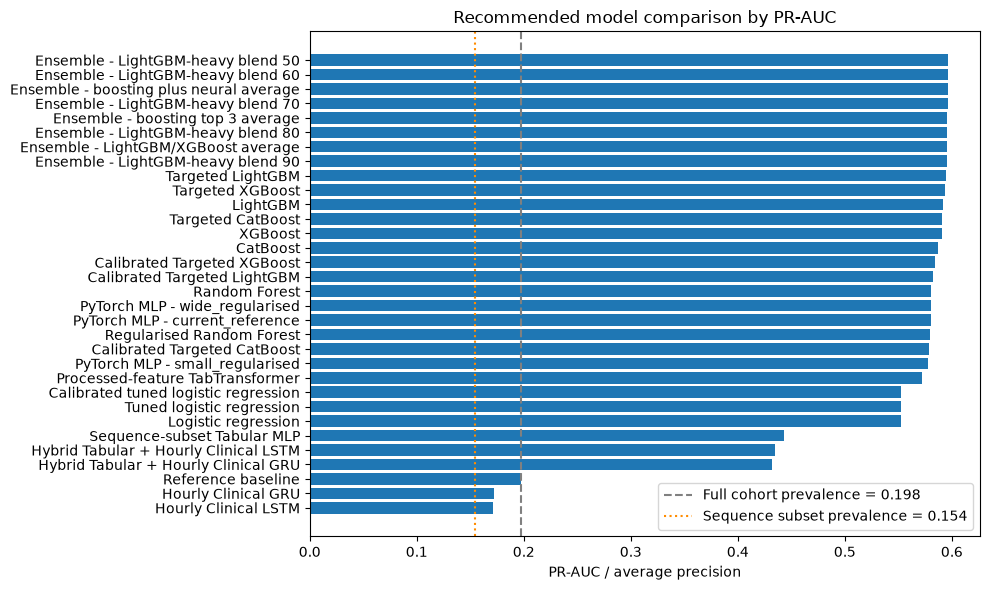

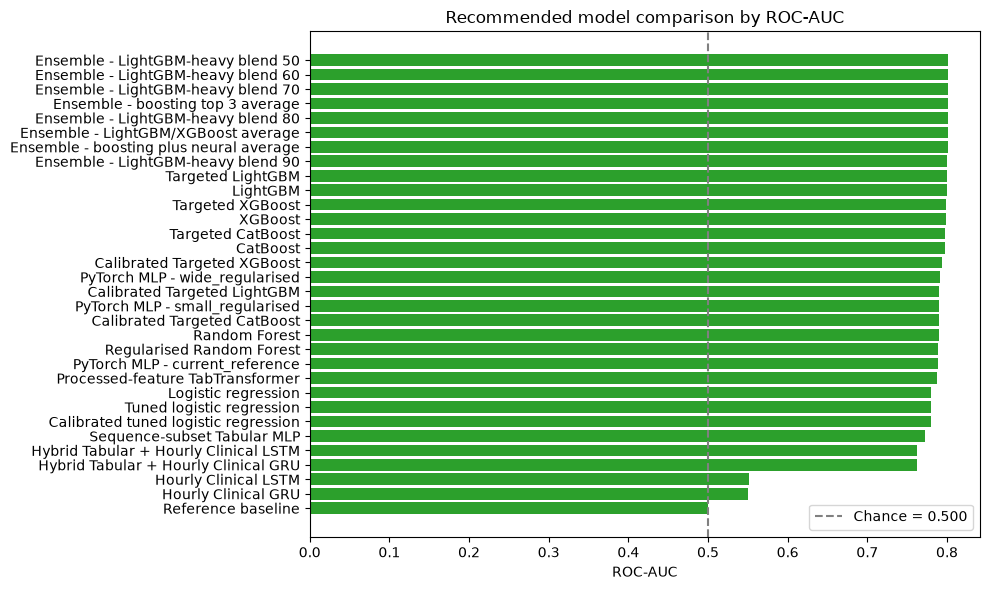

In [7]:
#plot final pr-auc and roc-auc rankings for recommended model rows
#this cell can be rerun from saved WP3.6 outputs after cells 1 and 3 have defined imports and paths.
if "recommended_model_comparison_df" not in globals() or recommended_model_comparison_df.empty:
    saved_recommended_model_path = wp3_6_csv_output_path / "t3_6_recommended_model_performance_comparison.csv"
    if saved_recommended_model_path.exists():
        recommended_model_comparison_df = pd.read_csv(saved_recommended_model_path)
        print("Loaded recommended model comparison from:", saved_recommended_model_path)
    else:
        recommended_model_comparison_df = pd.DataFrame()

if not recommended_model_comparison_df.empty:
    reference_rows = recommended_model_comparison_df.loc[
        recommended_model_comparison_df["model_family"].eq("Reference baseline")]
    if not reference_rows.empty and "pr_auc_average_precision" in reference_rows.columns:
        test_prevalence = float(reference_rows.iloc[0]["pr_auc_average_precision"])
    else:
        full_cohort_rows = recommended_model_comparison_df.loc[
            recommended_model_comparison_df.get("evaluation_subset", pd.Series(index=recommended_model_comparison_df.index, dtype="object")).isna()]
        if full_cohort_rows.empty:
            full_cohort_rows = recommended_model_comparison_df.copy()
        first_full_row = full_cohort_rows.iloc[0]
        test_prevalence = first_full_row["true_positives"] + first_full_row["false_negatives"]
        test_prevalence = test_prevalence / (test_prevalence + first_full_row["true_negatives"] + first_full_row["false_positives"])

    sequence_rows = recommended_model_comparison_df.loc[
        recommended_model_comparison_df.get("evaluation_subset", pd.Series(index=recommended_model_comparison_df.index, dtype="object")).notna()].copy()
    sequence_prevalence = np.nan
    if not sequence_rows.empty:
        sequence_row = sequence_rows.iloc[0]
        sequence_prevalence = (sequence_row["true_positives"] + sequence_row["false_negatives"]) / sequence_row["subset_admissions"]

    plot_df = recommended_model_comparison_df.sort_values("pr_auc_average_precision", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["model_family"], plot_df["pr_auc_average_precision"], color="#1f77b4")
    plt.axvline(test_prevalence, color="gray", linestyle="--", label=f"Full cohort prevalence = {test_prevalence:.3f}")
    if pd.notna(sequence_prevalence):
        plt.axvline(sequence_prevalence, color="darkorange", linestyle=":", label=f"Sequence subset prevalence = {sequence_prevalence:.3f}")
    plt.xlabel("PR-AUC / average precision")
    plt.title("Recommended model comparison by PR-AUC")
    plt.legend()
    plt.tight_layout()
    plt.savefig(wp3_6_image_output_path / "t3_6_recommended_model_pr_auc_comparison.png", dpi=300)
    latex_image_output_path = project_path / "reports" / "Ahthini_diss_LaTeX" / "images"
    if latex_image_output_path.exists():
        plt.savefig(latex_image_output_path / "results_recommended_model_pr_auc.png", dpi=300)
    plt.show()

    plot_df = recommended_model_comparison_df.sort_values("roc_auc", ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["model_family"], plot_df["roc_auc"], color="#2ca02c")
    plt.axvline(0.5, color="gray", linestyle="--", label="Chance = 0.500")
    plt.xlabel("ROC-AUC")
    plt.title("Recommended model comparison by ROC-AUC")
    plt.legend()
    plt.tight_layout()
    plt.savefig(wp3_6_image_output_path / "t3_6_recommended_model_roc_auc_comparison.png", dpi=300)
    plt.show()
else:
    print("No recommended model rows are available yet.")

### **3.6.2 Threshold Analysis**

**Threshold trade-off analysis**

This section combines available threshold-search outputs and highlights the precision-recall trade-off for the best available model. It supports the balanced operating point requested by your project while keeping recall-focused alternatives visible.




In [ ]:
#load available held-out threshold comparison files
threshold_frames = []
#loop through each item in this feature block
for model_output in model_output_registry:
    threshold_file = model_output.get("threshold_file")

    if threshold_file is None:
        continue
    threshold_df = read_csv_if_available(threshold_file)
    if threshold_df is not None:
        threshold_df.insert(0, "source_notebook", model_output["source_notebook"])
        threshold_df.insert(1, "model_family", model_output["model_family"])
        threshold_df.insert(2, "model_group", model_output["model_group"])
        threshold_frames.append(threshold_df)

if threshold_frames:
    threshold_tradeoff_df = pd.concat(threshold_frames, ignore_index=True)
else:
    threshold_tradeoff_df = pd.DataFrame()

#save this table or artefact for later review
threshold_tradeoff_df.to_csv(wp3_6_csv_output_path / "t3_6_threshold_tradeoff_summary.csv", index=False)
print("Threshold trade-off rows:", len(threshold_tradeoff_df))
if not threshold_tradeoff_df.empty:
    display(threshold_tradeoff_df.head(20))

    if not recommended_model_comparison_df.empty:
        best_model_family = recommended_model_comparison_df.iloc[0]["model_family"]
        best_threshold_df = threshold_tradeoff_df.loc[threshold_tradeoff_df["model_family"] == best_model_family].copy()

        if not best_threshold_df.empty:
            best_threshold_df = best_threshold_df.sort_values("threshold").reset_index(drop=True)
            best_threshold_df.to_csv(
                wp3_6_csv_output_path / "t3_6_best_model_threshold_curve_points.csv", index=False)

            plt.figure(figsize=(8, 5))
            plt.plot(best_threshold_df["threshold"], best_threshold_df["precision"], marker="o", label="precision")
            plt.plot(best_threshold_df["threshold"], best_threshold_df["recall_sensitivity"], marker="o", label="recall")
            plt.plot(best_threshold_df["threshold"], best_threshold_df["f1_score"], marker="o", label="f1 score")
    
            if "specificity" in best_threshold_df.columns:
                plt.plot(best_threshold_df["threshold"], best_threshold_df["specificity"], marker="o", label="specificity")
            plt.xlabel("threshold")
            plt.ylabel("metric value")
            plt.title(f"threshold trade-off for {best_model_family}")
            plt.legend()
            plt.tight_layout()
            plt.savefig(wp3_6_image_output_path / "t3_6_best_model_threshold_tradeoff.png", dpi=300)
            plt.show()

            #this view directly shows what recall costs in precision and specificity.
            recall_tradeoff_cols = ["threshold", "precision", "recall_sensitivity", "f1_score"]
            if "specificity" in best_threshold_df.columns:
                recall_tradeoff_cols.append("specificity")
            recall_tradeoff_plot_df = best_threshold_df[recall_tradeoff_cols].dropna().copy()
            recall_tradeoff_plot_df = recall_tradeoff_plot_df.sort_values("recall_sensitivity").reset_index(drop=True)
            recall_tradeoff_plot_df.to_csv(
                wp3_6_csv_output_path / "t3_6_best_model_recall_threshold_tradeoff.csv", index=False)

            plt.figure(figsize=(8, 5))
            plt.plot(recall_tradeoff_plot_df["recall_sensitivity"], recall_tradeoff_plot_df["precision"],
                marker="o", label="precision")
            if "specificity" in recall_tradeoff_plot_df.columns:
                plt.plot(recall_tradeoff_plot_df["recall_sensitivity"], recall_tradeoff_plot_df["specificity"],
                    marker="o", label="specificity")
            plt.plot(recall_tradeoff_plot_df["recall_sensitivity"], recall_tradeoff_plot_df["f1_score"],
                marker="o", label="f1 score")

            selected_thresholds_df = recommended_model_comparison_df.loc[
                recommended_model_comparison_df["model_family"] == best_model_family].copy()
            if not selected_thresholds_df.empty:
                selected_threshold = float(selected_thresholds_df.iloc[0]["threshold"])
                nearest_selected_index = (recall_tradeoff_plot_df["threshold"] - selected_threshold).abs().idxmin()
                selected_row = recall_tradeoff_plot_df.loc[nearest_selected_index]
                plt.scatter(selected_row["recall_sensitivity"], selected_row["precision"],
                    s=90, color="black", zorder=5, label="selected threshold")
                plt.annotate(
                    f"selected threshold={selected_row['threshold']:.2f}",
                    (selected_row["recall_sensitivity"], selected_row["precision"]),
                    xytext=(8, 8), textcoords="offset points")

            f1_index = recall_tradeoff_plot_df["f1_score"].idxmax()
            f1_row = recall_tradeoff_plot_df.loc[f1_index]
            plt.scatter(f1_row["recall_sensitivity"], f1_row["f1_score"],
                s=70, color="tab:green", zorder=5, label="best f1 point")
            plt.annotate(
                f"best f1 threshold={f1_row['threshold']:.2f}",
                (f1_row["recall_sensitivity"], f1_row["f1_score"]),
                xytext=(8, -14), textcoords="offset points")

            plt.xlabel("recall / sensitivity")
            plt.ylabel("metric value")
            plt.title(f"recall trade-off curve for {best_model_family}")
            plt.legend()
            plt.tight_layout()
            plt.savefig(wp3_6_image_output_path / "t3_6_best_model_recall_threshold_tradeoff.png", dpi=300)
            plt.show()

Threshold trade-off rows: 1046


,source_notebook,model_family,model_group,threshold,true_negatives,false_positives,false_negatives,true_positives,precision,recall_sensitivity,specificity,f1_score,balanced_accuracy,precision_recall_gap
0,WP3.3,Random Forest,random_forest,0.10,2449.0,35403.0,38.0,9281.0,0.207703,0.995922,0.064699,0.343722,0.530311,NaN
1,WP3.3,Random Forest,random_forest,0.15,6965.0,30887.0,265.0,9054.0,0.226684,0.971563,0.184006,0.367600,0.577785,NaN
2,WP3.3,Random Forest,random_forest,0.20,14365.0,23487.0,887.0,8432.0,0.264169,0.904818,0.379504,0.408943,0.642161,NaN
3,WP3.3,Random Forest,random_forest,0.25,21013.0,16839.0,1667.0,7652.0,0.312441,0.821118,0.555136,0.452647,0.688127,NaN
4,WP3.3,Random Forest,random_forest,0.26,22116.0,15736.0,1841.0,7478.0,0.322133,0.802447,0.584276,0.459718,0.693361,NaN
5,WP3.3,Random Forest,random_forest,0.27,23110.0,14742.0,2008.0,7311.0,0.331520,0.784526,0.610536,0.466084,0.697531,NaN
6,WP3.3,Random Forest,random_forest,0.28,24009.0,13843.0,2151.0,7168.0,0.341155,0.769181,0.634286,0.472667,0.701734,NaN
7,WP3.3,Random Forest,random_forest,0.29,24881.0,12971.0,2323.0,6996.0,0.350378,0.750724,0.657323,0.477771,0.704024,NaN
8,WP3.3,Random Forest,random_forest,0.30,25687.0,12165.0,2482.0,6837.0,0.359804,0.733662,0.678617,0.482822,0.706140,NaN
9,WP3.3,Random Forest,random_forest,0.31,26506.0,11346.0,2641.0,6678.0,0.370506,0.716600,0.700254,0.488461,0.708427,NaN


**Optimal F1 threshold comparison**

This adds a conventional maximum-F1 operating point for each model. The threshold is selected from the available training or validation threshold-search table, then applied to the saved test predictions. This gives a clean comparison with the balanced precision-recall threshold.




Optimal F1 threshold rows: 13


,model_family,threshold,precision,recall_sensitivity,specificity,f1_score,balanced_accuracy,roc_auc,pr_auc_average_precision,brier_score,true_positives,false_positives,false_negatives,true_negatives,threshold_selection_dataset,selection_f1_score
11,Targeted LightGBM,0.30,0.516326,0.544694,0.874379,0.530131,0.709536,0.800186,0.595385,0.118204,5076,4755,4243,33097,training,0.635522
10,LightGBM,0.54,0.492617,0.572808,0.854750,0.529695,0.713779,0.799571,0.592557,0.159796,5338,5498,3981,32354,training,0.664128
5,Targeted XGBoost,0.39,0.494030,0.568301,0.856705,0.528569,0.712503,0.799264,0.592422,0.127856,5296,5424,4023,32428,training,0.602055
8,Targeted CatBoost,0.31,0.528535,0.528705,0.883890,0.528620,0.706297,0.797777,0.592265,0.118707,4927,4395,4392,33457,training,0.601983
4,XGBoost,0.55,0.499857,0.564438,0.860958,0.530188,0.712698,0.798922,0.590962,0.163210,5260,5263,4059,32589,training,0.628580
7,CatBoost,0.55,0.487907,0.564975,0.854010,0.523620,0.709493,0.797221,0.586163,0.166420,5265,5526,4054,32326,training,0.601461
12,Calibrated Targeted LightGBM,0.29,0.540233,0.503595,0.894484,0.521271,0.699039,0.793146,0.584899,0.119415,4693,3994,4626,33858,validation,0.536342
9,Calibrated Targeted CatBoost,0.24,0.524839,0.515828,0.885026,0.520294,0.700427,0.791438,0.581217,0.120749,4807,4352,4512,33500,validation,0.530684
6,Calibrated Targeted XGBoost,0.28,0.533961,0.505312,0.891419,0.519241,0.698365,0.793089,0.580919,0.120630,4709,4110,4610,33742,validation,0.535742
2,Random Forest,0.47,0.547994,0.477841,0.902964,0.510519,0.690403,0.789250,0.580718,0.135590,4453,3673,4866,34179,training,0.855029


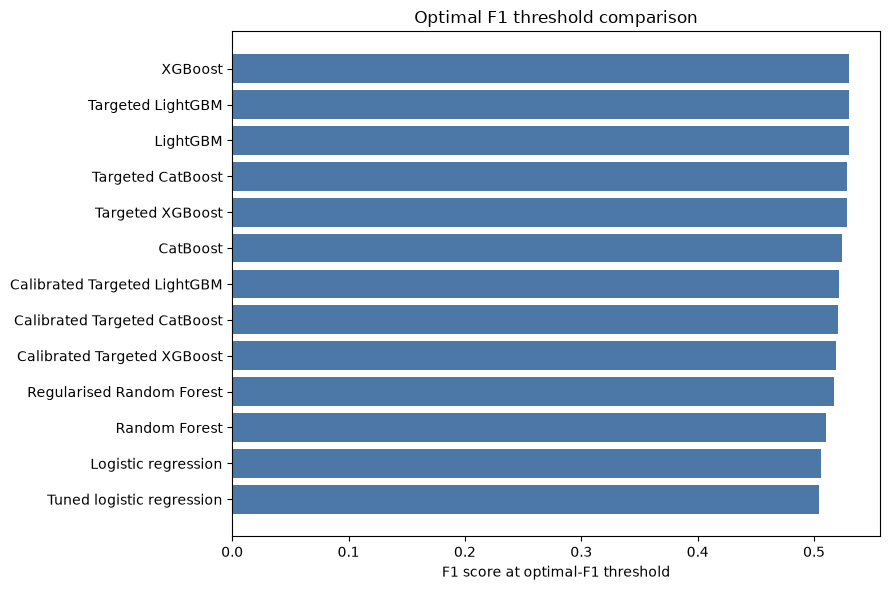

In [ ]:
#select optimal f1 thresholds from training/validation threshold-search files and evaluate them on test predictions
optimal_f1_threshold_df = pd.DataFrame()

optimal_f1_threshold_search_files = {
    "Logistic regression": wp3_2_output_path / "logistic_regression" / "t3_2_logistic_threshold_search_training.csv",
    "Tuned logistic regression": wp3_2_output_path / "tuned_logistic_regression" / "t3_2_tuned_logistic_threshold_search_training.csv",
    "Random Forest": wp3_3_output_path / "random_forest" / "t3_3_random_forest_threshold_search_training.csv",
    "Regularised Random Forest": wp3_3_output_path / "regularised_random_forest" / "t3_3_regularised_random_forest_threshold_search_training.csv",
    "XGBoost": wp3_4_output_path / "xgboost" / "t3_4_xgboost_threshold_search_training.csv",
    "Targeted XGBoost": wp3_4_output_path / "xgboost_targeted" / "t3_4_xgboost_targeted_threshold_search_training.csv",
    "Calibrated Targeted XGBoost": wp3_4_output_path / "calibrated_targeted_xgboost" / "t3_4_calibrated_targeted_xgboost_threshold_search_validation.csv",
    "CatBoost": wp3_4_output_path / "catboost" / "t3_4_catboost_threshold_search_training.csv",
    "Targeted CatBoost": wp3_4_output_path / "catboost_targeted" / "t3_4_catboost_targeted_threshold_search_training.csv",
    "Calibrated Targeted CatBoost": wp3_4_output_path / "calibrated_targeted_catboost" / "t3_4_calibrated_targeted_catboost_threshold_search_validation.csv",
    "LightGBM": wp3_4_output_path / "lightgbm" / "t3_4_lightgbm_threshold_search_training.csv",
    "Targeted LightGBM": wp3_4_output_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_threshold_search_training.csv",
    "Calibrated Targeted LightGBM": wp3_4_output_path / "calibrated_targeted_lightgbm" / "t3_4_calibrated_targeted_lightgbm_threshold_search_validation.csv"}

optimal_f1_rows = []
if all_prediction_df.empty:
    print("Optimal F1 threshold comparison skipped because saved prediction rows are unavailable.")
else:
    #loop through each item in this feature block
    for model_family, threshold_search_file in optimal_f1_threshold_search_files.items():
        threshold_search_df = read_csv_if_available(threshold_search_file)
        model_predictions = all_prediction_df.loc[all_prediction_df["model_family"] == model_family].copy()
        if threshold_search_df is None or threshold_search_df.empty or model_predictions.empty:
            continue
        required_columns = {"threshold", "f1_score"}
        if not required_columns.issubset(threshold_search_df.columns):
            print("Optimal F1 threshold skipped because required columns are missing:", threshold_search_file)
            continue

        threshold_search_df = threshold_search_df.copy()
        #loop through each item in this feature block
        for metric_column in ["threshold", "f1_score", "precision", "recall_sensitivity", "specificity", "precision_recall_gap"]:
            if metric_column in threshold_search_df.columns:
                threshold_search_df[metric_column] = pd.to_numeric(threshold_search_df[metric_column], errors="coerce")
        threshold_search_df = threshold_search_df.dropna(subset=["threshold", "f1_score"])
        if threshold_search_df.empty:
            continue

        sort_columns = ["f1_score"]
        sort_ascending = [False]
        if "precision_recall_gap" in threshold_search_df.columns:
            sort_columns.append("precision_recall_gap")
            sort_ascending.append(True)
        sort_columns.append("threshold")
        sort_ascending.append(False)
        selected_threshold_row = threshold_search_df.sort_values(sort_columns, ascending=sort_ascending).iloc[0]
        selected_threshold = float(selected_threshold_row["threshold"])

        test_metrics = evaluate_probability_at_threshold(
            f"{model_family} optimal F1 threshold", model_predictions["readmitted_30d"].astype(int),
            model_predictions["predicted_probability"], selected_threshold)
        test_metrics.update({"model_family": model_family,
            "threshold_role": "optimal_f1",
            "recommended_threshold_label": "optimal F1 threshold",
            "threshold_source_file": threshold_search_file.name,
            "threshold_selection_dataset": "validation" if "validation" in threshold_search_file.name else "training",
            "selection_f1_score": selected_threshold_row.get("f1_score", np.nan),
            "selection_precision": selected_threshold_row.get("precision", np.nan),
            "selection_recall_sensitivity": selected_threshold_row.get("recall_sensitivity", np.nan),
            "selection_specificity": selected_threshold_row.get("specificity", np.nan),
            "selection_precision_recall_gap": selected_threshold_row.get("precision_recall_gap", np.nan)})
        optimal_f1_rows.append(test_metrics)

if optimal_f1_rows:
    optimal_f1_threshold_df = pd.DataFrame(optimal_f1_rows)
    optimal_f1_threshold_df = optimal_f1_threshold_df.sort_values(
        ["pr_auc_average_precision", "roc_auc", "f1_score"], ascending=False)
else:
    optimal_f1_threshold_df = pd.DataFrame()

#save this table or artefact for later review
optimal_f1_threshold_df.to_csv(wp3_6_csv_output_path / "t3_6_optimal_f1_threshold_comparison.csv", index=False)

print("Optimal F1 threshold rows:", len(optimal_f1_threshold_df))
if not optimal_f1_threshold_df.empty:
    display(optimal_f1_threshold_df[["model_family", "threshold", "precision", "recall_sensitivity",
        "specificity", "f1_score", "balanced_accuracy", "roc_auc", "pr_auc_average_precision",
        "brier_score", "true_positives", "false_positives", "false_negatives", "true_negatives",
        "threshold_selection_dataset", "selection_f1_score"]])

    plot_df = optimal_f1_threshold_df.sort_values("f1_score", ascending=True)
    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["model_family"], plot_df["f1_score"], color="#4c78a8")
    plt.xlabel("F1 score at optimal-F1 threshold")
    plt.title("Optimal F1 threshold comparison")
    plt.tight_layout()
    plt.savefig(wp3_6_image_output_path / "t3_6_optimal_f1_threshold_comparison.png", dpi=300)
    plt.show()

**Class imbalance and recall-threshold optimisation**

This records the outcome imbalance and evaluates how the selected final model behaves when thresholds are chosen to meet fixed recall targets or explicit false-negative/false-positive cost ratios.




In [ ]:
#summarise class imbalance and threshold choices for the selected final model
class_imbalance_summary_df = pd.DataFrame()
fixed_recall_threshold_df = pd.DataFrame()
cost_sensitive_threshold_df = pd.DataFrame()
subgroup_prevalence_performance_df = pd.DataFrame()
#this section can run before the formal subgroup section, so define a safe placeholder.
if "subgroup_performance_df" not in globals():
    subgroup_performance_df = pd.DataFrame()

if all_prediction_df.empty or recommended_model_comparison_df.empty:
    print("Class imbalance section skipped because predictions or recommended model rows are unavailable.")
else:
    best_model_family = recommended_model_comparison_df.iloc[0]["model_family"]
    best_model_predictions = all_prediction_df.loc[all_prediction_df["model_family"] == best_model_family].copy()
    y_true = best_model_predictions["readmitted_30d"].astype(int).to_numpy()
    y_probability = best_model_predictions["predicted_probability"].astype(float).to_numpy()

    positive_count = int(y_true.sum())
    negative_count = int(len(y_true) - positive_count)
    outcome_prevalence = positive_count / len(y_true)
    imbalance_ratio = negative_count / positive_count if positive_count else np.nan

    class_imbalance_summary_df = pd.DataFrame([{"model_family": best_model_family,
        "test_admissions": len(y_true),
        "readmitted_30d_count": positive_count,
        "not_readmitted_30d_count": negative_count,
        "readmission_prevalence": outcome_prevalence,
        "negative_to_positive_ratio": imbalance_ratio,
        "baseline_pr_auc": outcome_prevalence,
        "selected_model_pr_auc": recommended_model_comparison_df.iloc[0]["pr_auc_average_precision"],
        "pr_auc_lift_over_baseline": recommended_model_comparison_df.iloc[0]["pr_auc_average_precision"] / outcome_prevalence}])

    threshold_grid = np.round(np.arange(0.01, 1.00, 0.01), 2)
    threshold_rows = []
    #loop through each item in this feature block
    for threshold_value in threshold_grid:
        metrics = evaluate_probability_at_threshold(best_model_family, y_true, y_probability, threshold_value)
        threshold_rows.append(metrics)
    threshold_grid_df = pd.DataFrame(threshold_rows)

    recall_targets = [0.60, 0.70, 0.80, 0.90]
    fixed_recall_rows = []
    for recall_target in recall_targets:
        eligible_thresholds = threshold_grid_df.loc[threshold_grid_df["recall_sensitivity"] >= recall_target].copy()
        if eligible_thresholds.empty:
            continue
        #among thresholds that reach the target recall, keep the highest precision option
        chosen_row = eligible_thresholds.sort_values(["precision", "specificity", "threshold"], ascending=False).iloc[0].copy()
        chosen_row["recall_target"] = recall_target
        chosen_row["threshold_selection_rule"] = "highest precision while meeting recall target"
        fixed_recall_rows.append(chosen_row)
    fixed_recall_threshold_df = pd.DataFrame(fixed_recall_rows)

    cost_rows = []
    for false_negative_cost in [1, 2, 5, 10]:
        cost_df = threshold_grid_df.copy()
        cost_df["false_negative_cost"] = false_negative_cost
        cost_df["false_positive_cost"] = 1
        cost_df["total_weighted_cost"] = (cost_df["false_negatives"] * false_negative_cost) + cost_df["false_positives"]
        cost_df["weighted_cost_per_admission"] = cost_df["total_weighted_cost"] / len(y_true)
        chosen_row = cost_df.sort_values(["weighted_cost_per_admission", "threshold"]).iloc[0].copy()
        cost_rows.append(chosen_row)
    cost_sensitive_threshold_df = pd.DataFrame(cost_rows)

    #save this table or artefact for later review
    class_imbalance_summary_df.to_csv(wp3_6_csv_output_path / "t3_6_class_imbalance_summary.csv", index=False)
    fixed_recall_threshold_df.to_csv(wp3_6_csv_output_path / "t3_6_fixed_recall_threshold_sensitivity.csv", index=False)
    cost_sensitive_threshold_df.to_csv(wp3_6_csv_output_path / "t3_6_cost_sensitive_threshold_sensitivity.csv", index=False)

    print("Class imbalance summary:")
    display(class_imbalance_summary_df)
    print("Fixed-recall threshold sensitivity:")
    display(fixed_recall_threshold_df[["recall_target", "threshold", "precision", "recall_sensitivity",
        "specificity", "f1_score", "true_positives", "false_positives", "false_negatives", "true_negatives"]])
    print("Cost-sensitive threshold sensitivity:")
    display(cost_sensitive_threshold_df[["false_negative_cost", "false_positive_cost", "threshold",
        "precision", "recall_sensitivity", "specificity", "f1_score", "total_weighted_cost",
        "weighted_cost_per_admission"]])

    if "subgroup_performance_df" in globals() and not subgroup_performance_df.empty:
        subgroup_prevalence_performance_df = subgroup_performance_df.copy()
        subgroup_prevalence_performance_df["overall_readmission_prevalence"] = outcome_prevalence
        subgroup_prevalence_performance_df["subgroup_prevalence_difference"] = (
            subgroup_prevalence_performance_df["readmission_rate"] - outcome_prevalence)
        subgroup_prevalence_performance_df["subgroup_prevalence_ratio"] = (
            subgroup_prevalence_performance_df["readmission_rate"] / outcome_prevalence)
        subgroup_prevalence_performance_df = subgroup_prevalence_performance_df.sort_values(
            ["subgroup_prevalence_ratio", "pr_auc_average_precision"], ascending=False)
        subgroup_prevalence_performance_df.to_csv(
            wp3_6_output_path / "t3_6_subgroup_prevalence_and_performance.csv", index=False)
        print("Subgroup prevalence and performance preview:")
        display(subgroup_prevalence_performance_df[["subgroup_column", "subgroup_value", "admissions",
            "readmission_rate", "subgroup_prevalence_ratio", "roc_auc", "pr_auc_average_precision",
            "precision", "recall_sensitivity", "specificity", "f1_score"]].head(30))

Class imbalance summary:


,model_family,test_admissions,readmitted_30d_count,not_readmitted_30d_count,readmission_prevalence,negative_to_positive_ratio,baseline_pr_auc,selected_model_pr_auc,pr_auc_lift_over_baseline
0,Ensemble - LightGBM-heavy blend 50,47171,9319,37852,0.197558,4.061809,0.197558,0.596463,3.019181


Fixed-recall threshold sensitivity:


,recall_target,threshold,precision,recall_sensitivity,specificity,f1_score,true_positives,false_positives,false_negatives,true_negatives
30,0.6,0.31,0.470208,0.601245,0.833219,0.527714,5603,6313,3716,31539
24,0.7,0.25,0.398126,0.702007,0.738719,0.508097,6542,9890,2777,27962
18,0.8,0.19,0.326994,0.813607,0.587736,0.466498,7582,15605,1737,22247
13,0.9,0.14,0.274905,0.903745,0.413135,0.421574,8422,22214,897,15638


Cost-sensitive threshold sensitivity:


,false_negative_cost,false_positive_cost,threshold,precision,recall_sensitivity,specificity,f1_score,total_weighted_cost,weighted_cost_per_admission
60,1,1,0.61,0.775810,0.300783,0.978601,0.433498,7326,0.155307
39,2,1,0.40,0.577747,0.486426,0.912475,0.528168,12885,0.273155
23,5,1,0.24,0.387106,0.721000,0.718958,0.503749,23638,0.501113
13,10,1,0.14,0.274905,0.903745,0.413135,0.421574,31184,0.661084


### **3.6.3 High-Risk Strata Analysis**

This translates model probabilities into a triage-style view: if the highest-risk admissions are reviewed first, what observed readmission rate do we see, and what share of all readmissions is captured? This is often more clinically meaningful than forcing a single hard classification threshold.




Best model for high-risk strata: Ensemble - LightGBM-heavy blend 50


,model_family,top_percent,admissions_in_stratum,observed_readmission_rate,baseline_readmission_rate,lift_vs_baseline,captured_readmissions,captured_readmission_percent,minimum_probability_in_stratum,maximum_probability_in_stratum
216,Ensemble - LightGBM-heavy blend 50,1,472,0.997881,0.197558,5.051085,471,0.050542,0.961883,0.987474
217,Ensemble - LightGBM-heavy blend 50,2,944,0.987288,0.197558,4.997464,932,0.100011,0.919536,0.987474
218,Ensemble - LightGBM-heavy blend 50,5,2359,0.861806,0.197558,4.362297,2033,0.218156,0.724220,0.987474
219,Ensemble - LightGBM-heavy blend 50,10,4718,0.703688,0.197558,3.561934,3320,0.356261,0.534762,0.987474
220,Ensemble - LightGBM-heavy blend 50,15,7076,0.601894,0.197558,3.046671,4259,0.457023,0.424539,0.987474
221,Ensemble - LightGBM-heavy blend 50,20,9435,0.528882,0.197558,2.677099,4990,0.535465,0.358186,0.987474
222,Ensemble - LightGBM-heavy blend 50,25,11793,0.472314,0.197558,2.390764,5570,0.597704,0.312059,0.987474
223,Ensemble - LightGBM-heavy blend 50,30,14152,0.431388,0.197558,2.183603,6105,0.655113,0.276957,0.987474


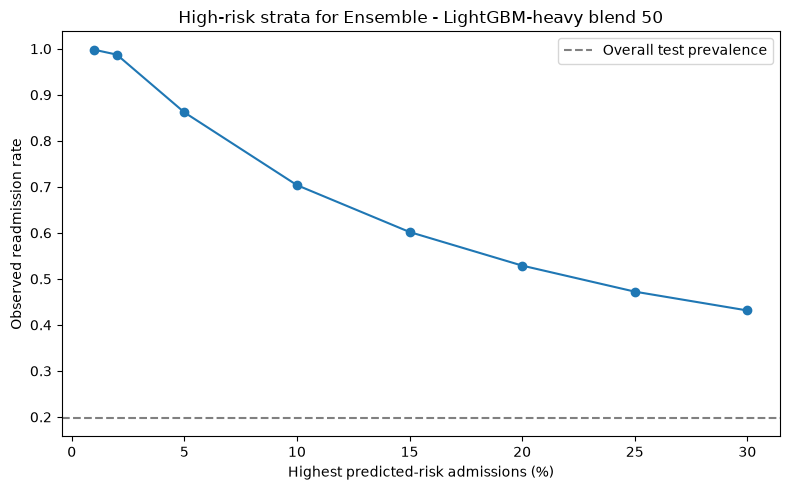

In [ ]:
#summarise observed readmission risk in the highest predicted-risk strata
def high_risk_strata_table(prediction_df, model_family, top_percent_values=None):
    if top_percent_values is None:
        top_percent_values = [1, 2, 5, 10, 15, 20, 25, 30]
    model_predictions = prediction_df.loc[prediction_df["model_family"] == model_family].copy()
    if model_predictions.empty:
        return pd.DataFrame()
    model_predictions = model_predictions.sort_values("predicted_probability", ascending=False).reset_index(drop=True)
    total_admissions = len(model_predictions)
    total_readmissions = model_predictions["readmitted_30d"].sum()
    baseline_rate = total_readmissions / total_admissions
    rows = []
    #loop through each item in this feature block
    for top_percent in top_percent_values:
        cutoff_n = max(1, int(np.ceil(total_admissions * top_percent / 100)))
        stratum = model_predictions.head(cutoff_n)
        observed_rate = stratum["readmitted_30d"].mean()
        captured_readmissions = stratum["readmitted_30d"].sum()
        rows.append({"model_family": model_family,
            "top_percent": top_percent,
            "admissions_in_stratum": cutoff_n,
            "observed_readmission_rate": observed_rate,
            "baseline_readmission_rate": baseline_rate,
            "lift_vs_baseline": observed_rate / baseline_rate if baseline_rate else np.nan,
            "captured_readmissions": captured_readmissions,
            "captured_readmission_percent": captured_readmissions / total_readmissions if total_readmissions else np.nan,
            "minimum_probability_in_stratum": stratum["predicted_probability"].min(),
            "maximum_probability_in_stratum": stratum["predicted_probability"].max()})
    return pd.DataFrame(rows)

high_risk_frames = []
if not all_prediction_df.empty:
    for model_family in all_prediction_df["model_family"].dropna().unique():
        high_risk_frames.append(high_risk_strata_table(all_prediction_df, model_family))

if high_risk_frames:
    high_risk_strata_df = pd.concat(high_risk_frames, ignore_index=True)
else:
    high_risk_strata_df = pd.DataFrame()

#save this table or artefact for later review
high_risk_strata_df.to_csv(wp3_6_csv_output_path / "t3_6_high_risk_strata_analysis.csv", index=False)

if not high_risk_strata_df.empty:
    key_strata = [5, 10, 20]
    high_risk_summary_df = high_risk_strata_df.loc[high_risk_strata_df["top_percent"].isin(key_strata)].copy()
    high_risk_summary_df = high_risk_summary_df.merge(
        recommended_model_comparison_df[["model_family", "roc_auc", "pr_auc_average_precision", "f1_score"]],
        on="model_family", how="left")
    high_risk_summary_df = high_risk_summary_df.sort_values(
        ["top_percent", "observed_readmission_rate", "captured_readmission_percent"], ascending=[True, False, False])
else:
    high_risk_summary_df = pd.DataFrame()

high_risk_summary_df.to_csv(wp3_6_csv_output_path / "t3_6_high_risk_strata_summary.csv", index=False)

if not recommended_model_comparison_df.empty and not high_risk_strata_df.empty:
    best_model_family = recommended_model_comparison_df.iloc[0]["model_family"]
    best_model_high_risk_df = high_risk_strata_df.loc[high_risk_strata_df["model_family"] == best_model_family].copy()

    #save this table or artefact for later review
    best_model_high_risk_df.to_csv(wp3_6_csv_output_path / "t3_6_best_model_high_risk_strata.csv", index=False)
    print("Best model for high-risk strata:", best_model_family)
    display(best_model_high_risk_df)

    plt.figure(figsize=(8, 5))
    plt.plot(best_model_high_risk_df["top_percent"], best_model_high_risk_df["observed_readmission_rate"], marker="o")
    plt.axhline(best_model_high_risk_df["baseline_readmission_rate"].iloc[0], color="gray", linestyle="--", label="Overall test prevalence")
    plt.xlabel("Highest predicted-risk admissions (%)")
    plt.ylabel("Observed readmission rate")
    plt.title(f"High-risk strata for {best_model_family}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(wp3_6_image_output_path / "t3_6_best_model_high_risk_strata.png", dpi=300)
    plt.show()
else:
    print("High-risk strata cannot be created until prediction files are available.")

**Reduced matrix sensitivity extension**




**What Is Being Tested?**

WP3.1 now provides the primary `shap_guided_reduced_feature_set` matrix. The sensitivity cells below compare it with the earlier full/clean/runtime-trimmed matrices when those files exist, and then run top-N feature experiments using the SHAP ranking.

This helps answer three questions:

- does the smaller matrix preserve model performance;
- how much performance remains with only the strongest SHAP-ranked predictors;
- which feature count gives the best balance between performance, speed, and interpretability.




In [ ]:
#show model availability already checked in the top import cell
print("LightGBM available:", lightgbm_available)
if not lightgbm_available:
    print("LightGBM import error:", lightgbm_import_error)
print("XGBoost available:", xgboost_available)
if not xgboost_available:
    print("XGBoost import error:", xgboost_import_error)

#confirm reduced-feature sensitivity output folder defined in the shared setup cell
print("Reduced-feature sensitivity output folder:")
print(reduced_sensitivity_output_path)

LightGBM available: True
XGBoost available: True
Reduced-feature sensitivity output folder:
/scratch/DissProject/outputs/WP3_6/reduced_feature_sensitivity


In [ ]:
#load shared train/test labels, identifiers, and primary feature names
#the label split is reused exactly so comparisons are driven by feature/model changes, not resampling
primary_feature_names_path = wp3_1_output_path / f"t3_1_processed_feature_names_{wp3_input_variant}.csv"
if not primary_feature_names_path.exists():
    raise FileNotFoundError(f"Primary WP3.1 feature-name file not found: {primary_feature_names_path}")

y_train = pd.read_csv(wp3_1_output_path / "t3_1_y_train.csv")["readmitted_30d"].astype(int)
y_test = pd.read_csv(wp3_1_output_path / "t3_1_y_test.csv")["readmitted_30d"].astype(int)
train_ids = pd.read_csv(wp3_1_output_path / "t3_1_train_ids.csv")
test_ids = pd.read_csv(wp3_1_output_path / "t3_1_test_ids.csv")

primary_feature_names = pd.read_csv(primary_feature_names_path)["processed_feature_name"].tolist()
full_feature_names = pd.read_csv(wp3_1_output_path / "t3_1_processed_feature_names.csv")["processed_feature_name"].tolist()

reduced_matrix_summary_candidates = [
    wp3_1_output_path / f"t3_1_rebuilt_reduced_matrix_summary_{wp3_input_variant}.csv",
    wp3_feature_audit_output_path / "t3_feature_audit_reduced_matrix_summary.csv"]
reduced_matrix_summary_df = pd.DataFrame()
for summary_path in reduced_matrix_summary_candidates:
    if summary_path.exists():
        reduced_matrix_summary_df = pd.read_csv(summary_path)
        break

print("Primary WP3 input variant:", wp3_input_variant)
print("Primary processed feature count:", len(primary_feature_names))
print("Training label distribution:")
print(y_train.value_counts().sort_index())
print("Test label distribution:")
print(y_test.value_counts().sort_index())
if not reduced_matrix_summary_df.empty:
    print("Reduced matrix summary:")
    display(reduced_matrix_summary_df)
else:
    print("No reduced matrix summary file found yet; continuing with available matrices.")

Primary WP3 input variant: shap_guided_reduced_feature_set
Primary processed feature count: 954
Training label distribution:
readmitted_30d
0    153281
1     38039
Name: count, dtype: int64
Test label distribution:
readmitted_30d
0    37852
1     9319
Name: count, dtype: int64
Reduced matrix summary:


,field,value
0,source_matrix_suffix,clean_feature_audit
1,rebuilt_matrix_suffix,shap_guided_reduced_feature_set
2,core_requested_feature_count,891
3,high_recent_shap_signal_feature_count,321
4,clinically_relevant_non_sparse_extra_count,321
5,explicit_aftercare_addback_feature_count,27
6,missing_core_requested_features,0
7,original_clean_feature_count,1604
8,primary_reduced_feature_count,954
9,dropped_feature_count,650


In [ ]:
#register processed matrix sets to compare; the shap-guided reduced matrix is listed first because it is now the primary dataset for wp3.2-wp3.4
matrix_set_registry = []
candidate_matrix_sets = [{"matrix_set": "shap_guided_reduced_feature_set",
     "X_train_path": wp3_1_output_path / "t3_1_X_train_processed_shap_guided_reduced_feature_set.npz",
     "X_test_path": wp3_1_output_path / "t3_1_X_test_processed_shap_guided_reduced_feature_set.npz",
     "feature_names_path": wp3_1_output_path / "t3_1_processed_feature_names_shap_guided_reduced_feature_set.csv"},
    {"matrix_set": "clean_feature_audit",
     "X_train_path": wp3_1_output_path / "t3_1_X_train_processed_clean_feature_audit.npz",
     "X_test_path": wp3_1_output_path / "t3_1_X_test_processed_clean_feature_audit.npz",
     "feature_names_path": wp3_1_output_path / "t3_1_processed_feature_names_clean_feature_audit.csv"},
    {"matrix_set": "runtime_trimmed_feature_audit",
     "X_train_path": wp3_1_output_path / "t3_1_X_train_processed_runtime_trimmed_feature_audit.npz",
     "X_test_path": wp3_1_output_path / "t3_1_X_test_processed_runtime_trimmed_feature_audit.npz",
     "feature_names_path": wp3_1_output_path / "t3_1_processed_feature_names_runtime_trimmed_feature_audit.csv"},
    {"matrix_set": "full_processed_matrix",
     "X_train_path": wp3_1_output_path / "t3_1_X_train_processed.npz",
     "X_test_path": wp3_1_output_path / "t3_1_X_test_processed.npz",
     "feature_names_path": wp3_1_output_path / "t3_1_processed_feature_names.csv"}]

for matrix_set_info in candidate_matrix_sets:
    required_paths = [matrix_set_info["X_train_path"], matrix_set_info["X_test_path"], matrix_set_info["feature_names_path"]]
    if all(path.exists() for path in required_paths):
        matrix_set_registry.append(matrix_set_info)
    else:
        print("Skipping unavailable matrix set:", matrix_set_info["matrix_set"])

removed_feature_frames = []
for matrix_set in ["clean_feature_audit", "runtime_trimmed_feature_audit", "shap_guided_reduced_feature_set"]:
    removed_path = wp3_1_output_path / f"t3_1_removed_processed_feature_names_{matrix_set}.csv"
    if removed_path.exists():
        removed_df = pd.read_csv(removed_path)
        removed_df.insert(0, "matrix_set", matrix_set)
        removed_feature_frames.append(removed_df)

removed_feature_summary_df = pd.concat(removed_feature_frames, ignore_index=True) if removed_feature_frames else pd.DataFrame()

print("Available matrix sets for WP3.6 checks:")
for matrix_set_info in matrix_set_registry:
    print("-", matrix_set_info["matrix_set"], matrix_set_info["feature_names_path"])
if not removed_feature_summary_df.empty:
    print("Removed-feature summary preview:")
    display(removed_feature_summary_df.groupby("matrix_set").head(10))

Available matrix sets for WP3.6 checks:
- shap_guided_reduced_feature_set /scratch/DissProject/outputs/WP3_1/t3_1_processed_feature_names_shap_guided_reduced_feature_set.csv
- clean_feature_audit /scratch/DissProject/outputs/WP3_1/t3_1_processed_feature_names_clean_feature_audit.csv
- runtime_trimmed_feature_audit /scratch/DissProject/outputs/WP3_1/t3_1_processed_feature_names_runtime_trimmed_feature_audit.csv
- full_processed_matrix /scratch/DissProject/outputs/WP3_1/t3_1_processed_feature_names.csv
Removed-feature summary preview:


,matrix_set,processed_feature_name
0,clean_feature_audit,cat__bmi_category_Missing
1,clean_feature_audit,cat__bmi_category_Normal
2,clean_feature_audit,cat__bmi_category_Obese
3,clean_feature_audit,cat__bmi_category_Overweight
4,clean_feature_audit,cat__bmi_category_Underweight
5,clean_feature_audit,cat__lab_abnormal_burden_category_0 abnormal labs
6,clean_feature_audit,cat__lab_abnormal_burden_category_1 abnormal lab
7,clean_feature_audit,cat__lab_abnormal_burden_category_2 abnormal labs
8,clean_feature_audit,cat__lab_abnormal_burden_category_3+ abnormal ...
9,clean_feature_audit,cat__unique_drug_burden_category_0 drugs


**Confirm SHAP-Guided Reduced Matrix**

The primary reduced matrix should already have been rebuilt and saved by WP3.1 or the rapid-trial rebuild cell. This check confirms the files are present and records how many processed predictors were kept or removed.




In [ ]:
#confirm the shap-guided reduced matrix is available for the primary analysis
#the rapid-trial notebook rebuilds this matrix from the latest clean feature-audit matrix and saves it into wp3.1
shap_guided_matrix_set = "shap_guided_reduced_feature_set"
shap_guided_feature_summary_df = pd.DataFrame()
removed_shap_guided_features_df = pd.DataFrame()

shap_guided_feature_names_path = wp3_1_output_path / f"t3_1_processed_feature_names_{shap_guided_matrix_set}.csv"
shap_guided_removed_features_path = wp3_1_output_path / f"t3_1_removed_processed_feature_names_{shap_guided_matrix_set}.csv"
shap_guided_summary_path = wp3_1_output_path / f"t3_1_rebuilt_reduced_matrix_summary_{shap_guided_matrix_set}.csv"

if shap_guided_feature_names_path.exists():
    shap_guided_feature_names_df = pd.read_csv(shap_guided_feature_names_path)
    if shap_guided_removed_features_path.exists():
        removed_shap_guided_features_df = pd.read_csv(shap_guided_removed_features_path)
    if shap_guided_summary_path.exists():
        shap_guided_feature_summary_df = pd.read_csv(shap_guided_summary_path)
    print("Primary SHAP-guided reduced matrix is available.")
    print("Kept processed features:", len(shap_guided_feature_names_df))
    print("Removed processed features:", len(removed_shap_guided_features_df))
    if not shap_guided_feature_summary_df.empty:
        display(shap_guided_feature_summary_df)
else:
    print("SHAP-guided reduced matrix was not found in WP3.1 yet.")
    print("Run the rapid-trial reduced-matrix rebuild cell before running official WP3.2-WP3.4 on the reduced primary dataset.")

Primary SHAP-guided reduced matrix is available.
Kept processed features: 954
Removed processed features: 650


,field,value
0,source_matrix_suffix,clean_feature_audit
1,rebuilt_matrix_suffix,shap_guided_reduced_feature_set
2,core_requested_feature_count,891
3,high_recent_shap_signal_feature_count,321
4,clinically_relevant_non_sparse_extra_count,321
5,explicit_aftercare_addback_feature_count,27
6,missing_core_requested_features,0
7,original_clean_feature_count,1604
8,primary_reduced_feature_count,954
9,dropped_feature_count,650


**Helper Functions**

The functions below evaluate probabilities at a threshold, save predictions, and keep the sensitivity outputs consistent with WP3.4/WP3.6.

In [ ]:
#calculate threshold-based classification metrics from predicted probabilities
def evaluate_probability_at_threshold(model_label, y_true, y_probability, threshold):
    y_predicted = (y_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_predicted, labels=[0, 1]).ravel()
    return {"model": model_label,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_predicted),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_predicted),
        "precision": precision_score(y_true, y_predicted, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_predicted, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "f1_score": f1_score(y_true, y_predicted, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc_average_precision": average_precision_score(y_true, y_probability),
        "brier_score": brier_score_loss(y_true, y_probability),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp}

#score every threshold from 0.01 to 0.99 for sensitivity analysis
def threshold_search_table(model_label, y_true, y_probability):
    rows = []
    for threshold in np.round(np.arange(0.01, 1.00, 0.01), 2):
        rows.append(evaluate_probability_at_threshold(model_label, y_true, y_probability, threshold))
    return pd.DataFrame(rows)

#save test-set predictions with ids, probabilities, and the selected threshold class
def save_test_predictions(output_path, file_prefix, y_probability, threshold):
    prediction_df = test_ids.copy()
    prediction_df["readmitted_30d"] = y_test.values
    prediction_df["predicted_probability"] = y_probability
    prediction_df["predicted_class"] = (y_probability >= threshold).astype(int)
    prediction_df.to_csv(output_path / f"{file_prefix}_test_predictions.csv", index=False)
    return prediction_df

#load one processed matrix set and its matching feature names
def load_matrix_set(matrix_set_info):
    X_train_matrix = sparse.load_npz(matrix_set_info["X_train_path"])
    X_test_matrix = sparse.load_npz(matrix_set_info["X_test_path"])
    feature_names = pd.read_csv(matrix_set_info["feature_names_path"])["processed_feature_name"].tolist()
    return X_train_matrix, X_test_matrix, feature_names

**Model Configurations**

These configurations mirror the final targeted boosting settings from WP3.4. LightGBM is run first because it is fast and is nearly tied with Targeted XGBoost in WP3.6.

In [ ]:
#define final targeted model configurations for sensitivity testing
#these configs keep matrix comparisons consistent across the compact and full feature sets
class_counts = y_train.value_counts().sort_index()
scale_pos_weight = class_counts.loc[0] / class_counts.loc[1]
print("Scale positive weight:", scale_pos_weight)

#lightgbm keeps its own leaf and child-sample controls
lightgbm_reduced_config = {"subsample": 0.75, "reg_lambda": 45, "reg_alpha": 0.5,
    "num_leaves": 127, "n_estimators": 360, "min_child_samples": 75,
    "max_depth": -1, "learning_rate": 0.03, "colsample_bytree": 0.75}
lightgbm_scale_pos_weight_multiplier = 0.30

#xgboost uses min_child_weight rather than lightgbm's num_leaves/min_child_samples
xgboost_reduced_config = {"subsample": 0.75, "reg_lambda": 35, "reg_alpha": 0.5,
    "n_estimators": 360, "min_child_weight": 1, "max_depth": 8,
    "learning_rate": 0.05, "gamma": 0, "colsample_bytree": 0.75}
xgboost_scale_pos_weight_multiplier = 0.5

print("Targeted LightGBM sensitivity configuration:")
print(lightgbm_reduced_config)
print("Targeted XGBoost sensitivity configuration:")
print({**xgboost_reduced_config, "scale_pos_weight_multiplier": xgboost_scale_pos_weight_multiplier})

Scale positive weight: 4.02957490996083
Targeted LightGBM sensitivity configuration:
{'subsample': 0.75, 'reg_lambda': 45, 'reg_alpha': 0.5, 'num_leaves': 127, 'n_estimators': 360, 'min_child_samples': 75, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.75}
Targeted XGBoost sensitivity configuration:
{'subsample': 0.75, 'reg_lambda': 35, 'reg_alpha': 0.5, 'n_estimators': 360, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.75, 'scale_pos_weight_multiplier': 0.5}


**Run Targeted LightGBM Reduced-Feature Sensitivity**

This is the main fast test. If the clean and runtime-trimmed matrices perform similarly to the full matrix, the audited feature removals are unlikely to be harming model performance.

In [ ]:
#train targeted lightgbm across available matrix sets, with the shap-guided set treated as primary
lightgbm_reduced_rows = []
lightgbm_feature_importance_frames = []

if lightgbm_available:
    #loop through each item in this feature block
    for matrix_set_info in matrix_set_registry:
        matrix_set = matrix_set_info["matrix_set"]
        print("Training Targeted LightGBM reduced-feature sensitivity model for:", matrix_set)
        X_train_matrix, X_test_matrix, feature_names = load_matrix_set(matrix_set_info)
        output_path = reduced_sensitivity_output_path / "lightgbm_targeted" / matrix_set
        output_path.mkdir(parents=True, exist_ok=True)

        model = LGBMClassifier(**lightgbm_reduced_config, objective="binary",
            class_weight={0: 1.0, 1: scale_pos_weight * lightgbm_scale_pos_weight_multiplier},
            random_state=42, n_jobs=-1, verbosity=-1, force_col_wise=True)

        #fit the model on the current training data
        training_start = time.perf_counter()
        model.fit(X_train_matrix, y_train)
        training_time_seconds = time.perf_counter() - training_start
        train_prediction_start = time.perf_counter()

        #score admissions as predicted readmission probabilities
        train_probability = model.predict_proba(X_train_matrix)[:, 1]
        train_inference_time_seconds = time.perf_counter() - train_prediction_start
        test_prediction_start = time.perf_counter()
        test_probability = model.predict_proba(X_test_matrix)[:, 1]
        test_inference_time_seconds = time.perf_counter() - test_prediction_start

        threshold_df = threshold_search_table(f"Targeted LightGBM {matrix_set}", y_train, train_probability)
        official_threshold = float(threshold_df.sort_values(["f1_score", "pr_auc_average_precision"], ascending=False).iloc[0]["threshold"])
        test_metrics = evaluate_probability_at_threshold(f"Targeted LightGBM {matrix_set}", y_test, test_probability, official_threshold)
        test_metrics.update({"model_family": "Targeted LightGBM",
            "matrix_set": matrix_set,
            "processed_features": X_train_matrix.shape[1],
            "removed_processed_features": len(full_feature_names) - X_train_matrix.shape[1],
            "threshold_role": "training_f1",
            "training_roc_auc": roc_auc_score(y_train, train_probability),
            "training_pr_auc_average_precision": average_precision_score(y_train, train_probability),
            "training_time_seconds": training_time_seconds,
            "train_inference_time_seconds": train_inference_time_seconds,
            "test_inference_time_seconds": test_inference_time_seconds,
            "test_inference_time_per_admission_ms": (test_inference_time_seconds / len(y_test)) * 1000})
        lightgbm_reduced_rows.append(test_metrics)

        #save this table or artefact for later review
        threshold_df.to_csv(output_path / f"t3_reduced_lightgbm_targeted_{matrix_set}_threshold_search_training.csv", index=False)
        save_test_predictions(output_path, f"t3_reduced_lightgbm_targeted_{matrix_set}", test_probability, official_threshold)
        joblib.dump(model, output_path / f"t3_reduced_lightgbm_targeted_{matrix_set}_model.joblib")

        importance_df = pd.DataFrame({"processed_feature_name": feature_names,
            "feature_importance": model.feature_importances_,
            "matrix_set": matrix_set,
            "model_family": "Targeted LightGBM"}).sort_values("feature_importance", ascending=False)
        importance_df.to_csv(output_path / f"t3_reduced_lightgbm_targeted_{matrix_set}_feature_importance.csv", index=False)
        lightgbm_feature_importance_frames.append(importance_df)

        print("Matrix set:", matrix_set)
        print("Processed features:", X_train_matrix.shape[1])
        print("Official threshold:", official_threshold)
        print("Test ROC-AUC:", round(test_metrics["roc_auc"], 4))
        print("Test PR-AUC:", round(test_metrics["pr_auc_average_precision"], 4))
        print("Test F1:", round(test_metrics["f1_score"], 4))
        print("Training time seconds:", round(training_time_seconds, 2))
        print()

#save this table or artefact for later review
lightgbm_reduced_sensitivity_df = pd.DataFrame(lightgbm_reduced_rows)
lightgbm_reduced_sensitivity_df.to_csv(reduced_sensitivity_csv_path / "t3_reduced_lightgbm_targeted_performance_comparison.csv", index=False)
if lightgbm_feature_importance_frames:
    pd.concat(lightgbm_feature_importance_frames, ignore_index=True).to_csv(
        reduced_sensitivity_csv_path / "t3_reduced_lightgbm_targeted_feature_importance.csv", index=False)

print("Targeted LightGBM reduced-feature sensitivity results:")
display(lightgbm_reduced_sensitivity_df)

Training Targeted LightGBM reduced-feature sensitivity model for: shap_guided_reduced_feature_set
Matrix set: shap_guided_reduced_feature_set
Processed features: 954
Official threshold: 0.3
Test ROC-AUC: 0.7996
Test PR-AUC: 0.595
Test F1: 0.5299
Training time seconds: 30.94

Training Targeted LightGBM reduced-feature sensitivity model for: clean_feature_audit
Matrix set: clean_feature_audit
Processed features: 1604
Official threshold: 0.3
Test ROC-AUC: 0.7997
Test PR-AUC: 0.5944
Test F1: 0.5294
Training time seconds: 44.08

Training Targeted LightGBM reduced-feature sensitivity model for: runtime_trimmed_feature_audit
Matrix set: runtime_trimmed_feature_audit
Processed features: 1574
Official threshold: 0.3
Test ROC-AUC: 0.7996
Test PR-AUC: 0.5942
Test F1: 0.529
Training time seconds: 43.54

Training Targeted LightGBM reduced-feature sensitivity model for: full_processed_matrix
Matrix set: full_processed_matrix
Processed features: 1674
Official threshold: 0.29
Test ROC-AUC: 0.8001
Test

,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc_average_precision,brier_score,true_negatives,false_positives,false_negatives,true_positives,model_family,matrix_set,processed_features,removed_processed_features,threshold_role,training_roc_auc,training_pr_auc_average_precision,training_time_seconds,train_inference_time_seconds,test_inference_time_seconds,test_inference_time_per_admission_ms
0,Targeted LightGBM shap_guided_reduced_feature_set,0.30,0.807509,0.710111,0.511956,0.549093,0.871130,0.529875,0.799640,0.594958,0.118317,32974,4878,4202,5117,Targeted LightGBM,shap_guided_reduced_feature_set,954,720,training_f1,0.881666,0.712407,30.935590,0.382160,0.093021,0.001972
1,Targeted LightGBM clean_feature_audit,0.30,0.807445,0.709708,0.511824,0.548127,0.871288,0.529354,0.799717,0.594418,0.118394,32980,4872,4211,5108,Targeted LightGBM,clean_feature_audit,1604,70,training_f1,0.881906,0.712487,44.083296,0.416065,0.118776,0.002518
2,Targeted LightGBM runtime_trimmed_feature_audit,0.30,0.807339,0.709440,0.511579,0.547591,0.871288,0.528973,0.799557,0.594175,0.118411,32980,4872,4216,5103,Targeted LightGBM,runtime_trimmed_feature_audit,1574,100,training_f1,0.882250,0.712839,43.537192,0.456604,0.093268,0.001977
3,Targeted LightGBM full_processed_matrix,0.29,0.802760,0.712127,0.500717,0.562292,0.861962,0.529721,0.800140,0.595180,0.118270,32627,5225,4079,5240,Targeted LightGBM,full_processed_matrix,1674,0,training_f1,0.882385,0.713088,43.310932,0.476243,0.116873,0.002478


**Targeted XGBoost Reduced-Feature Sensitivity**

This cell runs the same comparison using Targeted XGBoost. It is slower than LightGBM, but useful if the LightGBM result suggests the reduced matrices are stable.

In [ ]:
#train targeted xgboost across available matrix sets, with the shap-guided set treated as primary
xgboost_reduced_rows = []
xgboost_feature_importance_frames = []

if xgboost_available:
    #loop through each item in this feature block
    for matrix_set_info in matrix_set_registry:
        matrix_set = matrix_set_info["matrix_set"]
        print("Training Targeted XGBoost reduced-feature sensitivity model for:", matrix_set)
        X_train_matrix, X_test_matrix, feature_names = load_matrix_set(matrix_set_info)
        output_path = reduced_sensitivity_output_path / "xgboost_targeted" / matrix_set
        output_path.mkdir(parents=True, exist_ok=True)

        model = XGBClassifier(**xgboost_reduced_config, objective="binary:logistic",
            eval_metric="aucpr", scale_pos_weight=scale_pos_weight * xgboost_scale_pos_weight_multiplier,
            random_state=42, n_jobs=-1, tree_method="hist")

        #fit the model on the current training data
        training_start = time.perf_counter()
        model.fit(X_train_matrix, y_train)
        training_time_seconds = time.perf_counter() - training_start
        train_prediction_start = time.perf_counter()

        #score admissions as predicted readmission probabilities
        train_probability = model.predict_proba(X_train_matrix)[:, 1]
        train_inference_time_seconds = time.perf_counter() - train_prediction_start
        test_prediction_start = time.perf_counter()
        test_probability = model.predict_proba(X_test_matrix)[:, 1]
        test_inference_time_seconds = time.perf_counter() - test_prediction_start

        threshold_df = threshold_search_table(f"Targeted XGBoost {matrix_set}", y_train, train_probability)
        official_threshold = float(threshold_df.sort_values(["f1_score", "pr_auc_average_precision"], ascending=False).iloc[0]["threshold"])
        test_metrics = evaluate_probability_at_threshold(f"Targeted XGBoost {matrix_set}", y_test, test_probability, official_threshold)
        test_metrics.update({"model_family": "Targeted XGBoost",
            "matrix_set": matrix_set,
            "processed_features": X_train_matrix.shape[1],
            "removed_processed_features": len(full_feature_names) - X_train_matrix.shape[1],
            "threshold_role": "training_f1",
            "training_roc_auc": roc_auc_score(y_train, train_probability),
            "training_pr_auc_average_precision": average_precision_score(y_train, train_probability),
            "training_time_seconds": training_time_seconds,
            "train_inference_time_seconds": train_inference_time_seconds,
            "test_inference_time_seconds": test_inference_time_seconds,
            "test_inference_time_per_admission_ms": (test_inference_time_seconds / len(y_test)) * 1000})
        xgboost_reduced_rows.append(test_metrics)

        #save this table or artefact for later review
        threshold_df.to_csv(output_path / f"t3_reduced_xgboost_targeted_{matrix_set}_threshold_search_training.csv", index=False)
        save_test_predictions(output_path, f"t3_reduced_xgboost_targeted_{matrix_set}", test_probability, official_threshold)
        joblib.dump(model, output_path / f"t3_reduced_xgboost_targeted_{matrix_set}_model.joblib")

        importance_df = pd.DataFrame({"processed_feature_name": feature_names,
            "feature_importance": model.feature_importances_,
            "matrix_set": matrix_set,
            "model_family": "Targeted XGBoost"}).sort_values("feature_importance", ascending=False)
        importance_df.to_csv(output_path / f"t3_reduced_xgboost_targeted_{matrix_set}_feature_importance.csv", index=False)
        xgboost_feature_importance_frames.append(importance_df)

        print("Matrix set:", matrix_set)
        print("Processed features:", X_train_matrix.shape[1])
        print("Official threshold:", official_threshold)
        print("Test ROC-AUC:", round(test_metrics["roc_auc"], 4))
        print("Test PR-AUC:", round(test_metrics["pr_auc_average_precision"], 4))
        print("Test F1:", round(test_metrics["f1_score"], 4))
        print("Training time seconds:", round(training_time_seconds, 2))
        print()

#save this table or artefact for later review
xgboost_reduced_sensitivity_df = pd.DataFrame(xgboost_reduced_rows)
xgboost_reduced_sensitivity_df.to_csv(reduced_sensitivity_csv_path / "t3_reduced_xgboost_targeted_performance_comparison.csv", index=False)
if xgboost_feature_importance_frames:
    pd.concat(xgboost_feature_importance_frames, ignore_index=True).to_csv(
        reduced_sensitivity_csv_path / "t3_reduced_xgboost_targeted_feature_importance.csv", index=False)

print("Targeted XGBoost reduced-feature sensitivity results:")
display(xgboost_reduced_sensitivity_df)

Training Targeted XGBoost reduced-feature sensitivity model for: shap_guided_reduced_feature_set
Matrix set: shap_guided_reduced_feature_set
Processed features: 954
Official threshold: 0.41
Test ROC-AUC: 0.7978
Test PR-AUC: 0.5915
Test F1: 0.5275
Training time seconds: 40.94

Training Targeted XGBoost reduced-feature sensitivity model for: clean_feature_audit
Matrix set: clean_feature_audit
Processed features: 1604
Official threshold: 0.4
Test ROC-AUC: 0.7977
Test PR-AUC: 0.5911
Test F1: 0.528
Training time seconds: 60.72

Training Targeted XGBoost reduced-feature sensitivity model for: runtime_trimmed_feature_audit
Matrix set: runtime_trimmed_feature_audit
Processed features: 1574
Official threshold: 0.4
Test ROC-AUC: 0.7989
Test PR-AUC: 0.5918
Test F1: 0.5296
Training time seconds: 60.07

Training Targeted XGBoost reduced-feature sensitivity model for: full_processed_matrix
Matrix set: full_processed_matrix
Processed features: 1674
Official threshold: 0.41
Test ROC-AUC: 0.7986
Test P

,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc_average_precision,brier_score,true_negatives,false_positives,false_negatives,true_positives,model_family,matrix_set,processed_features,removed_processed_features,threshold_role,training_roc_auc,training_pr_auc_average_precision,training_time_seconds,train_inference_time_seconds,test_inference_time_seconds,test_inference_time_per_admission_ms
0,Targeted XGBoost shap_guided_reduced_feature_set,0.41,0.810986,0.706575,0.521102,0.533963,0.879187,0.527454,0.797788,0.591480,0.126813,33279,4573,4343,4976,Targeted XGBoost,shap_guided_reduced_feature_set,954,720,training_f1,0.894618,0.734140,40.944092,0.346600,0.085515,0.001813
1,Targeted XGBoost clean_feature_audit,0.40,0.806746,0.708908,0.510155,0.547162,0.870654,0.528011,0.797739,0.591108,0.126848,32956,4896,4220,5099,Targeted XGBoost,clean_feature_audit,1604,70,training_f1,0.894360,0.734222,60.717431,0.401767,0.100366,0.002128
2,Targeted XGBoost runtime_trimmed_feature_audit,0.40,0.807403,0.709965,0.511705,0.548879,0.871050,0.529640,0.798931,0.591804,0.126755,32971,4881,4204,5115,Targeted XGBoost,runtime_trimmed_feature_audit,1574,100,training_f1,0.893792,0.732639,60.070775,0.409522,0.101685,0.002156
3,Targeted XGBoost full_processed_matrix,0.41,0.811176,0.706573,0.521607,0.533641,0.879504,0.527555,0.798585,0.591182,0.126831,33291,4561,4346,4973,Targeted XGBoost,full_processed_matrix,1674,0,training_f1,0.894534,0.733601,61.230193,0.410226,0.101980,0.002162


**Compare Matrix Results Against The Primary Reduced Set**

This section combines available LightGBM and XGBoost sensitivity results and calculates the change in performance relative to the `shap_guided_reduced_feature_set`, because that is now the main modelling dataset.




In [ ]:
#combine reduced-feature sensitivity results and calculate changes from the primary shap-guided matrix
reduced_sensitivity_frames = []
if "lightgbm_reduced_sensitivity_df" in globals() and not lightgbm_reduced_sensitivity_df.empty:
    reduced_sensitivity_frames.append(lightgbm_reduced_sensitivity_df)
if "xgboost_reduced_sensitivity_df" in globals() and not xgboost_reduced_sensitivity_df.empty:
    reduced_sensitivity_frames.append(xgboost_reduced_sensitivity_df)

if reduced_sensitivity_frames:
    reduced_model_comparison_df = pd.concat(reduced_sensitivity_frames, ignore_index=True)
else:
    reduced_model_comparison_df = pd.DataFrame()

change_rows = []
if not reduced_model_comparison_df.empty:
    #loop through each item in this feature block
    for model_family, model_df in reduced_model_comparison_df.groupby("model_family"):
        primary_row = model_df.loc[model_df["matrix_set"] == wp3_input_variant]
        if primary_row.empty:
            #fallback keeps the cell usable if only one matrix was trained
            primary_row = model_df.sort_values("pr_auc_average_precision", ascending=False).head(1)
        primary_row = primary_row.iloc[0]
        #loop through each item in this feature block
        for _, row in model_df.iterrows():
            change_rows.append({"model_family": model_family,
                "reference_matrix_set": primary_row["matrix_set"],
                "matrix_set": row["matrix_set"],
                "processed_features": row["processed_features"],
                "removed_processed_features": row["removed_processed_features"],
                "roc_auc": row["roc_auc"],
                "roc_auc_change_vs_primary": row["roc_auc"] - primary_row["roc_auc"],
                "pr_auc_average_precision": row["pr_auc_average_precision"],
                "pr_auc_change_vs_primary": row["pr_auc_average_precision"] - primary_row["pr_auc_average_precision"],
                "f1_score": row["f1_score"],
                "f1_change_vs_primary": row["f1_score"] - primary_row["f1_score"],
                "brier_score": row["brier_score"],
                "brier_change_vs_primary": row["brier_score"] - primary_row["brier_score"],
                "training_time_seconds": row["training_time_seconds"],
                "training_time_change_vs_primary": row["training_time_seconds"] - primary_row["training_time_seconds"]})

reduced_feature_change_df = pd.DataFrame(change_rows)
#save this table or artefact for later review
reduced_model_comparison_df.to_csv(reduced_sensitivity_csv_path / "t3_reduced_feature_model_performance_comparison.csv", index=False)
reduced_feature_change_df.to_csv(reduced_sensitivity_csv_path / "t3_reduced_feature_metric_changes_vs_primary.csv", index=False)

#also save a wp3.6-readable copy so the final model summary can pull the completed sensitivity test in automatically
reduced_model_comparison_df.to_csv(wp3_6_csv_output_path / "t3_6_reduced_feature_model_performance_comparison.csv", index=False)
reduced_feature_change_df.to_csv(wp3_6_csv_output_path / "t3_6_reduced_feature_metric_changes_vs_primary.csv", index=False)

print("Reduced-feature model comparison:")
display(reduced_model_comparison_df)
print("Metric changes compared with the primary SHAP-guided reduced matrix:")
display(reduced_feature_change_df)

Reduced-feature model comparison:


,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc_average_precision,brier_score,true_negatives,false_positives,false_negatives,true_positives,model_family,matrix_set,processed_features,removed_processed_features,threshold_role,training_roc_auc,training_pr_auc_average_precision,training_time_seconds,train_inference_time_seconds,test_inference_time_seconds,test_inference_time_per_admission_ms
0,Targeted LightGBM shap_guided_reduced_feature_set,0.30,0.807509,0.710111,0.511956,0.549093,0.871130,0.529875,0.799640,0.594958,0.118317,32974,4878,4202,5117,Targeted LightGBM,shap_guided_reduced_feature_set,954,720,training_f1,0.881666,0.712407,30.935590,0.382160,0.093021,0.001972
1,Targeted LightGBM clean_feature_audit,0.30,0.807445,0.709708,0.511824,0.548127,0.871288,0.529354,0.799717,0.594418,0.118394,32980,4872,4211,5108,Targeted LightGBM,clean_feature_audit,1604,70,training_f1,0.881906,0.712487,44.083296,0.416065,0.118776,0.002518
2,Targeted LightGBM runtime_trimmed_feature_audit,0.30,0.807339,0.709440,0.511579,0.547591,0.871288,0.528973,0.799557,0.594175,0.118411,32980,4872,4216,5103,Targeted LightGBM,runtime_trimmed_feature_audit,1574,100,training_f1,0.882250,0.712839,43.537192,0.456604,0.093268,0.001977
3,Targeted LightGBM full_processed_matrix,0.29,0.802760,0.712127,0.500717,0.562292,0.861962,0.529721,0.800140,0.595180,0.118270,32627,5225,4079,5240,Targeted LightGBM,full_processed_matrix,1674,0,training_f1,0.882385,0.713088,43.310932,0.476243,0.116873,0.002478
4,Targeted XGBoost shap_guided_reduced_feature_set,0.41,0.810986,0.706575,0.521102,0.533963,0.879187,0.527454,0.797788,0.591480,0.126813,33279,4573,4343,4976,Targeted XGBoost,shap_guided_reduced_feature_set,954,720,training_f1,0.894618,0.734140,40.944092,0.346600,0.085515,0.001813
5,Targeted XGBoost clean_feature_audit,0.40,0.806746,0.708908,0.510155,0.547162,0.870654,0.528011,0.797739,0.591108,0.126848,32956,4896,4220,5099,Targeted XGBoost,clean_feature_audit,1604,70,training_f1,0.894360,0.734222,60.717431,0.401767,0.100366,0.002128
6,Targeted XGBoost runtime_trimmed_feature_audit,0.40,0.807403,0.709965,0.511705,0.548879,0.871050,0.529640,0.798931,0.591804,0.126755,32971,4881,4204,5115,Targeted XGBoost,runtime_trimmed_feature_audit,1574,100,training_f1,0.893792,0.732639,60.070775,0.409522,0.101685,0.002156
7,Targeted XGBoost full_processed_matrix,0.41,0.811176,0.706573,0.521607,0.533641,0.879504,0.527555,0.798585,0.591182,0.126831,33291,4561,4346,4973,Targeted XGBoost,full_processed_matrix,1674,0,training_f1,0.894534,0.733601,61.230193,0.410226,0.101980,0.002162


Metric changes compared with the primary SHAP-guided reduced matrix:


,model_family,reference_matrix_set,matrix_set,processed_features,removed_processed_features,roc_auc,roc_auc_change_vs_primary,pr_auc_average_precision,pr_auc_change_vs_primary,f1_score,f1_change_vs_primary,brier_score,brier_change_vs_primary,training_time_seconds,training_time_change_vs_primary
0,Targeted LightGBM,shap_guided_reduced_feature_set,shap_guided_reduced_feature_set,954,720,0.799640,0.000000,0.594958,0.000000,0.529875,0.000000,0.118317,0.000000,30.935590,0.000000
1,Targeted LightGBM,shap_guided_reduced_feature_set,clean_feature_audit,1604,70,0.799717,0.000076,0.594418,-0.000540,0.529354,-0.000521,0.118394,0.000077,44.083296,13.147707
2,Targeted LightGBM,shap_guided_reduced_feature_set,runtime_trimmed_feature_audit,1574,100,0.799557,-0.000084,0.594175,-0.000783,0.528973,-0.000902,0.118411,0.000094,43.537192,12.601603
3,Targeted LightGBM,shap_guided_reduced_feature_set,full_processed_matrix,1674,0,0.800140,0.000500,0.595180,0.000222,0.529721,-0.000154,0.118270,-0.000047,43.310932,12.375343
4,Targeted XGBoost,shap_guided_reduced_feature_set,shap_guided_reduced_feature_set,954,720,0.797788,0.000000,0.591480,0.000000,0.527454,0.000000,0.126813,0.000000,40.944092,0.000000
5,Targeted XGBoost,shap_guided_reduced_feature_set,clean_feature_audit,1604,70,0.797739,-0.000048,0.591108,-0.000373,0.528011,0.000557,0.126848,0.000035,60.717431,19.773339
6,Targeted XGBoost,shap_guided_reduced_feature_set,runtime_trimmed_feature_audit,1574,100,0.798931,0.001144,0.591804,0.000324,0.529640,0.002186,0.126755,-0.000058,60.070775,19.126682
7,Targeted XGBoost,shap_guided_reduced_feature_set,full_processed_matrix,1674,0,0.798585,0.000797,0.591182,-0.000298,0.527555,0.000101,0.126831,0.000018,61.230193,20.286101


**Full matrix signal left outside the SHAP-guided set**

This section checks whether the full processed matrix contains useful signal that the primary SHAP-guided matrix does not carry. It compares full versus SHAP-guided predictions at the fixed `0.30` threshold, then ranks full-matrix-only features by their trained model importance. The aim is to distinguish omitted useful signal from low-value feature clutter.


In [ ]:
#compare full and shap-guided matrix behaviour at the fixed 0.30 threshold
fixed_threshold_for_matrix_comparison = 0.30
primary_matrix_set = "shap_guided_reduced_feature_set"
full_matrix_set = "full_processed_matrix"

#load feature-name sets so full-only predictors can be identified
full_feature_names_path = wp3_1_output_path / "t3_1_processed_feature_names.csv"
primary_feature_names_path = wp3_1_output_path / f"t3_1_processed_feature_names_{primary_matrix_set}.csv"
full_feature_set = set(pd.read_csv(full_feature_names_path)["processed_feature_name"].astype(str)) if full_feature_names_path.exists() else set()
primary_feature_set = set(pd.read_csv(primary_feature_names_path)["processed_feature_name"].astype(str)) if primary_feature_names_path.exists() else set()
full_only_feature_set = full_feature_set - primary_feature_set

#map omitted features into broad families for interpretation
def assign_matrix_comparison_feature_family(processed_feature_name):
    feature_name = str(processed_feature_name).replace("num__", "", 1).replace("cat__", "", 1).lower()
    family_patterns = [
        ("prior_utilisation", ["previous", "prior", "recent", "admission_gap", "utilisation", "utilization"]),
        ("psychiatric_features", ["psych", "self_harm", "suicid", "depression", "bipolar", "substance", "smi"]),
        ("discharge_aftercare", ["discharge", "aftercare", "followup", "follow_up", "facility", "home_health", "vna"]),
        ("late_order_pathway", ["late", "order", "poe", "last_order", "care_team", "provider", "safety", "sitter"]),
        ("medication_emar_pharmacy", ["medication", "drug", "pharmacy", "emar", "dose", "barcode", "psychotropic", "antipsychotic", "benzodiazepine"]),
        ("lab_vital_hourly", ["lab", "vital", "spo2", "oxygen", "heart", "respiratory", "rass", "gcs", "pain", "delirium", "urine"]),
        ("medical_comorbidity", ["charlson", "elixhauser", "renal", "cardio", "cancer", "diabetes", "copd", "frailty", "bmi", "weight", "drg", "hcpcs"]),
        ("icu_care", ["icu", "careunit", "inputevent", "outputevent", "procedureevent", "datetimeevent"]),
        ("demographic_admin", ["age", "gender", "race", "language", "insurance", "marital", "admission_type", "admission_location", "service", "transfer", "hour", "weekend"])]
    #loop through each item in this feature block
    for family_name, patterns in family_patterns:
        if any(pattern in feature_name for pattern in patterns):
            return family_name
    return "other"

#collect saved predictions from the reduced-feature sensitivity model runs
matrix_prediction_specs = [
    {"model_family": "Targeted LightGBM", "folder": reduced_sensitivity_output_path / "lightgbm_targeted"},
    {"model_family": "Targeted XGBoost", "folder": reduced_sensitivity_output_path / "xgboost_targeted"}]

prediction_frames = []
#loop through each item in this feature block
for spec in matrix_prediction_specs:
    model_slug = spec["model_family"].lower().replace("targeted ", "").replace(" ", "_")
    for matrix_set in [primary_matrix_set, full_matrix_set]:
        prediction_path = spec["folder"] / matrix_set / f"t3_reduced_{model_slug}_targeted_{matrix_set}_test_predictions.csv"
        if prediction_path.exists():
            temp_df = pd.read_csv(prediction_path)
            required_cols = {"subject_id", "hadm_id", "readmitted_30d", "predicted_probability"}
            if required_cols.issubset(temp_df.columns):
                temp_df = temp_df[["subject_id", "hadm_id", "readmitted_30d", "predicted_probability"]].copy()
                temp_df["model_family"] = spec["model_family"]
                temp_df["matrix_set"] = matrix_set
                temp_df["fixed_threshold"] = fixed_threshold_for_matrix_comparison
                temp_df["fixed_threshold_predicted_class"] = (temp_df["predicted_probability"] >= fixed_threshold_for_matrix_comparison).astype(int)
                prediction_frames.append(temp_df)
        else:
            print("Missing prediction file:", prediction_path)

if prediction_frames:
    matrix_threshold_prediction_df = pd.concat(prediction_frames, ignore_index=True)
else:
    matrix_threshold_prediction_df = pd.DataFrame()

#summarise full versus shap-guided metrics at the same fixed threshold
fixed_threshold_rows = []
if not matrix_threshold_prediction_df.empty:
    for (model_family, matrix_set), group_df in matrix_threshold_prediction_df.groupby(["model_family", "matrix_set"]):
        metrics = evaluate_probability_at_threshold(f"{model_family} {matrix_set} fixed 0.30",
            group_df["readmitted_30d"].astype(int), group_df["predicted_probability"].to_numpy(), fixed_threshold_for_matrix_comparison)
        metrics.update({"model_family": model_family, "matrix_set": matrix_set,
            "threshold_role": "fixed_0.30", "processed_features": len(primary_feature_set) if matrix_set == primary_matrix_set else len(full_feature_set)})
        fixed_threshold_rows.append(metrics)

fixed_threshold_matrix_comparison_df = pd.DataFrame(fixed_threshold_rows)
if not fixed_threshold_matrix_comparison_df.empty:
    fixed_threshold_matrix_comparison_df = fixed_threshold_matrix_comparison_df.sort_values(
        ["model_family", "matrix_set"]).reset_index(drop=True)

#track admission-level movement between full and shap-guided predictions
reclassification_rows = []
full_better_case_frames = []
if not matrix_threshold_prediction_df.empty:
    for model_family, model_df in matrix_threshold_prediction_df.groupby("model_family"):
        primary_df = model_df.loc[model_df["matrix_set"] == primary_matrix_set].copy()
        full_df = model_df.loc[model_df["matrix_set"] == full_matrix_set].copy()
        if primary_df.empty or full_df.empty:
            continue
        pair_df = primary_df.rename(columns={"predicted_probability": "shap_guided_probability",
            "fixed_threshold_predicted_class": "shap_guided_predicted_class"})
        #join the derived features back to the admission table
        pair_df = pair_df.merge(full_df[["subject_id", "hadm_id", "predicted_probability", "fixed_threshold_predicted_class"]]
            .rename(columns={"predicted_probability": "full_probability", "fixed_threshold_predicted_class": "full_predicted_class"}),
            on=["subject_id", "hadm_id"], how="inner")
        pair_df["model_family"] = model_family
        pair_df["probability_difference_full_minus_shap_guided"] = pair_df["full_probability"] - pair_df["shap_guided_probability"]
        pair_df["shap_guided_correct"] = pair_df["shap_guided_predicted_class"].eq(pair_df["readmitted_30d"])
        pair_df["full_correct"] = pair_df["full_predicted_class"].eq(pair_df["readmitted_30d"])
        pair_df["reclassification_type"] = np.select([
                pair_df["full_correct"] & ~pair_df["shap_guided_correct"],
                ~pair_df["full_correct"] & pair_df["shap_guided_correct"],
                pair_df["full_correct"] & pair_df["shap_guided_correct"]],
            ["full_correct_shap_guided_wrong", "shap_guided_correct_full_wrong", "both_correct"], default="both_wrong")
        #save this table or artefact for later review
        pair_df.to_csv(reduced_sensitivity_csv_path / f"t3_6_{model_family.lower().replace(' ', '_')}_full_vs_shap_guided_threshold_030_cases.csv", index=False)
        full_better_case_frames.append(pair_df.loc[pair_df["reclassification_type"] == "full_correct_shap_guided_wrong"].copy())
        #loop through each item in this feature block
        for reclassification_type, type_df in pair_df.groupby("reclassification_type"):
            reclassification_rows.append({"model_family": model_family,
                "threshold": fixed_threshold_for_matrix_comparison,
                "reclassification_type": reclassification_type,
                "admissions": len(type_df),
                "readmission_rate": type_df["readmitted_30d"].mean(),
                "mean_shap_guided_probability": type_df["shap_guided_probability"].mean(),
                "mean_full_probability": type_df["full_probability"].mean(),
                "mean_probability_difference_full_minus_shap_guided": type_df["probability_difference_full_minus_shap_guided"].mean()})

full_vs_shap_guided_reclassification_df = pd.DataFrame(reclassification_rows)
full_better_cases_df = pd.concat(full_better_case_frames, ignore_index=True) if full_better_case_frames else pd.DataFrame()

#importance of features retained only in the full processed matrix
importance_frames = []
importance_sources = [
    {"model_family": "Targeted LightGBM", "path": reduced_sensitivity_output_path / "lightgbm_targeted" / full_matrix_set / f"t3_reduced_lightgbm_targeted_{full_matrix_set}_feature_importance.csv"},
    {"model_family": "Targeted XGBoost", "path": reduced_sensitivity_output_path / "xgboost_targeted" / full_matrix_set / f"t3_reduced_xgboost_targeted_{full_matrix_set}_feature_importance.csv"}]
for source in importance_sources:
    if source["path"].exists():
        importance_df = pd.read_csv(source["path"])
        if {"processed_feature_name", "feature_importance"}.issubset(importance_df.columns):
            importance_df = importance_df[["processed_feature_name", "feature_importance"]].copy()
            importance_df["model_family"] = source["model_family"]
            importance_df["in_shap_guided_reduced_matrix"] = importance_df["processed_feature_name"].isin(primary_feature_set)
            importance_df["full_only_feature"] = importance_df["processed_feature_name"].isin(full_only_feature_set)
            max_importance = importance_df["feature_importance"].abs().max()
            importance_df["normalised_feature_importance"] = importance_df["feature_importance"] / max_importance if max_importance else 0
            importance_frames.append(importance_df)
    else:
        print("Missing full-matrix importance file:", source["path"])

if importance_frames:
    full_matrix_importance_df = pd.concat(importance_frames, ignore_index=True)
    full_only_feature_importance_rank_df = full_matrix_importance_df.loc[full_matrix_importance_df["full_only_feature"]].copy()
    full_only_feature_importance_rank_df["feature_family"] = full_only_feature_importance_rank_df["processed_feature_name"].apply(assign_matrix_comparison_feature_family)
    full_only_feature_importance_rank_df = full_only_feature_importance_rank_df.sort_values(
        ["model_family", "feature_importance"], ascending=[True, False]).reset_index(drop=True)
    #summarise row-level records to admission-level features
    full_only_feature_family_summary_df = (full_only_feature_importance_rank_df.groupby(["model_family", "feature_family"], as_index=False)
        .agg(full_only_feature_count=("processed_feature_name", "count"),
            total_feature_importance=("feature_importance", "sum"),
            max_feature_importance=("feature_importance", "max"),
            mean_feature_importance=("feature_importance", "mean"))
        .sort_values(["model_family", "total_feature_importance"], ascending=[True, False]).reset_index(drop=True))
else:
    full_matrix_importance_df = pd.DataFrame()
    full_only_feature_importance_rank_df = pd.DataFrame()
    full_only_feature_family_summary_df = pd.DataFrame()

#save tables for reporting and later interpretation
fixed_threshold_matrix_comparison_df.to_csv(reduced_sensitivity_csv_path / "t3_6_full_vs_shap_guided_threshold_030_performance.csv", index=False)
fixed_threshold_matrix_comparison_df.to_csv(wp3_6_csv_output_path / "t3_6_full_vs_shap_guided_threshold_030_performance.csv", index=False)
full_vs_shap_guided_reclassification_df.to_csv(reduced_sensitivity_csv_path / "t3_6_full_vs_shap_guided_threshold_030_reclassification.csv", index=False)
full_vs_shap_guided_reclassification_df.to_csv(wp3_6_csv_output_path / "t3_6_full_vs_shap_guided_threshold_030_reclassification.csv", index=False)
full_better_cases_df.to_csv(reduced_sensitivity_csv_path / "t3_6_full_better_than_shap_guided_threshold_030_cases.csv", index=False)
full_only_feature_importance_rank_df.to_csv(reduced_sensitivity_csv_path / "t3_6_full_only_feature_importance_rank.csv", index=False)
full_only_feature_importance_rank_df.to_csv(wp3_6_csv_output_path / "t3_6_full_only_feature_importance_rank.csv", index=False)
full_only_feature_family_summary_df.to_csv(reduced_sensitivity_csv_path / "t3_6_full_only_feature_family_summary.csv", index=False)
full_only_feature_family_summary_df.to_csv(wp3_6_csv_output_path / "t3_6_full_only_feature_family_summary.csv", index=False)

print("Fixed 0.30 threshold performance by matrix:")
display(fixed_threshold_matrix_comparison_df.round(4) if not fixed_threshold_matrix_comparison_df.empty else fixed_threshold_matrix_comparison_df)
print("Full versus SHAP-guided reclassification at threshold 0.30:")
display(full_vs_shap_guided_reclassification_df.round(4) if not full_vs_shap_guided_reclassification_df.empty else full_vs_shap_guided_reclassification_df)
print("Top full-matrix-only features by full-model importance:")
#summarise row-level records to admission-level features
display(full_only_feature_importance_rank_df.groupby("model_family").head(20).round(5) if not full_only_feature_importance_rank_df.empty else full_only_feature_importance_rank_df)
print("Full-matrix-only feature-family summary:")
display(full_only_feature_family_summary_df.round(5) if not full_only_feature_family_summary_df.empty else full_only_feature_family_summary_df)

Fixed 0.30 threshold performance by matrix:


,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc_average_precision,brier_score,true_negatives,false_positives,false_negatives,true_positives,model_family,matrix_set,threshold_role,processed_features
0,Targeted LightGBM full_processed_matrix fixed ...,0.3,0.8076,0.7097,0.5123,0.5477,0.8716,0.5294,0.8001,0.5952,0.1183,32993,4859,4215,5104,Targeted LightGBM,full_processed_matrix,fixed_0.30,1674
1,Targeted LightGBM shap_guided_reduced_feature_...,0.3,0.8075,0.7101,0.5120,0.5491,0.8711,0.5299,0.7996,0.5950,0.1183,32974,4878,4202,5117,Targeted LightGBM,shap_guided_reduced_feature_set,fixed_0.30,954
2,Targeted XGBoost full_processed_matrix fixed 0.30,0.3,0.7410,0.7189,0.4072,0.6824,0.7555,0.5101,0.7986,0.5912,0.1268,28596,9256,2960,6359,Targeted XGBoost,full_processed_matrix,fixed_0.30,1674
3,Targeted XGBoost shap_guided_reduced_feature_s...,0.3,0.7394,0.7165,0.4048,0.6787,0.7543,0.5072,0.7978,0.5915,0.1268,28553,9299,2994,6325,Targeted XGBoost,shap_guided_reduced_feature_set,fixed_0.30,954


Full versus SHAP-guided reclassification at threshold 0.30:


,model_family,threshold,reclassification_type,admissions,readmission_rate,mean_shap_guided_probability,mean_full_probability,mean_probability_difference_full_minus_shap_guided
0,Targeted LightGBM,0.3,both_correct,37493,0.1318,0.1905,0.1906,0.0001
1,Targeted LightGBM,0.3,both_wrong,8476,0.4765,0.3180,0.3181,0.0001
2,Targeted LightGBM,0.3,full_correct_shap_guided_wrong,604,0.2699,0.3097,0.2906,-0.0191
3,Targeted LightGBM,0.3,shap_guided_correct_full_wrong,598,0.2943,0.2920,0.3079,0.0159
4,Targeted XGBoost,0.3,both_correct,33607,0.1812,0.2401,0.2398,-0.0004
5,Targeted XGBoost,0.3,both_wrong,10945,0.2488,0.3975,0.3982,0.0008
6,Targeted XGBoost,0.3,full_correct_shap_guided_wrong,1348,0.2010,0.3171,0.2825,-0.0346
7,Targeted XGBoost,0.3,shap_guided_correct_full_wrong,1271,0.1865,0.2829,0.3175,0.0346


Top full-matrix-only features by full-model importance:


,processed_feature_name,feature_importance,model_family,in_shap_guided_reduced_matrix,full_only_feature,normalised_feature_importance,feature_family
0,num__urea_nitrogen_lab_value_change,51.00000,Targeted LightGBM,False,True,0.07932,lab_vital_hourly
1,num__urea_nitrogen_lab_first_72h_max,48.00000,Targeted LightGBM,False,True,0.07465,lab_vital_hourly
2,num__creatinine_lab_value_range,44.00000,Targeted LightGBM,False,True,0.06843,lab_vital_hourly
3,num__creatinine_lab_last_value,41.00000,Targeted LightGBM,False,True,0.06376,lab_vital_hourly
4,num__creatinine_lab_max_value,41.00000,Targeted LightGBM,False,True,0.06376,lab_vital_hourly
5,num__urea_nitrogen_lab_first_24h_min,37.00000,Targeted LightGBM,False,True,0.05754,lab_vital_hourly
6,num__urine_output_per_icu_day,35.00000,Targeted LightGBM,False,True,0.05443,lab_vital_hourly
7,num__num_no_barcode_med_admins,35.00000,Targeted LightGBM,False,True,0.05443,medication_emar_pharmacy
8,num__creatinine_lab_value_change,31.00000,Targeted LightGBM,False,True,0.04821,lab_vital_hourly
9,num__creatinine_lab_min_value,30.00000,Targeted LightGBM,False,True,0.04666,lab_vital_hourly


Full-matrix-only feature-family summary:


,model_family,feature_family,full_only_feature_count,total_feature_importance,max_feature_importance,mean_feature_importance
0,Targeted LightGBM,lab_vital_hourly,236,890.00000,51.00000,3.77119
1,Targeted LightGBM,other,110,478.00000,27.00000,4.34545
2,Targeted LightGBM,demographic_admin,154,414.00000,28.00000,2.68831
3,Targeted LightGBM,late_order_pathway,64,148.00000,26.00000,2.31250
4,Targeted LightGBM,icu_care,57,123.00000,16.00000,2.15789
5,Targeted LightGBM,medical_comorbidity,22,52.00000,16.00000,2.36364
6,Targeted LightGBM,medication_emar_pharmacy,10,40.00000,35.00000,4.00000
7,Targeted LightGBM,psychiatric_features,21,24.00000,17.00000,1.14286
8,Targeted LightGBM,prior_utilisation,24,6.00000,3.00000,0.25000
9,Targeted LightGBM,discharge_aftercare,22,0.00000,0.00000,0.00000


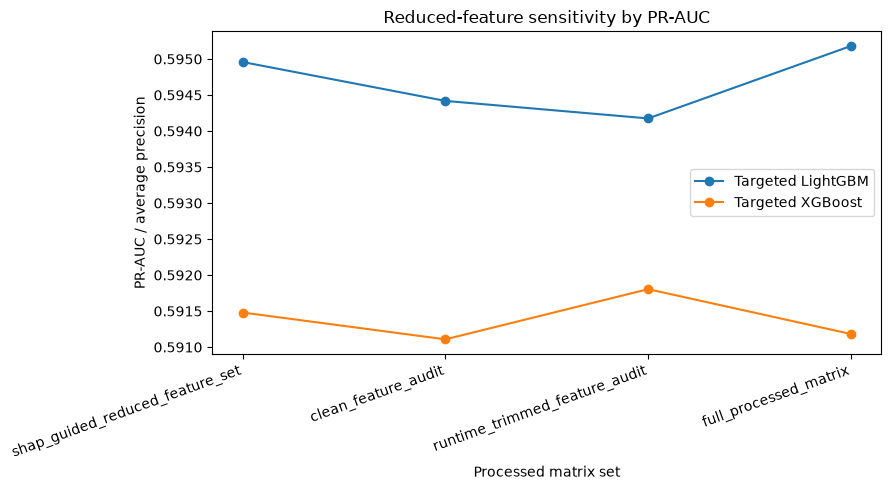

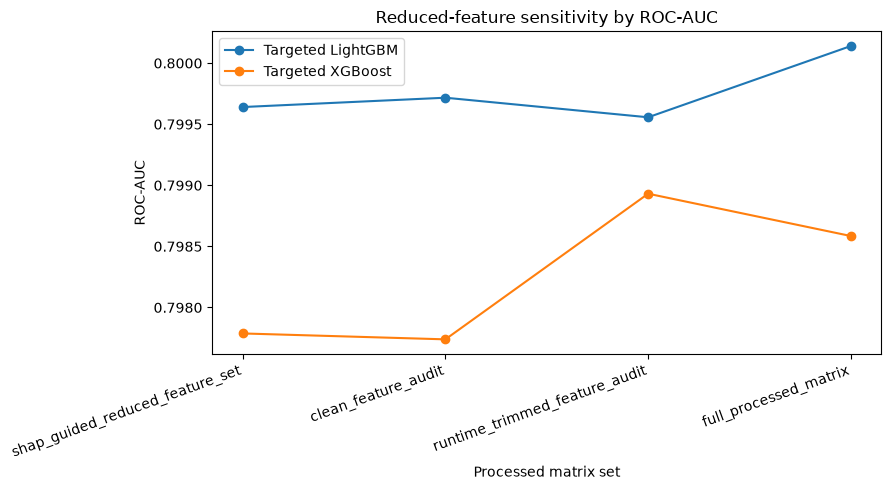

In [ ]:
#plot reduced-feature pr-auc and roc-auc comparison
#numeric x-positions avoid matplotlib category issues when a matrix set is missing or ordered categorically
if not reduced_feature_change_df.empty:
    plot_df = reduced_feature_change_df.copy()
    label_order = ["shap_guided_reduced_feature_set", "clean_feature_audit",
        "runtime_trimmed_feature_audit", "full_processed_matrix"]
    plot_df = plot_df.loc[plot_df["matrix_set"].isin(label_order)].copy()
    plot_df["matrix_set"] = pd.Categorical(plot_df["matrix_set"], categories=label_order, ordered=True)
    plot_df = plot_df.sort_values(["model_family", "matrix_set"])
    x_lookup = {matrix_set: index for index, matrix_set in enumerate(label_order)}
    plot_df["matrix_set_position"] = plot_df["matrix_set"].astype(str).map(x_lookup)

    plt.figure(figsize=(9, 5))
    for model_family, model_df in plot_df.groupby("model_family", observed=True):
        model_df = model_df.dropna(subset=["matrix_set_position"])
        plt.plot(model_df["matrix_set_position"], model_df["pr_auc_average_precision"], marker="o", label=model_family)
    plt.ylabel("PR-AUC / average precision")
    plt.xlabel("Processed matrix set")
    plt.title("Reduced-feature sensitivity by PR-AUC")
    plt.xticks(range(len(label_order)), label_order, rotation=20, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig(reduced_sensitivity_image_path / "t3_reduced_feature_pr_auc_comparison.png", dpi=300)
    plt.show()

    plt.figure(figsize=(9, 5))
    for model_family, model_df in plot_df.groupby("model_family", observed=True):
        model_df = model_df.dropna(subset=["matrix_set_position"])
        plt.plot(model_df["matrix_set_position"], model_df["roc_auc"], marker="o", label=model_family)
    plt.ylabel("ROC-AUC")
    plt.xlabel("Processed matrix set")
    plt.title("Reduced-feature sensitivity by ROC-AUC")
    plt.xticks(range(len(label_order)), label_order, rotation=20, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig(reduced_sensitivity_image_path / "t3_reduced_feature_roc_auc_comparison.png", dpi=300)
    plt.show()
else:
    print("Reduced-feature plots skipped because comparison rows are unavailable.")

In [ ]:
#write final reduced-feature sensitivity workbook and file summary - some reduced-sensitivity model cells may be skipped to save runtime
workbook_path = reduced_sensitivity_output_path / "t3_reduced_feature_sensitivity_tables.xlsx"
reduced_sensitivity_workbook_tables = {"matrix_summary": reduced_matrix_summary_df,
    "removed_features": removed_feature_summary_df,
    "shap_guided_feature_summary": shap_guided_feature_summary_df,
    "shap_guided_removed_features": removed_shap_guided_features_df,
    "model_performance": reduced_model_comparison_df if "reduced_model_comparison_df" in globals() else pd.DataFrame(),
    "metric_changes_vs_primary": reduced_feature_change_df if "reduced_feature_change_df" in globals() else pd.DataFrame(),
    "lightgbm_results": lightgbm_reduced_sensitivity_df if "lightgbm_reduced_sensitivity_df" in globals() else pd.DataFrame(),
    "xgboost_results": xgboost_reduced_sensitivity_df if "xgboost_reduced_sensitivity_df" in globals() else pd.DataFrame(),
    "full_vs_shap_030_perf": fixed_threshold_matrix_comparison_df if "fixed_threshold_matrix_comparison_df" in globals() else pd.DataFrame(),
    "full_vs_shap_030_reclass": full_vs_shap_guided_reclassification_df if "full_vs_shap_guided_reclassification_df" in globals() else pd.DataFrame(),
    "full_only_feature_rank": full_only_feature_importance_rank_df if "full_only_feature_importance_rank_df" in globals() else pd.DataFrame(),
    "full_only_family_summary": full_only_feature_family_summary_df if "full_only_feature_family_summary_df" in globals() else pd.DataFrame()}

with pd.ExcelWriter(workbook_path) as writer:
    for sheet_name, table_df in reduced_sensitivity_workbook_tables.items():
        if table_df is not None and not table_df.empty:
            table_df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

output_summary_rows = []
for file_path in sorted(reduced_sensitivity_output_path.rglob("*")):
    if file_path.is_file():
        output_summary_rows.append({"output_folder": str(file_path.parent.relative_to(reduced_sensitivity_output_path)),
            "output_file": file_path.name,
            "file_size_mb": round(file_path.stat().st_size / (1024 * 1024), 3)})

reduced_sensitivity_output_summary_df = pd.DataFrame(output_summary_rows)
reduced_sensitivity_output_summary_df.to_csv(reduced_sensitivity_csv_path / "t3_reduced_feature_output_file_summary.csv", index=False)
reduced_sensitivity_output_summary_df.to_excel(reduced_sensitivity_output_path / "t3_reduced_feature_output_file_summary.xlsx", index=False)

print("Reduced-feature sensitivity workbook:")
print(workbook_path)
print("Output files:")
display(reduced_sensitivity_output_summary_df)
print("Reduced-feature sensitivity analysis complete. Outputs saved to:")
print(reduced_sensitivity_output_path)

Reduced-feature sensitivity workbook:
/scratch/DissProject/outputs/WP3_6/reduced_feature_sensitivity/t3_reduced_feature_sensitivity_tables.xlsx
Output files:


,output_folder,output_file,file_size_mb
0,csv_tables,t3_6_full_better_than_shap_guided_threshold_03...,0.309
1,csv_tables,t3_6_full_only_feature_family_summary.csv,0.002
2,csv_tables,t3_6_full_only_feature_importance_rank.csv,0.134
3,csv_tables,t3_6_full_vs_shap_guided_threshold_030_perform...,0.001
4,csv_tables,t3_6_full_vs_shap_guided_threshold_030_reclass...,0.001
5,csv_tables,t3_6_targeted_lightgbm_full_vs_shap_guided_thr...,7.227
6,csv_tables,t3_6_targeted_xgboost_full_vs_shap_guided_thre...,6.436
7,csv_tables,t3_reduced_feature_metric_changes_vs_primary.csv,0.002
8,csv_tables,t3_reduced_feature_model_performance_compariso...,0.004
9,csv_tables,t3_reduced_feature_output_file_summary.csv,0.005


Reduced-feature sensitivity analysis complete. Outputs saved to:
/scratch/DissProject/outputs/WP3_6/reduced_feature_sensitivity


**Full Versus Reduced Feature-Set Sensitivity**

The feature audit can create reduced processed matrices. This section records which reduced feature sets are available and collects reduced-feature model outputs generated by the sensitivity cells above.

In [ ]:
#summarise reduced feature-set availability from the current wp3.1 primary matrix files
primary_reduced_summary_path = wp3_1_output_path / f"t3_1_rebuilt_reduced_matrix_summary_{wp3_input_variant}.csv"
primary_reduced_features_path = wp3_1_output_path / f"t3_1_processed_feature_names_{wp3_input_variant}.csv"
primary_removed_features_path = wp3_1_output_path / f"t3_1_removed_processed_feature_names_{wp3_input_variant}.csv"

reduced_feature_set_summary_df = pd.DataFrame()
if primary_reduced_summary_path.exists():
    reduced_feature_set_summary_df = pd.read_csv(primary_reduced_summary_path)
elif primary_reduced_features_path.exists():
    reduced_feature_set_summary_df = pd.DataFrame([{"matrix_set": wp3_input_variant,
        "processed_feature_count": len(pd.read_csv(primary_reduced_features_path)),
        "summary_source": str(primary_reduced_features_path)}])
else:
    print("Primary reduced feature-name file not found:", primary_reduced_features_path)

if primary_removed_features_path.exists():
    recommended_removed_features_df = pd.read_csv(primary_removed_features_path)
    if "matrix_set" not in recommended_removed_features_df.columns:
        recommended_removed_features_df.insert(0, "matrix_set", wp3_input_variant)
else:
    recommended_removed_features_df = pd.DataFrame()

#optional performance comparison if reduced-feature models are trained and saved later
reduced_feature_performance_files = [
    wp3_output_path / "t3_6_reduced_feature_model_performance_comparison.csv",
    wp3_6_csv_output_path / "t3_6_reduced_feature_model_performance_comparison.csv",
    reduced_sensitivity_csv_path / "t3_reduced_model_performance_comparison.csv",
    reduced_sensitivity_csv_path / "t3_reduced_lightgbm_targeted_performance_comparison.csv"]

reduced_feature_performance_frames = []
#loop through each item in this feature block
for reduced_performance_path in reduced_feature_performance_files:
    if reduced_performance_path.exists():
        temp_df = pd.read_csv(reduced_performance_path)
        temp_df.insert(0, "source_file", reduced_performance_path.name)
        reduced_feature_performance_frames.append(temp_df)

if reduced_feature_performance_frames:
    reduced_feature_performance_df = pd.concat(reduced_feature_performance_frames, ignore_index=True).drop_duplicates()
else:
    reduced_feature_performance_df = pd.DataFrame()

#save this table or artefact for later review
reduced_feature_set_summary_df.to_csv(wp3_6_csv_output_path / "t3_6_reduced_feature_set_summary.csv", index=False)
recommended_removed_features_df.to_csv(wp3_6_csv_output_path / "t3_6_reduced_feature_removed_features.csv", index=False)
reduced_feature_performance_df.to_csv(wp3_6_csv_output_path / "t3_6_reduced_feature_performance_comparison.csv", index=False)

print("Primary reduced feature-set summary rows:", len(reduced_feature_set_summary_df))
if not reduced_feature_set_summary_df.empty:
    display(reduced_feature_set_summary_df)

print("Primary reduced removed-feature rows:", len(recommended_removed_features_df))
if not recommended_removed_features_df.empty:
    display(recommended_removed_features_df.head(30))

if reduced_feature_performance_df.empty:
    print("No reduced-feature model performance files were found yet. This is fine before official model reruns finish.")
else:
    print("Reduced-feature model performance rows:", len(reduced_feature_performance_df))
    display(reduced_feature_performance_df)

Primary reduced feature-set summary rows: 14


,field,value
0,source_matrix_suffix,clean_feature_audit
1,rebuilt_matrix_suffix,shap_guided_reduced_feature_set
2,core_requested_feature_count,891
3,high_recent_shap_signal_feature_count,321
4,clinically_relevant_non_sparse_extra_count,321
5,explicit_aftercare_addback_feature_count,27
6,missing_core_requested_features,0
7,original_clean_feature_count,1604
8,primary_reduced_feature_count,954
9,dropped_feature_count,650


Primary reduced removed-feature rows: 650


,matrix_set,processed_feature_name
0,shap_guided_reduced_feature_set,num__non_english_language_flag
1,shap_guided_reduced_feature_set,num__medicare_flag
2,shap_guided_reduced_feature_set,num__insurance_missing_flag
3,shap_guided_reduced_feature_set,num__admitted_from_facility_flag
4,shap_guided_reduced_feature_set,num__transfer_from_hospital_flag
5,shap_guided_reduced_feature_set,num__transfer_from_snf_flag
6,shap_guided_reduced_feature_set,num__internal_transfer_from_psych_flag
7,shap_guided_reduced_feature_set,num__los_under_2_days
8,shap_guided_reduced_feature_set,num__los_under_7_days
9,shap_guided_reduced_feature_set,num__los_7_to_30_days


Reduced-feature model performance rows: 12


,source_file,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc_average_precision,brier_score,true_negatives,false_positives,false_negatives,true_positives,model_family,matrix_set,processed_features,removed_processed_features,threshold_role,training_roc_auc,training_pr_auc_average_precision,training_time_seconds,train_inference_time_seconds,test_inference_time_seconds,test_inference_time_per_admission_ms
0,t3_6_reduced_feature_model_performance_compari...,Targeted LightGBM shap_guided_reduced_feature_set,0.30,0.807509,0.710111,0.511956,0.549093,0.871130,0.529875,0.799640,0.594958,0.118317,32974,4878,4202,5117,Targeted LightGBM,shap_guided_reduced_feature_set,954,720,training_f1,0.881666,0.712407,30.935590,0.382160,0.093021,0.001972
1,t3_6_reduced_feature_model_performance_compari...,Targeted LightGBM clean_feature_audit,0.30,0.807445,0.709708,0.511824,0.548127,0.871288,0.529354,0.799717,0.594418,0.118394,32980,4872,4211,5108,Targeted LightGBM,clean_feature_audit,1604,70,training_f1,0.881906,0.712487,44.083296,0.416065,0.118776,0.002518
2,t3_6_reduced_feature_model_performance_compari...,Targeted LightGBM runtime_trimmed_feature_audit,0.30,0.807339,0.709440,0.511579,0.547591,0.871288,0.528973,0.799557,0.594175,0.118411,32980,4872,4216,5103,Targeted LightGBM,runtime_trimmed_feature_audit,1574,100,training_f1,0.882250,0.712839,43.537192,0.456604,0.093268,0.001977
3,t3_6_reduced_feature_model_performance_compari...,Targeted LightGBM full_processed_matrix,0.29,0.802760,0.712127,0.500717,0.562292,0.861962,0.529721,0.800140,0.595180,0.118270,32627,5225,4079,5240,Targeted LightGBM,full_processed_matrix,1674,0,training_f1,0.882385,0.713088,43.310932,0.476243,0.116873,0.002478
4,t3_6_reduced_feature_model_performance_compari...,Targeted XGBoost shap_guided_reduced_feature_set,0.41,0.810986,0.706575,0.521102,0.533963,0.879187,0.527454,0.797788,0.591480,0.126813,33279,4573,4343,4976,Targeted XGBoost,shap_guided_reduced_feature_set,954,720,training_f1,0.894618,0.734140,40.944092,0.346600,0.085515,0.001813
5,t3_6_reduced_feature_model_performance_compari...,Targeted XGBoost clean_feature_audit,0.40,0.806746,0.708908,0.510155,0.547162,0.870654,0.528011,0.797739,0.591108,0.126848,32956,4896,4220,5099,Targeted XGBoost,clean_feature_audit,1604,70,training_f1,0.894360,0.734222,60.717431,0.401767,0.100366,0.002128
6,t3_6_reduced_feature_model_performance_compari...,Targeted XGBoost runtime_trimmed_feature_audit,0.40,0.807403,0.709965,0.511705,0.548879,0.871050,0.529640,0.798931,0.591804,0.126755,32971,4881,4204,5115,Targeted XGBoost,runtime_trimmed_feature_audit,1574,100,training_f1,0.893792,0.732639,60.070775,0.409522,0.101685,0.002156
7,t3_6_reduced_feature_model_performance_compari...,Targeted XGBoost full_processed_matrix,0.41,0.811176,0.706573,0.521607,0.533641,0.879504,0.527555,0.798585,0.591182,0.126831,33291,4561,4346,4973,Targeted XGBoost,full_processed_matrix,1674,0,training_f1,0.894534,0.733601,61.230193,0.410226,0.101980,0.002162
8,t3_reduced_lightgbm_targeted_performance_compa...,Targeted LightGBM shap_guided_reduced_feature_set,0.30,0.807509,0.710111,0.511956,0.549093,0.871130,0.529875,0.799640,0.594958,0.118317,32974,4878,4202,5117,Targeted LightGBM,shap_guided_reduced_feature_set,954,720,training_f1,0.881666,0.712407,30.935590,0.382160,0.093021,0.001972
9,t3_reduced_lightgbm_targeted_performance_compa...,Targeted LightGBM clean_feature_audit,0.30,0.807445,0.709708,0.511824,0.548127,0.871288,0.529354,0.799717,0.594418,0.118394,32980,4872,4211,5108,Targeted LightGBM,clean_feature_audit,1604,70,training_f1,0.881906,0.712487,44.083296,0.416065,0.118776,0.002518


**Top-N SHAP feature sensitivity**

This sensitivity test trains the same Targeted LightGBM configuration using configured Top-N SHAP-ranked predictor subsets from the current primary matrix. It belongs in WP3.6 because it evaluates model performance; WP4 remains the explanation notebook.




In [ ]:
#train the primary targeted lightgbm model on top-n shap-ranked feature subsets
#the primary matrix is already reduced; this cell checks even smaller explanation-focused subsets
top_n_feature_sensitivity_df = pd.DataFrame()
top_n_feature_names_df = pd.DataFrame()

if not lightgbm_available:
    print("Top-N feature sensitivity skipped because LightGBM is unavailable.")
else:
    primary_matrix_info = next((item for item in matrix_set_registry if item["matrix_set"] == wp3_input_variant), None)
    shap_ranking_path = wp4_csv_output_path / "t4_shap_global_importance.csv"
    if primary_matrix_info is None:
        print("Top-N feature sensitivity skipped because the primary matrix set is not available:", wp3_input_variant)
    elif not shap_ranking_path.exists():
        print("Top-N feature sensitivity skipped because WP4 SHAP ranking is unavailable:", shap_ranking_path)
    else:
        X_train_primary, X_test_primary, primary_feature_names_for_topn = load_matrix_set(primary_matrix_info)
        shap_ranking_df = pd.read_csv(shap_ranking_path).drop_duplicates("processed_feature_name")
        shap_ranking_df = shap_ranking_df.loc[shap_ranking_df["processed_feature_name"].isin(primary_feature_names_for_topn)].copy()
        shap_ranking_df = shap_ranking_df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
        feature_position_lookup = {feature_name: idx for idx, feature_name in enumerate(primary_feature_names_for_topn)}
        top_n_rows = []
        top_n_feature_rows = []

        #loop through each item in this feature block
        for top_n in [700, 600, 500, 400, 300, 200, 100, 50, 20,10, 5, 3, 1]:
            selected_feature_names = shap_ranking_df.head(min(top_n, len(shap_ranking_df)))["processed_feature_name"].tolist()
            selected_positions = [feature_position_lookup[feature_name] for feature_name in selected_feature_names]
            X_train_topn = X_train_primary[:, selected_positions]
            X_test_topn = X_test_primary[:, selected_positions]

            model_label = f"Targeted LightGBM top {len(selected_feature_names)} SHAP features"
            print("Training", model_label)
            topn_model = LGBMClassifier(**lightgbm_reduced_config, objective="binary",
                class_weight={0: 1.0, 1: scale_pos_weight * lightgbm_scale_pos_weight_multiplier},
                random_state=42, n_jobs=-1, verbosity=-1, force_col_wise=True)

            training_start = time.perf_counter()
            #fit the model on the current training data
            topn_model.fit(X_train_topn, y_train)
            training_time_seconds = time.perf_counter() - training_start
            #score admissions as predicted readmission probabilities
            train_probability = topn_model.predict_proba(X_train_topn)[:, 1]
            test_probability = topn_model.predict_proba(X_test_topn)[:, 1]
            threshold_df = threshold_search_table(model_label, y_train, train_probability)
            selected_threshold = float(threshold_df.sort_values(["f1_score", "pr_auc_average_precision"], ascending=False).iloc[0]["threshold"])
            metrics = evaluate_probability_at_threshold(model_label, y_test, test_probability, selected_threshold)
            metrics.update({"matrix_set": wp3_input_variant,
                "top_n_requested": top_n,
                "selected_feature_count": len(selected_feature_names),
                "threshold_role": "training_f1",
                "training_roc_auc": roc_auc_score(y_train, train_probability),
                "training_pr_auc_average_precision": average_precision_score(y_train, train_probability),
                "training_time_seconds": training_time_seconds})
            top_n_rows.append(metrics)

            #loop through each item in this feature block
            for rank, feature_name in enumerate(selected_feature_names, start=1):
                top_n_feature_rows.append({"top_n_requested": top_n,
                    "feature_rank": rank,
                    "processed_feature_name": feature_name})

            print("Top N:", top_n, "Test PR-AUC:", round(metrics["pr_auc_average_precision"], 4),
                "Test ROC-AUC:", round(metrics["roc_auc"], 4), "Training seconds:", round(training_time_seconds, 2))

        top_n_feature_sensitivity_df = pd.DataFrame(top_n_rows).sort_values(
            ["pr_auc_average_precision", "roc_auc"], ascending=False).reset_index(drop=True)
        top_n_feature_names_df = pd.DataFrame(top_n_feature_rows)
        #save this table or artefact for later review
        top_n_feature_sensitivity_df.to_csv(wp3_6_csv_output_path / "t3_6_top_n_shap_feature_sensitivity.csv", index=False)
        top_n_feature_names_df.to_csv(wp3_6_csv_output_path / "t3_6_top_n_shap_feature_names.csv", index=False)

        print("Top-N SHAP feature sensitivity results:")
        display(top_n_feature_sensitivity_df)

Training Targeted LightGBM top 700 SHAP features
Top N: 700 Test PR-AUC: 0.5948 Test ROC-AUC: 0.8002 Training seconds: 25.33
Training Targeted LightGBM top 600 SHAP features
Top N: 600 Test PR-AUC: 0.5941 Test ROC-AUC: 0.799 Training seconds: 22.03
Training Targeted LightGBM top 500 SHAP features
Top N: 500 Test PR-AUC: 0.5947 Test ROC-AUC: 0.8 Training seconds: 17.5
Training Targeted LightGBM top 400 SHAP features
Top N: 400 Test PR-AUC: 0.5938 Test ROC-AUC: 0.799 Training seconds: 14.37
Training Targeted LightGBM top 300 SHAP features
Top N: 300 Test PR-AUC: 0.5944 Test ROC-AUC: 0.7992 Training seconds: 12.45
Training Targeted LightGBM top 200 SHAP features
Top N: 200 Test PR-AUC: 0.5926 Test ROC-AUC: 0.7978 Training seconds: 10.21
Training Targeted LightGBM top 100 SHAP features
Top N: 100 Test PR-AUC: 0.5894 Test ROC-AUC: 0.7962 Training seconds: 8.0
Training Targeted LightGBM top 50 SHAP features
Top N: 50 Test PR-AUC: 0.5774 Test ROC-AUC: 0.7885 Training seconds: 6.86
Training Ta

,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc_average_precision,brier_score,true_negatives,false_positives,false_negatives,true_positives,matrix_set,top_n_requested,selected_feature_count,threshold_role,training_roc_auc,training_pr_auc_average_precision,training_time_seconds
0,Targeted LightGBM top 700 SHAP features,0.29,0.802082,0.712028,0.499191,0.563151,0.860906,0.529246,0.800203,0.594813,0.118317,32587,5265,4071,5248,shap_guided_reduced_feature_set,700,700,training_f1,0.881420,0.712018,25.333810
1,Targeted LightGBM top 500 SHAP features,0.30,0.807636,0.709908,0.512281,0.548342,0.871473,0.529698,0.800016,0.594741,0.118331,32987,4865,4209,5110,shap_guided_reduced_feature_set,500,500,training_f1,0.880711,0.710409,17.497380
2,Targeted LightGBM top 300 SHAP features,0.30,0.807700,0.710513,0.512400,0.549844,0.871183,0.530462,0.799179,0.594418,0.118421,32976,4876,4195,5124,shap_guided_reduced_feature_set,300,300,training_f1,0.875036,0.702268,12.447782
3,Targeted LightGBM top 600 SHAP features,0.30,0.807657,0.709799,0.512339,0.548020,0.871579,0.529580,0.799020,0.594092,0.118443,32991,4861,4212,5107,shap_guided_reduced_feature_set,600,600,training_f1,0.881368,0.711239,22.034517
4,Targeted LightGBM top 400 SHAP features,0.31,0.812152,0.708475,0.523974,0.537075,0.879874,0.530444,0.798971,0.593810,0.118518,33305,4547,4314,5005,shap_guided_reduced_feature_set,400,400,training_f1,0.878600,0.707598,14.369431
5,Targeted LightGBM top 200 SHAP features,0.30,0.806173,0.709360,0.508746,0.549308,0.869412,0.528249,0.797769,0.592558,0.118754,32909,4943,4200,5119,shap_guided_reduced_feature_set,200,200,training_f1,0.869374,0.693171,10.214238
6,Targeted LightGBM top 100 SHAP features,0.31,0.808484,0.704531,0.514778,0.532675,0.876387,0.523573,0.796169,0.589440,0.119265,33173,4679,4355,4964,shap_guided_reduced_feature_set,100,100,training_f1,0.855618,0.671211,7.999009
7,Targeted LightGBM top 50 SHAP features,0.31,0.807212,0.698764,0.511896,0.519476,0.878051,0.515658,0.788482,0.577353,0.121049,33236,4616,4478,4841,shap_guided_reduced_feature_set,50,50,training_f1,0.835315,0.641266,6.862425
8,Targeted LightGBM top 20 SHAP features,0.28,0.792796,0.693624,0.477970,0.529671,0.857577,0.502494,0.761740,0.557870,0.124152,32461,5391,4383,4936,shap_guided_reduced_feature_set,20,20,training_f1,0.807437,0.606144,5.734346
9,Targeted LightGBM top 10 SHAP features,0.28,0.786267,0.679282,0.462328,0.502414,0.856150,0.481539,0.741816,0.519750,0.128876,32407,5445,4637,4682,shap_guided_reduced_feature_set,10,10,training_f1,0.775766,0.554289,4.765653


### **3.6.5 Calibration Analysis**

**Calibration and risk calibration summaries**

This checks whether predicted probabilities align with observed readmission rates. It uses saved test-set predictions only, so no official model is refit here.




,model_family,mean_absolute_calibration_error,max_absolute_calibration_error,brier_score,mean_predicted_probability,observed_readmission_rate
9,Targeted LightGBM,0.018955,0.028500,0.118204,0.216512,0.197558
30,Ensemble - LightGBM-heavy blend 90,0.025755,0.039423,0.118489,0.223313,0.197558
12,Targeted CatBoost,0.020191,0.032656,0.118707,0.217749,0.197558
29,Ensemble - LightGBM-heavy blend 80,0.032556,0.049557,0.118896,0.230113,0.197558
10,Calibrated Targeted LightGBM,0.005426,0.013635,0.119415,0.193856,0.197558
28,Ensemble - LightGBM-heavy blend 70,0.039357,0.058287,0.119424,0.236914,0.197558
23,Ensemble - boosting top 3 average,0.042977,0.067605,0.119945,0.240535,0.197558
27,Ensemble - LightGBM-heavy blend 60,0.046157,0.069428,0.120073,0.243715,0.197558
7,Calibrated Targeted XGBoost,0.015857,0.025277,0.120630,0.193696,0.197558
13,Calibrated Targeted CatBoost,0.023611,0.039693,0.120749,0.193494,0.197558


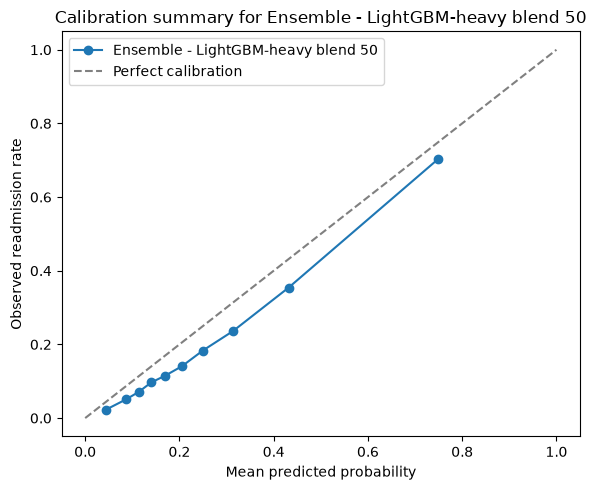

In [ ]:
#summarise calibration from saved test-set predictions
def calibration_summary_table(prediction_df, model_family, n_bins=10):
    model_predictions = prediction_df.loc[prediction_df["model_family"] == model_family].copy()
    if model_predictions.empty:
        return pd.DataFrame(), pd.DataFrame()
    model_predictions["probability_bin"] = pd.qcut(model_predictions["predicted_probability"],
        q=n_bins, duplicates="drop")
    
    #summarise row-level records to admission-level features
    calibration_df = model_predictions.groupby("probability_bin", observed=True).agg(
        admissions=("readmitted_30d", "size"),
        observed_readmission_rate=("readmitted_30d", "mean"),
        mean_predicted_probability=("predicted_probability", "mean"),
        min_predicted_probability=("predicted_probability", "min"),
        max_predicted_probability=("predicted_probability", "max")).reset_index()
    calibration_df["model_family"] = model_family
    calibration_df["absolute_calibration_error"] = (
        calibration_df["observed_readmission_rate"] - calibration_df["mean_predicted_probability"]).abs()
    summary_df = pd.DataFrame([{"model_family": model_family,
        "mean_absolute_calibration_error": calibration_df["absolute_calibration_error"].mean(),
        "max_absolute_calibration_error": calibration_df["absolute_calibration_error"].max(),
        "brier_score": brier_score_loss(model_predictions["readmitted_30d"], model_predictions["predicted_probability"]),
        "mean_predicted_probability": model_predictions["predicted_probability"].mean(),
        "observed_readmission_rate": model_predictions["readmitted_30d"].mean()}])
    return calibration_df, summary_df

calibration_frames = []
calibration_summary_frames = []
if not all_prediction_df.empty:
    #loop through each item in this feature block
    for model_family in all_prediction_df["model_family"].dropna().unique():
        calibration_df, summary_df = calibration_summary_table(all_prediction_df, model_family)
        if not calibration_df.empty:
            calibration_frames.append(calibration_df)
            calibration_summary_frames.append(summary_df)

if calibration_frames:
    calibration_table_df = pd.concat(calibration_frames, ignore_index=True)
    calibration_summary_df = pd.concat(calibration_summary_frames, ignore_index=True)
else:
    calibration_table_df = pd.DataFrame()
    calibration_summary_df = pd.DataFrame()

#save this table or artefact for later review
calibration_table_df.to_csv(wp3_6_csv_output_path / "t3_6_probability_calibration_bins.csv", index=False)
calibration_summary_df.to_csv(wp3_6_csv_output_path / "t3_6_probability_calibration_summary.csv", index=False)

if not calibration_summary_df.empty:
    display(calibration_summary_df.sort_values("brier_score").head(15))

if not recommended_model_comparison_df.empty and not calibration_table_df.empty:
    best_model_family = recommended_model_comparison_df.iloc[0]["model_family"]
    best_calibration_df = calibration_table_df.loc[calibration_table_df["model_family"] == best_model_family].copy()
    plt.figure(figsize=(6, 5))
    plt.plot(best_calibration_df["mean_predicted_probability"],
        best_calibration_df["observed_readmission_rate"], marker="o", label=best_model_family)
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed readmission rate")
    plt.title(f"Calibration summary for {best_model_family}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(wp3_6_image_output_path / "t3_6_best_model_calibration_summary.png", dpi=300)
    plt.show()

**Decision-curve style threshold utility**

This gives a simple net-benefit view across clinically plausible decision thresholds. It helps explain whether model-guided review adds value compared with reviewing every admission or reviewing none.




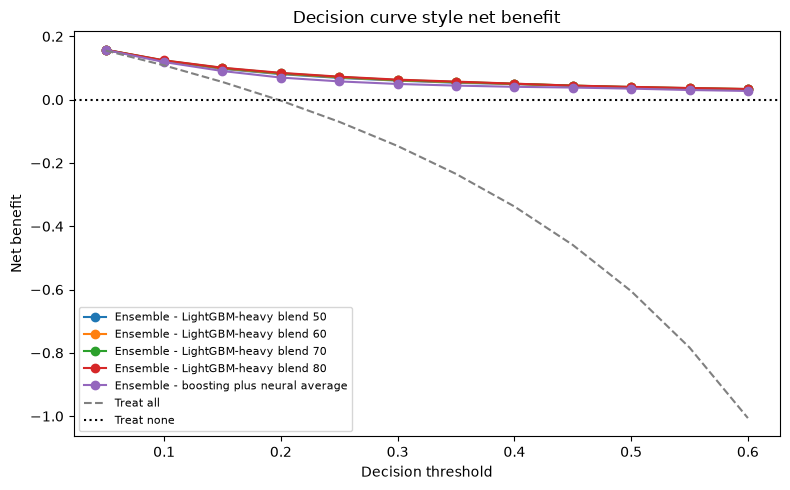

In [ ]:
#calculate simple net benefit across clinically plausible decision thresholds
def net_benefit_rows(prediction_df, model_family, thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.05, 0.61, 0.05), 2)
    model_predictions = prediction_df.loc[prediction_df["model_family"] == model_family].copy()
    if model_predictions.empty:
        return pd.DataFrame()
    y_true = model_predictions["readmitted_30d"].to_numpy()
    y_probability = model_predictions["predicted_probability"].to_numpy()
    n = len(y_true)
    prevalence = y_true.mean()
    rows = []
    #loop through each item in this feature block
    for threshold in thresholds:
        y_predicted = (y_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_predicted, labels=[0, 1]).ravel()
        threshold_odds = threshold / (1 - threshold)
        rows.append({"model_family": model_family,
            "threshold": threshold,
            "net_benefit_model": (tp / n) - (fp / n) * threshold_odds,
            "net_benefit_treat_all": prevalence - (1 - prevalence) * threshold_odds,
            "net_benefit_treat_none": 0,
            "true_positives": tp,
            "false_positives": fp,
            "sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan})
    return pd.DataFrame(rows)

net_benefit_frames = []
if not all_prediction_df.empty:
    for model_family in all_prediction_df["model_family"].dropna().unique():
        net_benefit_frames.append(net_benefit_rows(all_prediction_df, model_family))

if net_benefit_frames:
    net_benefit_df = pd.concat(net_benefit_frames, ignore_index=True)
else:
    net_benefit_df = pd.DataFrame()

#save this table or artefact for later review
net_benefit_df.to_csv(wp3_6_csv_output_path / "t3_6_decision_curve_net_benefit.csv", index=False)
if not recommended_model_comparison_df.empty and not net_benefit_df.empty:
    top_model_families = recommended_model_comparison_df.head(5)["model_family"].tolist()
    plot_net_benefit_df = net_benefit_df.loc[net_benefit_df["model_family"].isin(top_model_families)].copy()
    plt.figure(figsize=(8, 5))
    for model_family, model_df in plot_net_benefit_df.groupby("model_family"):
        plt.plot(model_df["threshold"], model_df["net_benefit_model"], marker="o", label=model_family)
    reference_df = net_benefit_df.loc[net_benefit_df["model_family"] == top_model_families[0]].copy()
    plt.plot(reference_df["threshold"], reference_df["net_benefit_treat_all"], color="gray", linestyle="--", label="Treat all")
    plt.axhline(0, color="black", linestyle=":", label="Treat none")
    plt.xlabel("Decision threshold")
    plt.ylabel("Net benefit")
    plt.title("Decision curve style net benefit")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(wp3_6_image_output_path / "t3_6_decision_curve_net_benefit.png", dpi=300)
    plt.show()

### **3.6.6 Time-Frame and Cutoff Analysis**

**30-day cutoff proximity error review**

This checks whether apparent false positives and false negatives are close to the 30-day readmission threshold. A 27-33 day band is used to identify cutoff-proximal cases where the strict binary label may be clinically ambiguous.




In [ ]:
#review false positives and false negatives close to the 30-day readmission cutoff
cutoff_proximity_error_summary_df = pd.DataFrame()
cutoff_proximity_case_summary_df = pd.DataFrame()
cutoff_proximity_adjusted_metrics_df = pd.DataFrame()
cohort_timing_path = project_path / "outputs" / "psychiatric_readmission_cohort.csv"

if all_prediction_df.empty or recommended_model_comparison_df.empty or not cohort_timing_path.exists():
    print("Cutoff proximity review skipped because predictions, recommended model rows, or cohort timing data are unavailable.")
else:
    best_model_family = recommended_model_comparison_df.iloc[0]["model_family"]
    best_threshold = float(recommended_model_comparison_df.iloc[0]["threshold"])
    best_model_predictions = all_prediction_df.loc[all_prediction_df["model_family"] == best_model_family].copy()

    if not {"subject_id", "hadm_id"}.issubset(best_model_predictions.columns):
        print("Cutoff proximity review skipped because prediction files do not contain subject_id and hadm_id.")
    else:
        cohort_timing_df = pd.read_csv(cohort_timing_path, usecols=["subject_id", "hadm_id", "days_to_next"])
        duplicate_timing_cols = [col for col in ["days_to_next"] if col in best_model_predictions.columns]
        cutoff_prediction_base_df = best_model_predictions.drop(columns=duplicate_timing_cols)
        #join the derived features back to the admission table
        cutoff_review_df = cutoff_prediction_base_df.merge(cohort_timing_df, on=["subject_id", "hadm_id"], how="left")
        cutoff_review_df["predicted_label"] = (cutoff_review_df["predicted_probability"] >= best_threshold).astype(int)
        cutoff_review_df["actual_label"] = cutoff_review_df["readmitted_30d"].astype(int)

        cutoff_review_df["classification_group"] = np.select([
            (cutoff_review_df["actual_label"] == 1) & (cutoff_review_df["predicted_label"] == 1),
            (cutoff_review_df["actual_label"] == 0) & (cutoff_review_df["predicted_label"] == 1),
            (cutoff_review_df["actual_label"] == 1) & (cutoff_review_df["predicted_label"] == 0),
            (cutoff_review_df["actual_label"] == 0) & (cutoff_review_df["predicted_label"] == 0)],
            ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")

        cutoff_review_df["close_to_30_day_cutoff_27_33d"] = cutoff_review_df["days_to_next"].between(27, 33, inclusive="both")
        cutoff_review_df["strict_positive_close_to_cutoff_27_30d"] = cutoff_review_df["days_to_next"].between(27, 30, inclusive="both")
        cutoff_review_df["strict_negative_near_miss_31_33d"] = cutoff_review_df["days_to_next"].between(31, 33, inclusive="both")
        #expanded 33-day view keeps the official 30-day label, then counts 31-33 day near-misses as positives
        cutoff_review_df["readmitted_33d"] = ((cutoff_review_df["actual_label"] == 1) |
            ((cutoff_review_df["actual_label"] == 0) & cutoff_review_df["days_to_next"].between(31, 33, inclusive="both"))).astype(int)

        cutoff_summary_rows = []
        #loop through each item in this feature block
        for classification_group, group_df in cutoff_review_df.groupby("classification_group"):
            row = {"model_family": best_model_family,
                "threshold": best_threshold,
                "classification_group": classification_group,
                "admissions": len(group_df),
                "mean_predicted_probability": group_df["predicted_probability"].mean(),
                "median_predicted_probability": group_df["predicted_probability"].median(),
                "known_next_admission_timing": group_df["days_to_next"].notna().sum(),
                "close_to_30_day_cutoff_27_33d_count": int(group_df["close_to_30_day_cutoff_27_33d"].sum()),
                "close_to_30_day_cutoff_27_33d_percent": group_df["close_to_30_day_cutoff_27_33d"].mean() * 100,
                "strict_positive_close_to_cutoff_27_30d_count": int(group_df["strict_positive_close_to_cutoff_27_30d"].sum()),
                "strict_negative_near_miss_31_33d_count": int(group_df["strict_negative_near_miss_31_33d"].sum())}
            cutoff_summary_rows.append(row)

        cutoff_proximity_error_summary_df = pd.DataFrame(cutoff_summary_rows).sort_values("classification_group")

        #near-miss adjusted view: count false positives with 31-33 day readmission separately from clear false positives
        fp_count = int((cutoff_review_df["classification_group"] == "false_positive").sum())
        fn_count = int((cutoff_review_df["classification_group"] == "false_negative").sum())
        fp_near_miss_31_33 = int(((cutoff_review_df["classification_group"] == "false_positive") &
            cutoff_review_df["strict_negative_near_miss_31_33d"]).sum())
        fn_close_positive_27_30 = int(((cutoff_review_df["classification_group"] == "false_negative") &
            cutoff_review_df["strict_positive_close_to_cutoff_27_30d"]).sum())

        cutoff_proximity_case_summary_df = pd.DataFrame([{"model_family": best_model_family,
            "threshold": best_threshold,
            "false_positives": fp_count,
            "false_positive_near_miss_31_33d": fp_near_miss_31_33,
            "false_positive_near_miss_31_33d_percent": (fp_near_miss_31_33 / fp_count * 100) if fp_count else np.nan,
            "false_negatives": fn_count,
            "false_negative_close_positive_27_30d": fn_close_positive_27_30,
            "false_negative_close_positive_27_30d_percent": (fn_close_positive_27_30 / fn_count * 100) if fn_count else np.nan,
            "all_errors": fp_count + fn_count,
            "all_errors_close_to_30_day_cutoff_27_33d": int(((cutoff_review_df["classification_group"].isin(["false_positive", "false_negative"])) &
                cutoff_review_df["close_to_30_day_cutoff_27_33d"]).sum())}])

        strict_metrics = evaluate_probability_at_threshold(best_model_family + " strict 30-day label",
            cutoff_review_df["actual_label"], cutoff_review_df["predicted_probability"], best_threshold)
        adjusted_metrics = evaluate_probability_at_threshold(best_model_family + " expanded 33-day label",
            cutoff_review_df["readmitted_33d"].astype(int), cutoff_review_df["predicted_probability"], best_threshold)
        cutoff_proximity_adjusted_metrics_df = pd.DataFrame([strict_metrics, adjusted_metrics])

        #save this table or artefact for later review
        cutoff_proximity_error_summary_df.to_csv(wp3_6_csv_output_path / "t3_6_cutoff_proximity_error_summary.csv", index=False)
        cutoff_proximity_case_summary_df.to_csv(wp3_6_csv_output_path / "t3_6_cutoff_proximity_case_summary.csv", index=False)
        cutoff_proximity_adjusted_metrics_df.to_csv(wp3_6_csv_output_path / "t3_6_cutoff_proximity_adjusted_metrics.csv", index=False)

        print("Cutoff proximity error summary:")
        display(cutoff_proximity_error_summary_df)
        print("Cutoff proximity case summary:")
        display(cutoff_proximity_case_summary_df)
        print("Strict 30-day versus expanded 33-day label metrics:")
        display(cutoff_proximity_adjusted_metrics_df[["model", "threshold", "precision", "recall_sensitivity",
            "specificity", "f1_score", "roc_auc", "pr_auc_average_precision", "true_positives",
            "false_positives", "false_negatives", "true_negatives"]])

Cutoff proximity error summary:


,model_family,threshold,classification_group,admissions,mean_predicted_probability,median_predicted_probability,known_next_admission_timing,close_to_30_day_cutoff_27_33d_count,close_to_30_day_cutoff_27_33d_percent,strict_positive_close_to_cutoff_27_30d_count,strict_negative_near_miss_31_33d_count
0,Ensemble - LightGBM-heavy blend 50,0.36,false_negative,4359,0.215452,0.215547,4359,327,7.501721,327,0
1,Ensemble - LightGBM-heavy blend 50,0.36,false_positive,4393,0.500946,0.462580,3398,201,4.575461,20,181
2,Ensemble - LightGBM-heavy blend 50,0.36,true_negative,33459,0.159482,0.147307,15653,408,1.219403,112,296
3,Ensemble - LightGBM-heavy blend 50,0.36,true_positive,4960,0.673618,0.652826,4960,205,4.133065,205,0


Cutoff proximity case summary:


,model_family,threshold,false_positives,false_positive_near_miss_31_33d,false_positive_near_miss_31_33d_percent,false_negatives,false_negative_close_positive_27_30d,false_negative_close_positive_27_30d_percent,all_errors,all_errors_close_to_30_day_cutoff_27_33d
0,Ensemble - LightGBM-heavy blend 50,0.36,4393,181,4.120191,4359,327,7.501721,8752,528


Strict 30-day versus expanded 33-day label metrics:


,model,threshold,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc_average_precision,true_positives,false_positives,false_negatives,true_negatives
0,Ensemble - LightGBM-heavy blend 50 strict 30-d...,0.36,0.530311,0.532246,0.883943,0.531277,0.801201,0.596463,4960,4393,4359,33459
1,Ensemble - LightGBM-heavy blend 50 expanded 33...,0.36,0.549663,0.524806,0.887304,0.536947,0.799925,0.603390,5141,4212,4655,33163


**Psychiatric outcome-window score transfer**

The trained 30-day model stays fixed. The same predicted probabilities are evaluated against 14-, 60-, 90-, and 365-day psychiatric readmission labels to see whether the 30-day model is also ranking broader readmission vulnerability.




In [ ]:
#evaluate 30-day model scores against longer psychiatric readmission windows without retraining
score_transfer_outcome_df = pd.DataFrame()
score_transfer_error_reclassification_df = pd.DataFrame()
score_transfer_model_count = 3
cohort_timing_path = project_path / "outputs" / "psychiatric_readmission_cohort.csv"

if all_prediction_df.empty or recommended_model_comparison_df.empty or not cohort_timing_path.exists():
    print("Psychiatric outcome-window score transfer skipped because predictions, recommended rows, or cohort timing data are unavailable.")
elif not {"subject_id", "hadm_id"}.issubset(all_prediction_df.columns):
    print("Psychiatric outcome-window score transfer skipped because prediction files do not contain subject_id and hadm_id.")
else:
    cohort_timing_df = pd.read_csv(cohort_timing_path,
        usecols=["subject_id", "hadm_id", "days_to_next", "next_is_psych"])
    cohort_timing_df["next_is_psych"] = cohort_timing_df["next_is_psych"].fillna(0).astype(int)

    outcome_windows = [14, 30, 60, 90, 365]
    #loop through each item in this feature block
    for outcome_window_days in outcome_windows:
        cohort_timing_df[f"readmitted_{outcome_window_days}d_psych"] = (
            (cohort_timing_df["next_is_psych"] == 1) &
            cohort_timing_df["days_to_next"].between(0, outcome_window_days, inclusive="both")).astype(int)

    selected_model_rows = recommended_model_comparison_df.sort_values(
        ["pr_auc_average_precision", "roc_auc", "f1_score"], ascending=False).head(score_transfer_model_count).copy()
    transfer_metric_rows = []
    transfer_error_rows = []

    for _, selected_model_row in selected_model_rows.iterrows():
        model_family = selected_model_row["model_family"]
        model_threshold = float(selected_model_row["threshold"])
        model_predictions = all_prediction_df.loc[all_prediction_df["model_family"] == model_family].copy()    
        if model_predictions.empty:
            continue

        model_predictions = model_predictions.sort_values("predicted_probability", ascending=False).drop_duplicates(
            ["subject_id", "hadm_id"], keep="first")
        duplicate_timing_cols = [col for col in cohort_timing_df.columns if col not in ["subject_id", "hadm_id"] and col in model_predictions.columns]
        model_prediction_base_df = model_predictions.drop(columns=duplicate_timing_cols)
        #join the derived features back to the admission table
        transfer_df = model_prediction_base_df.merge(cohort_timing_df, on=["subject_id", "hadm_id"], how="left")
        transfer_df["predicted_label_30d_threshold"] = (transfer_df["predicted_probability"] >= model_threshold).astype(int)
        transfer_df["actual_30d_training_label"] = transfer_df["readmitted_30d"].astype(int)
        transfer_df["classification_group_30d"] = np.select([
            (transfer_df["actual_30d_training_label"] == 1) & (transfer_df["predicted_label_30d_threshold"] == 1),
            (transfer_df["actual_30d_training_label"] == 0) & (transfer_df["predicted_label_30d_threshold"] == 1),
            (transfer_df["actual_30d_training_label"] == 1) & (transfer_df["predicted_label_30d_threshold"] == 0),
            (transfer_df["actual_30d_training_label"] == 0) & (transfer_df["predicted_label_30d_threshold"] == 0)],
            ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")

        #loop through each item in this feature block
        for outcome_window_days in outcome_windows:
            outcome_col = f"readmitted_{outcome_window_days}d_psych"        
            if transfer_df[outcome_col].nunique() < 2:
                continue
            metrics = evaluate_probability_at_threshold(
                f"{model_family} scored against {outcome_window_days}-day psychiatric readmission",
                transfer_df[outcome_col].astype(int), transfer_df["predicted_probability"], model_threshold)
            metrics.update({"model_family": model_family,
                "score_source_target": "trained_for_30d_psychiatric_readmission",
                "evaluation_outcome": f"{outcome_window_days}d_psychiatric_readmission",
                "outcome_window_days": outcome_window_days,
                "outcome_prevalence": transfer_df[outcome_col].mean(),
                "recommended_threshold_label": selected_model_row.get("recommended_threshold_label", "recommended threshold")})
            transfer_metric_rows.append(metrics)

        for classification_group, group_df in transfer_df.groupby("classification_group_30d"):
            row = {"model_family": model_family,
                "threshold": model_threshold,
                "classification_group_30d": classification_group,
                "admissions": len(group_df),
                "mean_30d_predicted_probability": group_df["predicted_probability"].mean(),
                "median_30d_predicted_probability": group_df["predicted_probability"].median()}
            #loop through each item in this feature block
            for outcome_window_days in [14, 60, 90, 365]:
                outcome_col = f"readmitted_{outcome_window_days}d_psych"
                row[f"readmitted_{outcome_window_days}d_psych_count"] = int(group_df[outcome_col].sum())
                row[f"readmitted_{outcome_window_days}d_psych_percent"] = group_df[outcome_col].mean() * 100
            transfer_error_rows.append(row)

    score_transfer_outcome_df = pd.DataFrame(transfer_metric_rows)
    score_transfer_error_reclassification_df = pd.DataFrame(transfer_error_rows)

    #save this table or artefact for later review
    score_transfer_outcome_df.to_csv(wp3_6_csv_output_path / "t3_6_psychiatric_outcome_window_score_transfer.csv", index=False)
    score_transfer_error_reclassification_df.to_csv(
        wp3_6_csv_output_path / "t3_6_psychiatric_outcome_window_error_reclassification.csv", index=False)

    print("30-day model scores evaluated against 14-day and longer psychiatric readmission windows:")

    if not score_transfer_outcome_df.empty:
        display(score_transfer_outcome_df[["model_family", "evaluation_outcome", "outcome_prevalence",
            "roc_auc", "pr_auc_average_precision", "brier_score", "precision", "recall_sensitivity",
            "specificity", "f1_score", "true_positives", "false_positives", "false_negatives", "true_negatives"]].round(4))
    print("30-day error groups rechecked against later psychiatric readmission windows:")
    if not score_transfer_error_reclassification_df.empty:
        display(score_transfer_error_reclassification_df.round(4))

30-day model scores evaluated against 14-day and longer psychiatric readmission windows:


,model_family,evaluation_outcome,outcome_prevalence,roc_auc,pr_auc_average_precision,brier_score,precision,recall_sensitivity,specificity,f1_score,true_positives,false_positives,false_negatives,true_negatives
0,Ensemble - LightGBM-heavy blend 50,14d_psychiatric_readmission,0.1423,0.8058,0.5595,0.1047,0.4158,0.5795,0.8650,0.4842,3889,5464,2822,34996
1,Ensemble - LightGBM-heavy blend 50,30d_psychiatric_readmission,0.1976,0.8012,0.5965,0.1208,0.5303,0.5322,0.8839,0.5313,4960,4393,4359,33459
2,Ensemble - LightGBM-heavy blend 50,60d_psychiatric_readmission,0.2490,0.7980,0.6355,0.1390,0.6223,0.4956,0.9003,0.5517,5820,3533,5924,31894
3,Ensemble - LightGBM-heavy blend 50,90d_psychiatric_readmission,0.2803,0.7963,0.6582,0.1515,0.6682,0.4727,0.9086,0.5537,6250,3103,6971,30847
4,Ensemble - LightGBM-heavy blend 50,365d_psychiatric_readmission,0.3843,0.7824,0.7140,0.2024,0.7671,0.3958,0.9250,0.5221,7175,2178,10955,26863
5,Ensemble - LightGBM-heavy blend 60,14d_psychiatric_readmission,0.1423,0.8058,0.5595,0.1030,0.4158,0.5795,0.8649,0.4842,3889,5465,2822,34995
6,Ensemble - LightGBM-heavy blend 60,30d_psychiatric_readmission,0.1976,0.8012,0.5964,0.1201,0.5307,0.5327,0.8840,0.5317,4964,4390,4355,33462
7,Ensemble - LightGBM-heavy blend 60,60d_psychiatric_readmission,0.2490,0.7979,0.6354,0.1391,0.6222,0.4956,0.9002,0.5517,5820,3534,5924,31893
8,Ensemble - LightGBM-heavy blend 60,90d_psychiatric_readmission,0.2803,0.7962,0.6580,0.1522,0.6682,0.4727,0.9086,0.5537,6250,3104,6971,30846
9,Ensemble - LightGBM-heavy blend 60,365d_psychiatric_readmission,0.3843,0.7822,0.7138,0.2047,0.7671,0.3958,0.9250,0.5221,7175,2179,10955,26862


30-day error groups rechecked against later psychiatric readmission windows:


,model_family,threshold,classification_group_30d,admissions,mean_30d_predicted_probability,median_30d_predicted_probability,readmitted_14d_psych_count,readmitted_14d_psych_percent,readmitted_60d_psych_count,readmitted_60d_psych_percent,readmitted_90d_psych_count,readmitted_90d_psych_percent,readmitted_365d_psych_count,readmitted_365d_psych_percent
0,Ensemble - LightGBM-heavy blend 50,0.36,false_negative,4359,0.2155,0.2155,2822,64.7396,4359,100.0000,4359,100.0000,4359,100.0000
1,Ensemble - LightGBM-heavy blend 50,0.36,false_positive,4393,0.5009,0.4626,0,0.0000,860,19.5766,1290,29.3649,2215,50.4211
2,Ensemble - LightGBM-heavy blend 50,0.36,true_negative,33459,0.1595,0.1473,0,0.0000,1565,4.6774,2612,7.8066,6596,19.7137
3,Ensemble - LightGBM-heavy blend 50,0.36,true_positive,4960,0.6736,0.6528,3889,78.4073,4960,100.0000,4960,100.0000,4960,100.0000
4,Ensemble - LightGBM-heavy blend 60,0.35,false_negative,4355,0.2074,0.2069,2822,64.7991,4355,100.0000,4355,100.0000,4355,100.0000
5,Ensemble - LightGBM-heavy blend 60,0.35,false_positive,4390,0.4916,0.4526,0,0.0000,856,19.4989,1286,29.2938,2211,50.3645
6,Ensemble - LightGBM-heavy blend 60,0.35,true_negative,33462,0.1532,0.1409,0,0.0000,1569,4.6889,2616,7.8178,6600,19.7239
7,Ensemble - LightGBM-heavy blend 60,0.35,true_positive,4964,0.6664,0.6442,3889,78.3441,4964,100.0000,4964,100.0000,4964,100.0000
8,Ensemble - LightGBM-heavy blend 70,0.34,false_negative,4350,0.1994,0.1988,2819,64.8046,4350,100.0000,4350,100.0000,4350,100.0000
9,Ensemble - LightGBM-heavy blend 70,0.34,false_positive,4395,0.4820,0.4427,0,0.0000,858,19.5222,1289,29.3288,2210,50.2844


**Error anatomy and boundary sensitivity**

This section looks beyond the headline confusion matrix: near-cutoff readmissions, false positives that later become readmissions, and borderline probabilities around the selected threshold.




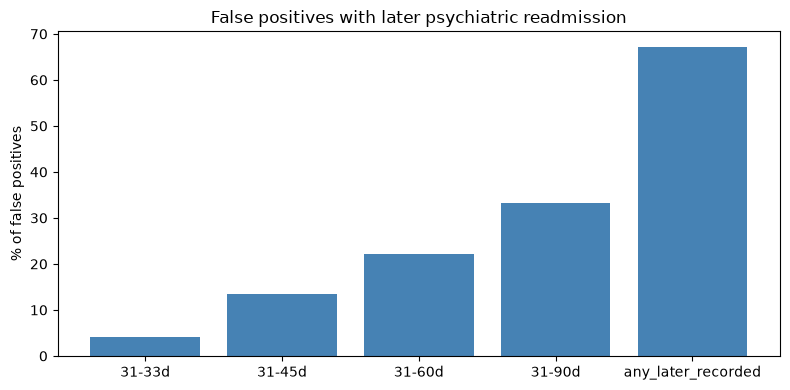

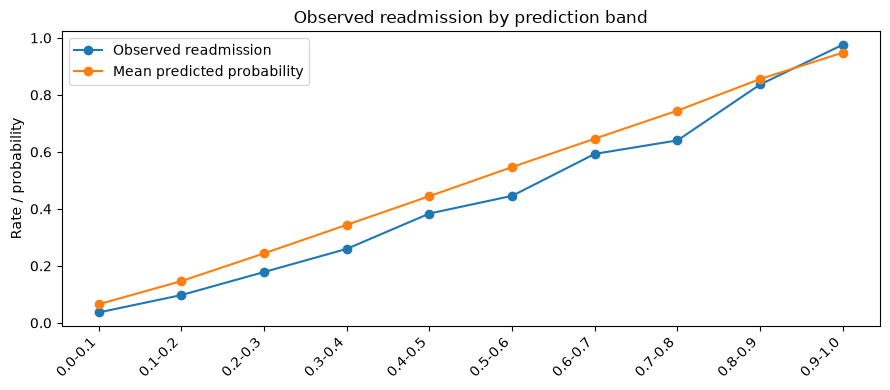

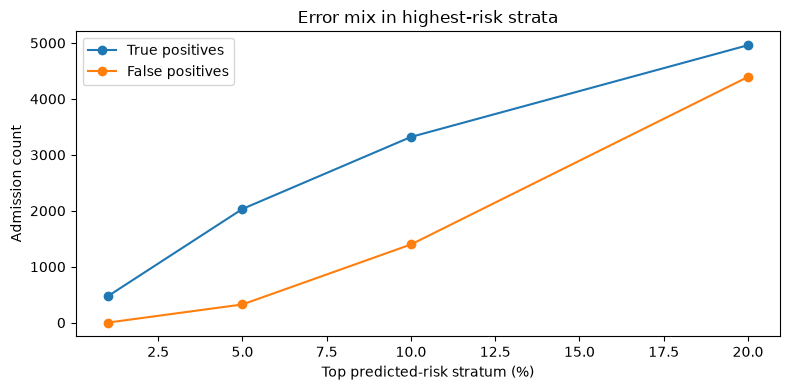

Outcome-window sensitivity:


,outcome_window_days,outcome_prevalence,precision,recall_sensitivity,specificity,f1_score,pr_auc_average_precision
0,14,0.167412,0.448733,0.531468,0.868717,0.486609,0.548453
1,30,0.197558,0.530311,0.532246,0.883943,0.531277,0.596463
2,33,0.207670,0.549663,0.524806,0.887304,0.536947,0.603390
3,36,0.215365,0.563349,0.518653,0.889657,0.540078,0.608569
4,45,0.235123,0.593713,0.500676,0.894678,0.543240,0.619412
5,60,0.262068,0.634235,0.479858,0.901721,0.546350,0.637319
6,90,0.301796,0.686945,0.451321,0.911098,0.544745,0.664524


False positives with later readmission:


,model_family,future_window,false_positives,future_readmission_count,future_readmission_percent_of_false_positives,mean_predicted_probability_for_future_readmitted_fp
0,Ensemble - LightGBM-heavy blend 50,31-33d,4393,181,4.120191,0.521060
1,Ensemble - LightGBM-heavy blend 50,31-45d,4393,593,13.498748,0.523280
2,Ensemble - LightGBM-heavy blend 50,31-60d,4393,972,22.126110,0.520189
3,Ensemble - LightGBM-heavy blend 50,31-90d,4393,1465,33.348509,0.517447
4,Ensemble - LightGBM-heavy blend 50,any_later_recorded,4393,2952,67.197815,0.502662


Borderline and high-confidence error summaries:


,model_family,selected_threshold,borderline_band,half_width,admissions,percent_of_test_set,observed_readmission_rate,false_positive_count,false_negative_count,error_count
0,Ensemble - LightGBM-heavy blend 50,0.36,0.33-0.39,0.03,2593,5.497021,0.261473,846,351,1197
1,Ensemble - LightGBM-heavy blend 50,0.36,0.31-0.41,0.05,4414,9.357444,0.270050,1302,643,1945
2,Ensemble - LightGBM-heavy blend 50,0.36,0.26-0.46,0.10,9362,19.846940,0.260628,2165,1414,3579


,error_type,classification_group,probability_rule,admissions,percent_of_all_errors,mean_days_to_next,median_days_to_next,near_cutoff_27_33d_count
0,high_confidence_false_positive_ge_0_70,false_positive,predicted_probability >= 0.7,421,4.810329,181.290909,62.0,22
1,very_high_confidence_false_positive_ge_0_80,false_positive,predicted_probability >= 0.8,129,1.473949,207.843750,65.0,6
2,high_confidence_false_negative_lt_0_20,false_negative,predicted_probability < 0.2,1897,21.675046,11.198735,9.0,125
3,very_low_confidence_false_negative_lt_0_10,false_negative,predicted_probability < 0.1,346,3.953382,10.170520,8.0,17


Risk strata error mix:


,model_family,top_percent,admissions_in_stratum,observed_readmission_rate,true_positive_count,false_positive_count,false_positive_31_90d_count,false_positive_31_90d_percent_of_fp,minimum_probability_in_stratum
0,Ensemble - LightGBM-heavy blend 50,1,472,0.997881,471,1,0,0.000000,0.961883
1,Ensemble - LightGBM-heavy blend 50,5,2359,0.861806,2033,326,131,40.184049,0.724220
2,Ensemble - LightGBM-heavy blend 50,10,4718,0.703688,3320,1398,545,38.984263,0.534762
3,Ensemble - LightGBM-heavy blend 50,20,9435,0.528882,4960,4393,1465,33.348509,0.358186


In [ ]:
#create compact error-anatomy summaries for the selected final model
error_anatomy_summary_df = pd.DataFrame()
readmission_timing_error_df = pd.DataFrame()
false_positive_future_readmission_df = pd.DataFrame()
false_negative_profile_df = pd.DataFrame()
prediction_probability_band_df = pd.DataFrame()
borderline_threshold_error_df = pd.DataFrame()
high_confidence_error_df = pd.DataFrame()
false_positive_context_df = pd.DataFrame()
risk_strata_error_mix_df = pd.DataFrame()
subgroup_error_burden_df = pd.DataFrame()
cohort_timing_path = project_path / "outputs" / "psychiatric_readmission_cohort.csv"

if all_prediction_df.empty or recommended_model_comparison_df.empty or not cohort_timing_path.exists():
    print("Error anatomy skipped because predictions, recommended model rows, or cohort timing data are unavailable.")
else:
    best_model_family = recommended_model_comparison_df.iloc[0]["model_family"]
    best_threshold = float(recommended_model_comparison_df.iloc[0]["threshold"])
    best_model_predictions = all_prediction_df.loc[all_prediction_df["model_family"] == best_model_family].copy()


    if not {"subject_id", "hadm_id"}.issubset(best_model_predictions.columns):
        print("Error anatomy skipped because prediction files do not contain subject_id and hadm_id.")
    else:
        cohort_timing_df = pd.read_csv(cohort_timing_path, usecols=["subject_id", "hadm_id", "days_to_next"])
        duplicate_timing_cols = [col for col in ["days_to_next"] if col in best_model_predictions.columns]
        error_prediction_base_df = best_model_predictions.drop(columns=duplicate_timing_cols)
        #join the derived features back to the admission table
        error_review_df = error_prediction_base_df.merge(cohort_timing_df, on=["subject_id", "hadm_id"], how="left")
        error_review_df["predicted_label"] = (error_review_df["predicted_probability"] >= best_threshold).astype(int)
        error_review_df["actual_label"] = error_review_df["readmitted_30d"].astype(int)
        error_review_df["classification_group"] = np.select([
            (error_review_df["actual_label"] == 1) & (error_review_df["predicted_label"] == 1),
            (error_review_df["actual_label"] == 0) & (error_review_df["predicted_label"] == 1),
            (error_review_df["actual_label"] == 1) & (error_review_df["predicted_label"] == 0),
            (error_review_df["actual_label"] == 0) & (error_review_df["predicted_label"] == 0)],
            ["true_positive", "false_positive", "false_negative", "true_negative"], default="unclassified")
        error_review_df["prediction_margin_from_threshold"] = (error_review_df["predicted_probability"] - best_threshold).abs()

        #different outcome windows show how sensitive performance is to near-miss readmissions after the official 30-day cutoff
        #the 30-day row uses the original modelling label; longer windows add official negatives readmitted just after day 30
        window_rows = []
        #loop through each item in this feature block
        for outcome_window_days in [14, 30, 33, 36, 45, 60, 90]:
            if outcome_window_days == 14:
                window_label = error_review_df["days_to_next"].between(0, 14, inclusive="both").fillna(False).astype(int)
            elif outcome_window_days == 30:
                window_label = error_review_df["actual_label"]
            else:
                window_label = ((error_review_df["actual_label"] == 1) |
                    ((error_review_df["actual_label"] == 0) &
                     error_review_df["days_to_next"].between(31, outcome_window_days, inclusive="both"))).astype(int)
            metrics = evaluate_probability_at_threshold(f"{best_model_family} {outcome_window_days}-day label",
                window_label, error_review_df["predicted_probability"], best_threshold)
            metrics["outcome_window_days"] = outcome_window_days
            metrics["outcome_prevalence"] = window_label.mean()
            window_rows.append(metrics)
        error_anatomy_summary_df = pd.DataFrame(window_rows)

        #readmission timing bins show whether caught/missed positives differ by timing
        timing_bins = [-0.001, 7, 14, 30, 33, 60, 90, np.inf]
        timing_labels = ["0-7d", "8-14d", "15-30d", "31-33d", "34-60d", "61-90d", "90d+"]
        error_review_df["next_admission_timing_band"] = pd.cut(error_review_df["days_to_next"],
            bins=timing_bins, labels=timing_labels)
        readmission_timing_error_df = error_review_df.loc[error_review_df["days_to_next"].notna()].groupby(
            ["next_admission_timing_band", "classification_group"], observed=True).agg(
            admissions=("hadm_id", "count"),
            mean_predicted_probability=("predicted_probability", "mean"),
            median_predicted_probability=("predicted_probability", "median")).reset_index()
        #summarise row-level records to admission-level features
        readmission_timing_total_df = readmission_timing_error_df.groupby("next_admission_timing_band", observed=True)["admissions"].transform("sum")
        readmission_timing_error_df["percent_within_timing_band"] = readmission_timing_error_df["admissions"] / readmission_timing_total_df * 100

        #false positives may still indicate future risk beyond the strict 30-day outcome
        fp_df = error_review_df.loc[error_review_df["classification_group"] == "false_positive"].copy()
        fp_rows = []
        for future_window_label, lower_day, upper_day in [("31-33d", 31, 33), ("31-45d", 31, 45),
            ("31-60d", 31, 60), ("31-90d", 31, 90), ("any_later_recorded", 31, np.inf)]:
            if np.isinf(upper_day):
                future_mask = fp_df["days_to_next"].ge(lower_day)
            else:
                future_mask = fp_df["days_to_next"].between(lower_day, upper_day, inclusive="both")
            fp_rows.append({"model_family": best_model_family,
                "future_window": future_window_label,
                "false_positives": len(fp_df),
                "future_readmission_count": int(future_mask.sum()),
                "future_readmission_percent_of_false_positives": future_mask.mean() * 100,
                "mean_predicted_probability_for_future_readmitted_fp": fp_df.loc[future_mask, "predicted_probability"].mean()})
        false_positive_future_readmission_df = pd.DataFrame(fp_rows)

        #probability bands show calibration and error composition without overwhelming the reader
        probability_bins = np.arange(0, 1.01, 0.10)
        probability_labels = [f"{probability_bins[i]:.1f}-{probability_bins[i+1]:.1f}" for i in range(len(probability_bins)-1)]
        error_review_df["predicted_probability_band"] = pd.cut(error_review_df["predicted_probability"],
            bins=probability_bins, labels=probability_labels, include_lowest=True)
        prediction_probability_band_df = error_review_df.groupby("predicted_probability_band", observed=True).agg(
            admissions=("hadm_id", "count"),
            observed_readmission_rate=("actual_label", "mean"),
            mean_predicted_probability=("predicted_probability", "mean"),
            true_positives=("classification_group", lambda x: (x == "true_positive").sum()),
            false_positives=("classification_group", lambda x: (x == "false_positive").sum()),
            false_negatives=("classification_group", lambda x: (x == "false_negative").sum()),
            true_negatives=("classification_group", lambda x: (x == "true_negative").sum())).reset_index()
        prediction_probability_band_df["error_count"] = prediction_probability_band_df["false_positives"] + prediction_probability_band_df["false_negatives"]
        prediction_probability_band_df["error_percent"] = prediction_probability_band_df["error_count"] / prediction_probability_band_df["admissions"] * 100

        #borderline cases around the selected threshold show uncertainty around the chosen cut point
        borderline_rows = []
        for half_width in [0.03, 0.05, 0.10]:
            lower_threshold = max(0, best_threshold - half_width)
            upper_threshold = min(1, best_threshold + half_width)
            borderline_df = error_review_df.loc[error_review_df["predicted_probability"].between(
                lower_threshold, upper_threshold, inclusive="both")].copy()
            borderline_rows.append({"model_family": best_model_family,
                "selected_threshold": best_threshold,
                "borderline_band": f"{lower_threshold:.2f}-{upper_threshold:.2f}",
                "half_width": half_width,
                "admissions": len(borderline_df),
                "percent_of_test_set": len(borderline_df) / len(error_review_df) * 100,
                "observed_readmission_rate": borderline_df["actual_label"].mean(),
                "false_positive_count": int((borderline_df["classification_group"] == "false_positive").sum()),
                "false_negative_count": int((borderline_df["classification_group"] == "false_negative").sum()),
                "error_count": int(borderline_df["classification_group"].isin(["false_positive", "false_negative"]).sum())})
        borderline_threshold_error_df = pd.DataFrame(borderline_rows)

        #high-confidence errors are the most clinically interesting mistakes
        high_confidence_rows = []
        high_confidence_definitions = [("high_confidence_false_positive_ge_0_70", "false_positive", ">=", 0.70),
            ("very_high_confidence_false_positive_ge_0_80", "false_positive", ">=", 0.80),
            ("high_confidence_false_negative_lt_0_20", "false_negative", "<", 0.20),
            ("very_low_confidence_false_negative_lt_0_10", "false_negative", "<", 0.10)]
        for error_label, classification_group, operator, probability_cutoff in high_confidence_definitions:
            if operator == ">=":
                subset_df = error_review_df.loc[(error_review_df["classification_group"] == classification_group) &
                    (error_review_df["predicted_probability"] >= probability_cutoff)].copy()
            else:
                subset_df = error_review_df.loc[(error_review_df["classification_group"] == classification_group) &
                    (error_review_df["predicted_probability"] < probability_cutoff)].copy()
            high_confidence_rows.append({"error_type": error_label,
                "classification_group": classification_group,
                "probability_rule": f"predicted_probability {operator} {probability_cutoff}",
                "admissions": len(subset_df),
                "percent_of_all_errors": len(subset_df) / error_review_df["classification_group"].isin(["false_positive", "false_negative"]).sum() * 100,
                "mean_days_to_next": subset_df["days_to_next"].mean(),
                "median_days_to_next": subset_df["days_to_next"].median(),
                "near_cutoff_27_33d_count": int(subset_df["days_to_next"].between(27, 33, inclusive="both").sum())})
        high_confidence_error_df = pd.DataFrame(high_confidence_rows)

        #risk strata error mix complements the high-risk strata analysis
        risk_rows = []
        for top_percent in [1, 5, 10, 20]:
            stratum_n = max(1, int(np.ceil(len(error_review_df) * top_percent / 100)))
            stratum_df = error_review_df.sort_values("predicted_probability", ascending=False).head(stratum_n).copy()
            risk_rows.append({"model_family": best_model_family,
                "top_percent": top_percent,
                "admissions_in_stratum": len(stratum_df),
                "observed_readmission_rate": stratum_df["actual_label"].mean(),
                "true_positive_count": int((stratum_df["classification_group"] == "true_positive").sum()),
                "false_positive_count": int((stratum_df["classification_group"] == "false_positive").sum()),
                "false_positive_31_90d_count": int(((stratum_df["classification_group"] == "false_positive") &
                    stratum_df["days_to_next"].between(31, 90, inclusive="both")).sum()),
                "false_positive_31_90d_percent_of_fp": (((stratum_df["classification_group"] == "false_positive") &
                    stratum_df["days_to_next"].between(31, 90, inclusive="both")).sum() /
                    max(1, (stratum_df["classification_group"] == "false_positive").sum()) * 100),
                "minimum_probability_in_stratum": stratum_df["predicted_probability"].min()})
        risk_strata_error_mix_df = pd.DataFrame(risk_rows)

        #use available engineered variables to compare false negatives with true positives
        profile_candidate_cols = ["subject_id", "hadm_id", "hospital_los_days", "anchor_age",
            "previous_psych_admissions_from_all_hosp", "previous_total_admissions",
            "days_since_previous_psych_admission", "recent_psych_admission_90d",
            "has_severe_mental_illness", "has_substance_use", "has_alcohol_related_disorder",
            "has_opioid_related_disorder", "has_stimulant_related_disorder", "discharged_against_advice",
            "discharged_to_psych_facility_flag", "had_icu_stay", "num_psych_med_classes",
            "num_unique_antipsychotics", "antipsychotic_polypharmacy_2plus", "emar_not_given_rate",
            "ed_length_of_stay_hours"]
        
        if wp2_3_dataset_path.exists():
            available_cols = pd.read_csv(wp2_3_dataset_path, nrows=0).columns.tolist()
            profile_cols = [col for col in profile_candidate_cols if col in available_cols]
            if {"subject_id", "hadm_id"}.issubset(profile_cols):
                profile_source_df = pd.read_csv(wp2_3_dataset_path, usecols=profile_cols)
                #join the derived features back to the admission table
                profile_review_df = error_review_df.merge(profile_source_df, on=["subject_id", "hadm_id"], how="left")
                profile_rows = []
                #loop through each item in this feature block
                for feature_col in [col for col in profile_cols if col not in ["subject_id", "hadm_id"]]:
                    #loop through each item in this feature block
                    for classification_group in ["true_positive", "false_negative", "false_positive", "true_negative"]:
                        group_df = profile_review_df.loc[profile_review_df["classification_group"] == classification_group]
                        profile_rows.append({"feature": feature_col,
                            "classification_group": classification_group,
                            "admissions": len(group_df),
                            "mean": pd.to_numeric(group_df[feature_col], errors="coerce").mean(),
                            "median": pd.to_numeric(group_df[feature_col], errors="coerce").median(),
                            "nonzero_or_true_percent": (pd.to_numeric(group_df[feature_col], errors="coerce").fillna(0) != 0).mean() * 100})
                false_negative_profile_df = pd.DataFrame(profile_rows)

                context_cols = [col for col in ["discharged_against_advice", "discharged_to_psych_facility_flag",
                    "had_icu_stay", "has_severe_mental_illness", "has_substance_use", "recent_psych_admission_90d"] if col in profile_review_df.columns]
                context_rows = []
                false_positive_profile_df = profile_review_df.loc[profile_review_df["classification_group"] == "false_positive"].copy()
                for context_col in context_cols:
                    context_rows.append({"context_feature": context_col,
                        "false_positives_with_feature_count": int((pd.to_numeric(false_positive_profile_df[context_col], errors="coerce").fillna(0) != 0).sum()),
                        "false_positives_with_feature_percent": (pd.to_numeric(false_positive_profile_df[context_col], errors="coerce").fillna(0) != 0).mean() * 100,
                        "mean_predicted_probability_with_feature": false_positive_profile_df.loc[
                            pd.to_numeric(false_positive_profile_df[context_col], errors="coerce").fillna(0) != 0,
                            "predicted_probability"].mean()})
                false_positive_context_df = pd.DataFrame(context_rows)

        #subgroup error burden makes class imbalance visible across patient groups
        if "subgroup_performance_df" in globals() and not subgroup_performance_df.empty:
            subgroup_error_burden_df = subgroup_performance_df.copy()
            subgroup_error_burden_df["false_positive_rate"] = subgroup_error_burden_df["false_positives"] / (
                subgroup_error_burden_df["false_positives"] + subgroup_error_burden_df["true_negatives"])
            subgroup_error_burden_df["false_negative_rate"] = subgroup_error_burden_df["false_negatives"] / (
                subgroup_error_burden_df["false_negatives"] + subgroup_error_burden_df["true_positives"])
            subgroup_error_burden_df["total_error_count"] = subgroup_error_burden_df["false_positives"] + subgroup_error_burden_df["false_negatives"]
            subgroup_error_burden_df["total_error_percent"] = subgroup_error_burden_df["total_error_count"] / subgroup_error_burden_df["admissions"] * 100
            subgroup_error_burden_df = subgroup_error_burden_df.sort_values(["total_error_percent", "admissions"], ascending=[False, False])

        #save detailed outputs
        output_tables = {"t3_6_error_anatomy_summary.csv": error_anatomy_summary_df,
            "t3_6_readmission_timing_error_mix.csv": readmission_timing_error_df,
            "t3_6_false_positive_future_readmission.csv": false_positive_future_readmission_df,
            "t3_6_false_negative_profile_comparison.csv": false_negative_profile_df,
            "t3_6_prediction_probability_band_errors.csv": prediction_probability_band_df,
            "t3_6_borderline_threshold_error_analysis.csv": borderline_threshold_error_df,
            "t3_6_high_confidence_error_analysis.csv": high_confidence_error_df,
            "t3_6_false_positive_context_summary.csv": false_positive_context_df,
            "t3_6_risk_strata_error_mix.csv": risk_strata_error_mix_df,
            "t3_6_subgroup_error_burden.csv": subgroup_error_burden_df}
        for output_file, output_df in output_tables.items():
            #save this table or artefact for later review
            output_df.to_csv(wp3_6_csv_output_path / output_file, index=False)

        #make compact plots for appendix
        if not false_positive_future_readmission_df.empty:
            plt.figure(figsize=(8, 4))
            plt.bar(false_positive_future_readmission_df["future_window"],
                false_positive_future_readmission_df["future_readmission_percent_of_false_positives"], color="steelblue")
            plt.ylabel("% of false positives")
            plt.title("False positives with later psychiatric readmission")
            plt.tight_layout()
            plt.savefig(wp3_6_image_output_path / "t3_6_false_positive_future_readmission.png", dpi=300)
            plt.show()

        if not prediction_probability_band_df.empty:
            plt.figure(figsize=(9, 4))
            plt.plot(prediction_probability_band_df["predicted_probability_band"].astype(str),
                prediction_probability_band_df["observed_readmission_rate"], marker="o", label="Observed readmission")
            plt.plot(prediction_probability_band_df["predicted_probability_band"].astype(str),
                prediction_probability_band_df["mean_predicted_probability"], marker="o", label="Mean predicted probability")
            plt.xticks(rotation=45, ha="right")
            plt.ylabel("Rate / probability")
            plt.title("Observed readmission by prediction band")
            plt.legend()
            plt.tight_layout()
            plt.savefig(wp3_6_image_output_path / "t3_6_prediction_probability_band_errors.png", dpi=300)
            plt.show()

        if not risk_strata_error_mix_df.empty:
            plt.figure(figsize=(8, 4))
            plt.plot(risk_strata_error_mix_df["top_percent"], risk_strata_error_mix_df["true_positive_count"], marker="o", label="True positives")
            plt.plot(risk_strata_error_mix_df["top_percent"], risk_strata_error_mix_df["false_positive_count"], marker="o", label="False positives")
            plt.xlabel("Top predicted-risk stratum (%)")
            plt.ylabel("Admission count")
            plt.title("Error mix in highest-risk strata")
            plt.legend()
            plt.tight_layout()
            plt.savefig(wp3_6_image_output_path / "t3_6_risk_strata_error_mix.png", dpi=300)
            plt.show()

        print("Outcome-window sensitivity:")
        display(error_anatomy_summary_df[["outcome_window_days", "outcome_prevalence", "precision",
            "recall_sensitivity", "specificity", "f1_score", "pr_auc_average_precision"]])
        print("False positives with later readmission:")
        display(false_positive_future_readmission_df)
        print("Borderline and high-confidence error summaries:")
        display(borderline_threshold_error_df)
        display(high_confidence_error_df)
        print("Risk strata error mix:")
        display(risk_strata_error_mix_df)

**Non-psychiatric marker subgroup sensitivity**

The main outcome remains psychiatric readmission. This check asks how the selected model behaves in admissions with fewer obvious psychiatric markers, such as no severe mental illness, psychosis, self-harm, substance-use flags, or prior psychiatric admissions.




In [ ]:
#evaluate the selected model in admissions with fewer obvious psychiatric markers
non_psychiatric_subgroup_df = pd.DataFrame()

if all_prediction_df.empty or recommended_model_comparison_df.empty or not wp2_3_dataset_path.exists():
    print("Non-psychiatric subgroup check skipped because predictions, recommended rows, or the engineered dataset are unavailable.")
else:
    best_model_family = recommended_model_comparison_df.iloc[0]["model_family"]
    best_threshold = float(recommended_model_comparison_df.iloc[0]["threshold"])
    best_predictions = all_prediction_df.loc[all_prediction_df["model_family"] == best_model_family].copy()
    available_cols = pd.read_csv(wp2_3_dataset_path, nrows=0).columns.tolist()
    marker_candidates = ["has_severe_mental_illness", "has_self_harm_or_suicidal_ideation",
        "has_substance_use", "has_alcohol_related_disorder", "has_opioid_related_disorder",
        "has_stimulant_related_disorder", "elixhauser_psychoses", "previous_psych_admissions_365d",
        "previous_psych_admissions_90d", "previous_psych_admissions_from_all_hosp",
        "discharged_to_psych_facility_flag"]
    marker_cols = [col for col in marker_candidates if col in available_cols]
    use_cols = ["subject_id", "hadm_id"] + marker_cols

    if {"subject_id", "hadm_id"}.issubset(best_predictions.columns) and marker_cols:
        psych_marker_df = pd.read_csv(wp2_3_dataset_path, usecols=use_cols)
        subgroup_df = best_predictions.merge(psych_marker_df, on=["subject_id", "hadm_id"], how="left")
        marker_matrix = subgroup_df[marker_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
        subgroup_df["no_obvious_psychiatric_marker_flag"] = (marker_matrix.sum(axis=1) == 0).astype(int)
        subgroup_df["any_obvious_psychiatric_marker_flag"] = (marker_matrix.sum(axis=1) > 0).astype(int)

        rows = []
        for subgroup_label, group_df in [("no_obvious_psychiatric_marker", subgroup_df.loc[subgroup_df["no_obvious_psychiatric_marker_flag"] == 1]),
            ("any_obvious_psychiatric_marker", subgroup_df.loc[subgroup_df["any_obvious_psychiatric_marker_flag"] == 1])]:
            if len(group_df) < 200 or group_df["readmitted_30d"].nunique() < 2:
                continue
            metrics = evaluate_probability_at_threshold(best_model_family, group_df["readmitted_30d"],
                group_df["predicted_probability"], best_threshold)
            metrics.update({"subgroup_definition": subgroup_label,
                "admissions": len(group_df),
                "readmission_rate": group_df["readmitted_30d"].mean(),
                "psych_marker_columns_used": ", ".join(marker_cols)})
            rows.append(metrics)
        non_psychiatric_subgroup_df = pd.DataFrame(rows)
        non_psychiatric_subgroup_df.to_csv(wp3_6_csv_output_path / "t3_6_non_psychiatric_subgroup_sensitivity.csv", index=False)
        print("Non-psychiatric subgroup sensitivity:")
        display(non_psychiatric_subgroup_df)
    else:
        print("Non-psychiatric subgroup check skipped because ID columns or psychiatric marker columns are unavailable.")

Non-psychiatric subgroup sensitivity:


,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc_average_precision,brier_score,true_negatives,false_positives,false_negatives,true_positives,subgroup_definition,admissions,readmission_rate,psych_marker_columns_used
0,Ensemble - LightGBM-heavy blend 50,0.36,0.893909,0.557509,0.462783,0.132900,0.982118,0.206498,0.719391,0.288577,0.086468,9117,166,933,143,no_obvious_psychiatric_marker,10359,0.103871,"has_severe_mental_illness, has_self_harm_or_su..."
1,Ensemble - LightGBM-heavy blend 50,0.36,0.792106,0.718209,0.532618,0.584375,0.852042,0.557297,0.804321,0.629612,0.130518,24342,4227,3426,4817,any_obvious_psychiatric_marker,36812,0.223922,"has_severe_mental_illness, has_self_harm_or_su..."


### **3.6.7 Cluster-Based Patient Profile Analysis**

This section groups admissions using broad, interpretable feature families rather than raw patient identifiers. The purpose is not to build a new predictive model, but to describe whether the final model performs differently across latent patient profiles.

The workflow is:

1. Build a compact family-level matrix from available engineered predictors.
2. Standardise the family scores.
3. Compare K-Means solutions across candidate cluster counts using silhouette score.
4. Profile each cluster by readmission prevalence, predicted risk, model errors, and the feature families that define it.
5. Save a two-dimensional PCA plot for a stable visual summary.

This helps answer a clinically useful question: which patient profiles are being ranked well, and which profiles remain difficult for the model?

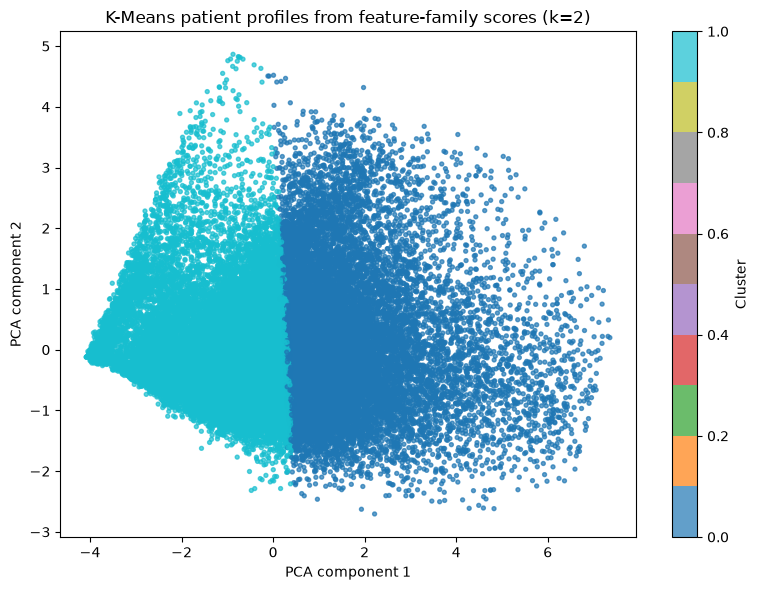

Selected cluster count: 2
Minimum cluster size required: 944
Cluster selection table:


,k,silhouette_score,minimum_cluster_size,maximum_cluster_size,passes_minimum_cluster_size
0,2,0.2817,18387,28784,True
1,3,0.2431,9154,27995,True
2,4,0.2346,5748,23761,True
3,5,0.2212,3261,19063,True
5,7,0.1818,2144,12763,True
6,8,0.1804,1776,11976,True
4,6,0.1753,2606,13236,True


Cluster performance profiles:


,model_family,cluster_label,admissions,readmission_rate,mean_predicted_probability,roc_auc,pr_auc_average_precision,precision,recall_sensitivity,specificity,selected_threshold,mean_prior_utilisation,mean_psychiatric_history,mean_order_activity,mean_medication_emar,mean_medical_complexity,mean_lab_vital_burden,mean_ed_admission_pathway,mean_discharge_social
0,Ensemble - LightGBM-heavy blend 50,0,18387,0.2219,0.2782,0.7715,0.5342,0.4762,0.5392,0.8309,0.36,0.0963,0.1317,0.1796,0.3153,0.1968,0.1102,0.1783,0.1534
1,Ensemble - LightGBM-heavy blend 50,1,28784,0.1820,0.2328,0.8128,0.6298,0.5831,0.5268,0.9162,0.36,-0.0731,-0.0621,-0.1171,-0.1960,-0.1343,-0.0743,-0.0630,-0.0298


In [ ]:
#cluster-based patient profile analysis using family-level features
#this uses broad feature-family scores rather than raw identifiers. the aim is to identify patient profiles where final model performs better or worse.
cluster_selection_df = pd.DataFrame()
cluster_profile_df = pd.DataFrame()
cluster_feature_family_map_df = pd.DataFrame()
cluster_family_centres_df = pd.DataFrame()
cluster_pca_df = pd.DataFrame()

family_source_definitions = {
    "prior_utilisation": ["previous_", "days_since_previous", "frequent_psych", "prior_", "admissions_per_"],
    "psychiatric_history": ["psych", "self_harm", "smi", "severe_mental", "substance", "depression", "psychosis"],
    "order_activity": ["poe", "order", "late_", "followup", "aftercare", "discharge_planning", "safety"],
    "medication_emar": ["pharmacy", "emar", "psychotropic", "antipsychotic", "benzodiazepine", "mood_stabiliser", "medication"],
    "medical_complexity": ["charlson", "elixhauser", "comorbidity", "icu", "procedure", "infection", "micro", "culture"],
    "lab_vital_burden": ["lab", "vital", "spo2", "heart_rate", "bp", "wbc", "sodium", "potassium", "glucose", "hemoglobin", "platelet"],
    "ed_admission_pathway": ["ed_", "emergency", "transfer", "service", "careunit", "admitted_from"],
    "discharge_social": ["discharge", "home", "facility", "insurance", "language", "marital", "race", "gender"]}

#choose predictions from the selected final model when possible.
cluster_prediction_df = pd.DataFrame()
cluster_model_family = None
if not all_prediction_df.empty and not recommended_model_comparison_df.empty:
    cluster_model_family = recommended_model_comparison_df.iloc[0]["model_family"]
    cluster_prediction_df = all_prediction_df.loc[all_prediction_df["model_family"] == cluster_model_family].copy()
elif not all_prediction_df.empty:
    cluster_model_family = all_prediction_df["model_family"].dropna().iloc[0]
    cluster_prediction_df = all_prediction_df.loc[all_prediction_df["model_family"] == cluster_model_family].copy()

#build the feature-family matrix from the saved reduced test matrix.
#the row order is kept as saved. do not sort predictions independently from the matrix, or clusters will be misaligned.
family_matrix = pd.DataFrame()
family_feature_map = []
reduced_matrix_path = wp3_1_output_path / f"t3_1_X_test_processed_{wp3_input_variant}.npz"
reduced_feature_path = wp3_1_output_path / f"t3_1_processed_feature_names_{wp3_input_variant}.csv"
if not reduced_feature_path.exists():
    reduced_feature_path = wp3_1_output_path / "t3_1_processed_feature_names.csv"
if reduced_matrix_path.exists() and reduced_feature_path.exists():
    X_test_cluster = sparse.load_npz(reduced_matrix_path).tocsr()
    feature_name_df = pd.read_csv(reduced_feature_path)
    feature_name_column = "processed_feature_name" if "processed_feature_name" in feature_name_df.columns else feature_name_df.columns[0]
    available_feature_names = feature_name_df[feature_name_column].astype(str).tolist()
    family_matrix = pd.DataFrame(index=np.arange(X_test_cluster.shape[0]))
    #loop through each item in this feature block
    for family_name, patterns in family_source_definitions.items():
        matching_indices = [feature_index for feature_index, feature_name in enumerate(available_feature_names)
            if any(pattern.lower() in feature_name.lower() for pattern in patterns)]
        if matching_indices:
            family_matrix[family_name] = np.asarray(X_test_cluster[:, matching_indices].mean(axis=1)).ravel()
            family_feature_map.append({"feature_family": family_name, "source_feature_count": len(matching_indices)})
else:
    print("Cluster matrix files were not available:", reduced_matrix_path, reduced_feature_path)

if cluster_prediction_df.empty:
    print("Cluster analysis skipped because no prediction table was available.")
elif family_matrix.shape[1] < 2:
    print("Cluster analysis skipped because fewer than two feature-family scores were available.")
else:
    #keep row order aligned with the saved prediction file and x_test matrix.
    cluster_prediction_df = cluster_prediction_df.reset_index(drop=True)
    family_matrix = family_matrix.reset_index(drop=True)
    n_rows = min(len(cluster_prediction_df), len(family_matrix))
    cluster_prediction_df = cluster_prediction_df.iloc[:n_rows].copy()
    family_matrix = family_matrix.iloc[:n_rows].copy()

    #family averages can contain extreme standardised values. winsorise family scores before clustering so
    #one unusual admission cannot become its own cluster.
    family_matrix_winsorised = family_matrix.apply(pd.to_numeric, errors="coerce").fillna(0).copy()
    for family_col in family_matrix_winsorised.columns:
        lower_bound = family_matrix_winsorised[family_col].quantile(0.01)
        upper_bound = family_matrix_winsorised[family_col].quantile(0.99)
        family_matrix_winsorised[family_col] = family_matrix_winsorised[family_col].clip(lower_bound, upper_bound)

    scaler = RobustScaler()
    family_scaled = scaler.fit_transform(family_matrix_winsorised)

    minimum_cluster_size = max(500, int(np.ceil(0.02 * len(family_matrix_winsorised))))
    cluster_rows = []
    for k_value in range(2, 9):
        kmeans_model = KMeans(n_clusters=k_value, random_state=42, n_init=20)
        cluster_labels = kmeans_model.fit_predict(family_scaled)
        cluster_counts = pd.Series(cluster_labels).value_counts()
        silhouette = silhouette_score(family_scaled, cluster_labels) if len(set(cluster_labels)) > 1 else np.nan
        cluster_rows.append({"k": k_value,
            "silhouette_score": silhouette,
            "minimum_cluster_size": int(cluster_counts.min()),
            "maximum_cluster_size": int(cluster_counts.max()),
            "passes_minimum_cluster_size": bool(cluster_counts.min() >= minimum_cluster_size)})

    cluster_selection_df = pd.DataFrame(cluster_rows).sort_values(
        ["passes_minimum_cluster_size", "silhouette_score"], ascending=[False, False])
    selected_k = int(cluster_selection_df.iloc[0]["k"])
    final_kmeans_model = KMeans(n_clusters=selected_k, random_state=42, n_init=50)
    final_cluster_labels = final_kmeans_model.fit_predict(family_scaled)

    cluster_case_df = cluster_prediction_df.copy()
    cluster_case_df["cluster_label"] = final_cluster_labels
    for family_col in family_matrix.columns:
        cluster_case_df[family_col] = family_matrix_winsorised[family_col].to_numpy()

    #always recompute labels from the selected wp3.6 threshold. saved predicted_class columns may reflect a different threshold.
    selected_threshold = float(recommended_model_comparison_df.iloc[0]["threshold"]) if not recommended_model_comparison_df.empty else 0.5
    cluster_case_df["cluster_predicted_label"] = (cluster_case_df["predicted_probability"] >= selected_threshold).astype(int)

    cluster_profile_rows = []
    for cluster_label, cluster_df in cluster_case_df.groupby("cluster_label"):
        predicted_label = cluster_df["cluster_predicted_label"]
        y_true = cluster_df["readmitted_30d"].astype(int)
        cluster_profile_rows.append({"model_family": cluster_model_family,
            "cluster_label": cluster_label,
            "admissions": len(cluster_df),
            "readmission_rate": y_true.mean(),
            "mean_predicted_probability": cluster_df["predicted_probability"].mean(),
            "roc_auc": roc_auc_score(y_true, cluster_df["predicted_probability"]) if y_true.nunique() > 1 else np.nan,
            "pr_auc_average_precision": average_precision_score(y_true, cluster_df["predicted_probability"]) if y_true.nunique() > 1 else np.nan,
            "precision": precision_score(y_true, predicted_label, zero_division=0),
            "recall_sensitivity": recall_score(y_true, predicted_label, zero_division=0),
            "specificity": recall_score(1 - y_true, 1 - predicted_label, zero_division=0),
            "selected_threshold": selected_threshold,
            **{f"mean_{family_col}": cluster_df[family_col].mean() for family_col in family_matrix.columns}})

    cluster_profile_df = pd.DataFrame(cluster_profile_rows).sort_values("readmission_rate", ascending=False)
    cluster_feature_family_map_df = pd.DataFrame(family_feature_map).sort_values("source_feature_count", ascending=False)
    cluster_family_centres_df = pd.DataFrame(final_kmeans_model.cluster_centers_, columns=family_matrix.columns)
    cluster_family_centres_df.insert(0, "cluster_label", range(selected_k))

    pca_model = PCA(n_components=2, random_state=42)
    pca_coordinates = pca_model.fit_transform(family_scaled)
    cluster_pca_df = cluster_case_df[[col for col in ["subject_id", "hadm_id", "readmitted_30d", "predicted_probability", "cluster_label"] if col in cluster_case_df.columns]].copy()
    cluster_pca_df["pca_component_1"] = pca_coordinates[:, 0]
    cluster_pca_df["pca_component_2"] = pca_coordinates[:, 1]

    #save this table or artefact for later review
    cluster_selection_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_k_selection.csv", index=False)
    cluster_profile_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_performance_profiles.csv", index=False)
    cluster_feature_family_map_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_feature_family_map.csv", index=False)
    cluster_family_centres_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_family_centres.csv", index=False)
    cluster_pca_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_pca_coordinates.csv", index=False)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(cluster_pca_df["pca_component_1"], cluster_pca_df["pca_component_2"],
        c=cluster_pca_df["cluster_label"], cmap="tab10", s=8, alpha=0.7)
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.title(f"K-Means patient profiles from feature-family scores (k={selected_k})")
    plt.colorbar(scatter, label="Cluster")
    plt.tight_layout()
    plt.savefig(wp3_6_image_output_path / "t3_6_cluster_pca_profile_plot.png", dpi=300)
    plt.show()

    print("Selected cluster count:", selected_k)
    print("Minimum cluster size required:", minimum_cluster_size)
    print("Cluster selection table:")
    display(cluster_selection_df.round(4))
    print("Cluster performance profiles:")
    display(cluster_profile_df.round(4))

### **Fixed-K Cluster Sensitivity Profiles**

The default clustering cell selects the number of clusters using silhouette score, which favours the cleanest statistical separation. In this dataset that often produces a two-cluster split: higher overall care complexity versus lower overall care complexity.

This sensitivity section deliberately repeats the profile analysis for fixed cluster counts. The aim is descriptive rather than predictive: check whether 3-, 4-, or 5-cluster solutions reveal clinically clearer subgroups, such as psychiatric-history-heavy, medical-complexity-heavy, late-order/discharge-complexity-heavy, or quieter lower-complexity admissions.




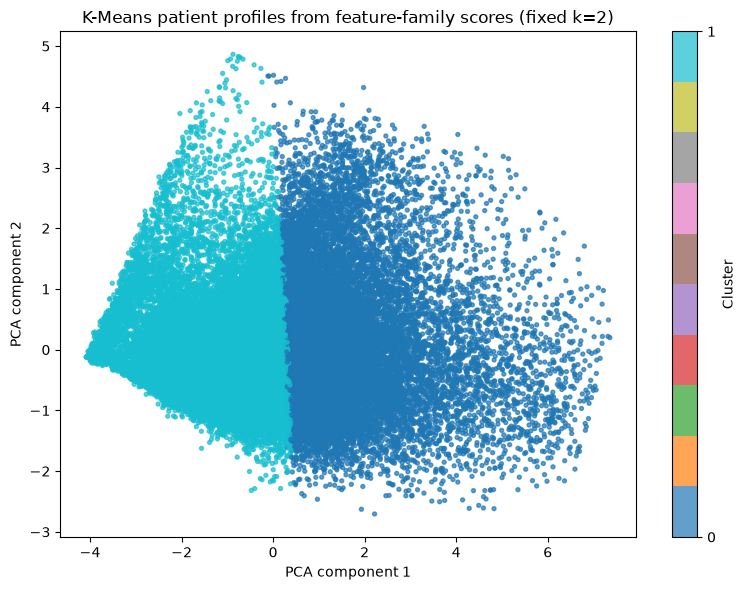

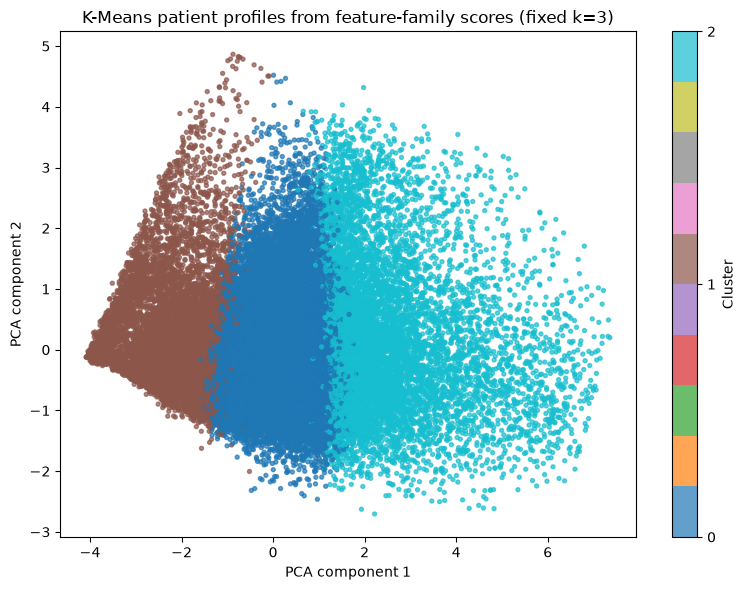

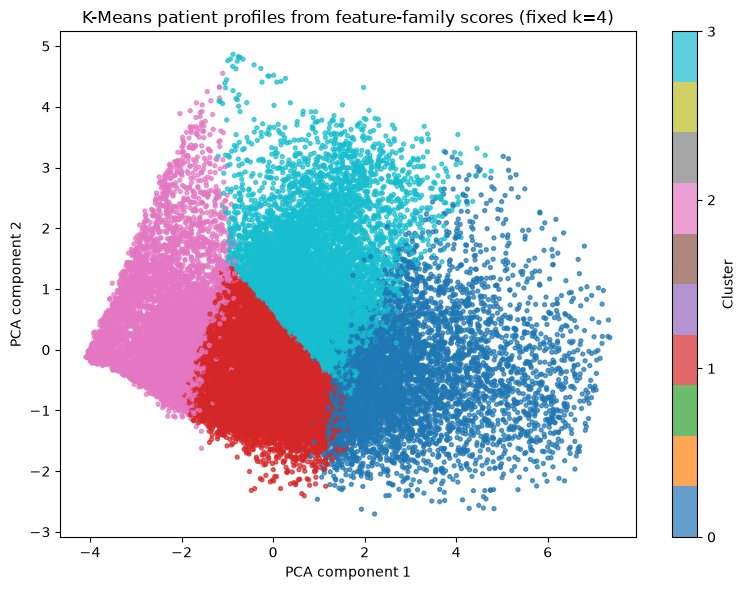

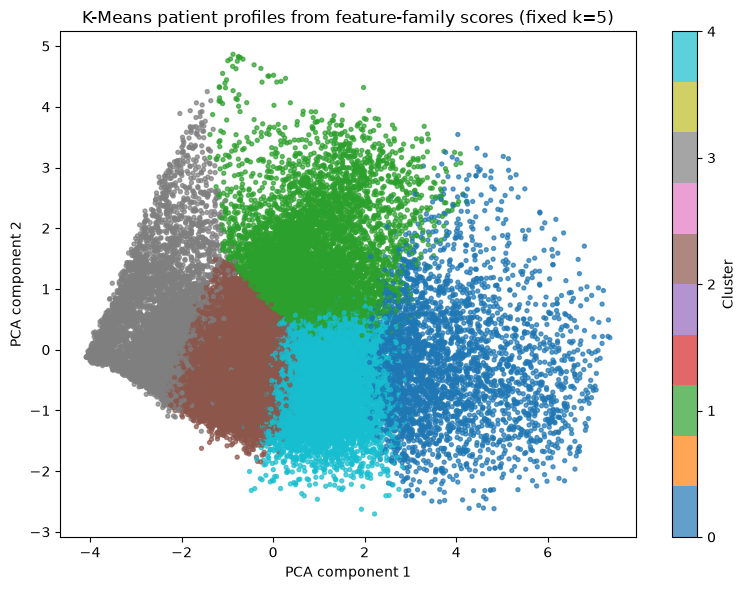

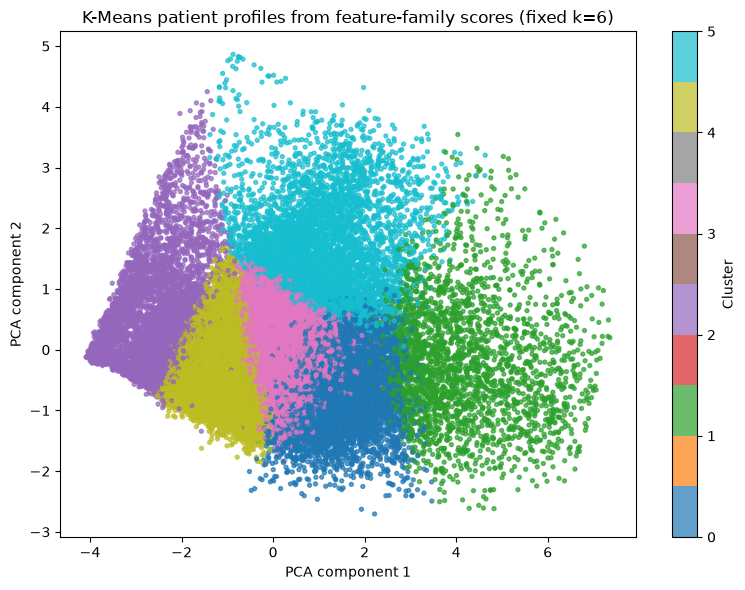

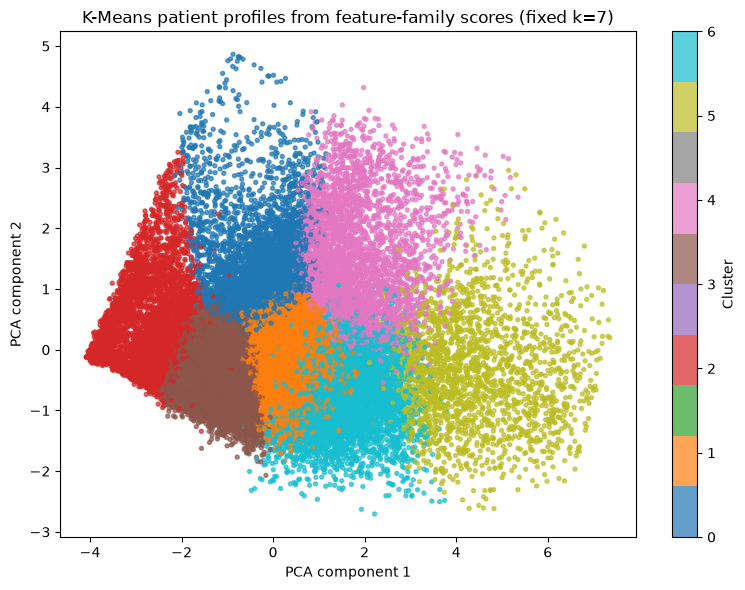

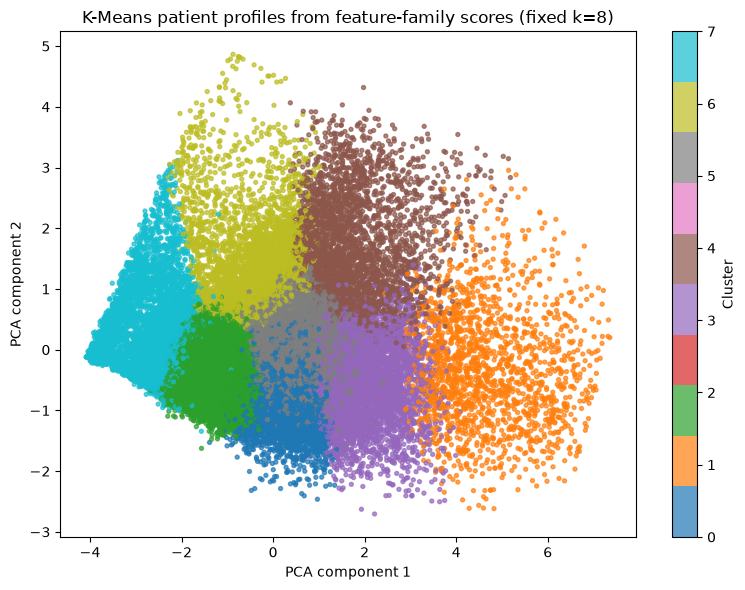

Fixed-k cluster selection summary:


,k,silhouette_score,minimum_cluster_size,maximum_cluster_size,passes_minimum_cluster_size,interpretation_note
0,2,0.2817,18387,28784,True,Higher silhouette means cleaner separation; lo...
1,3,0.2431,9154,27995,True,Higher silhouette means cleaner separation; lo...
2,4,0.2346,5748,23761,True,Higher silhouette means cleaner separation; lo...
3,5,0.2213,3260,19067,True,Higher silhouette means cleaner separation; lo...
4,6,0.1753,2606,13236,True,Higher silhouette means cleaner separation; lo...
5,7,0.1815,2164,12680,True,Higher silhouette means cleaner separation; lo...
6,8,0.1804,1772,11979,True,Higher silhouette means cleaner separation; lo...


Fixed-k cluster performance profiles:


,solution_k,model_family,cluster_label,admissions,readmission_rate,mean_predicted_probability,roc_auc,pr_auc_average_precision,precision,recall_sensitivity,specificity,selected_threshold,mean_prior_utilisation,mean_psychiatric_history,mean_order_activity,mean_medication_emar,mean_medical_complexity,mean_lab_vital_burden,mean_ed_admission_pathway,mean_discharge_social
0,2,Ensemble - LightGBM-heavy blend 50,0,18387,0.2219,0.2782,0.7715,0.5342,0.4762,0.5392,0.8309,0.36,0.0963,0.1317,0.1796,0.3153,0.1968,0.1102,0.1783,0.1534
1,2,Ensemble - LightGBM-heavy blend 50,1,28784,0.1820,0.2328,0.8128,0.6298,0.5831,0.5268,0.9162,0.36,-0.0731,-0.0621,-0.1171,-0.1960,-0.1343,-0.0743,-0.0630,-0.0298
3,3,Ensemble - LightGBM-heavy blend 50,1,10022,0.2533,0.2988,0.8948,0.8155,0.6717,0.7727,0.8718,0.36,-0.0915,-0.0843,-0.2764,-0.3635,-0.2333,-0.1208,-0.1184,-0.1935
4,3,Ensemble - LightGBM-heavy blend 50,2,9154,0.2309,0.2821,0.7841,0.5523,0.4822,0.5714,0.8158,0.36,0.1135,0.1942,0.2738,0.5325,0.3261,0.1987,0.2745,0.1755
2,3,Ensemble - LightGBM-heavy blend 50,0,27995,0.1667,0.2229,0.7457,0.4494,0.4558,0.3836,0.9084,0.36,-0.0162,-0.0107,0.0070,-0.0384,-0.0320,-0.0258,0.0050,0.0820
8,4,Ensemble - LightGBM-heavy blend 50,3,9699,0.2946,0.3601,0.7944,0.6602,0.5130,0.7158,0.7163,0.36,0.2571,0.2478,0.0909,0.1834,-0.0274,-0.0610,0.1442,0.1126
7,4,Ensemble - LightGBM-heavy blend 50,2,7963,0.2841,0.3326,0.9030,0.8377,0.6657,0.8134,0.8379,0.36,-0.0749,-0.0768,-0.3095,-0.3957,-0.2446,-0.1304,-0.1231,-0.2313
5,4,Ensemble - LightGBM-heavy blend 50,0,5748,0.1874,0.2300,0.7680,0.4445,0.4383,0.4225,0.8752,0.36,0.0079,0.1223,0.3365,0.5987,0.4888,0.3240,0.3031,0.1856
6,4,Ensemble - LightGBM-heavy blend 50,1,23761,0.1314,0.1832,0.7040,0.3066,0.3962,0.1985,0.9542,0.36,-0.0957,-0.0783,-0.0177,-0.0805,-0.0355,-0.0145,-0.0292,0.0692
10,5,Ensemble - LightGBM-heavy blend 50,1,6777,0.3267,0.3904,0.8190,0.7219,0.5486,0.7823,0.6877,0.36,0.3084,0.3239,0.0727,0.1650,-0.0894,-0.0968,0.1508,0.0924


Fixed-k cluster interpretation guide:


,solution_k,cluster_label,top_high_family_1,top_high_family_1_score,top_high_family_2,top_high_family_2_score,top_high_family_3,top_high_family_3_score,top_low_family_1,top_low_family_1_score,top_low_family_2,top_low_family_2_score,top_low_family_3,top_low_family_3_score
0,2,0,ed_admission_pathway,0.8422,medication_emar,0.8162,lab_vital_burden,0.7475,prior_utilisation,0.2757,discharge_social,0.5393,medical_complexity,0.6657
1,2,1,lab_vital_burden,-0.0666,prior_utilisation,-0.0858,psychiatric_history,-0.1201,discharge_social,-0.5554,order_activity,-0.4264,medication_emar,-0.3233
2,3,0,lab_vital_burden,0.1470,medical_complexity,0.1145,discharge_social,0.1128,ed_admission_pathway,0.0202,medication_emar,0.0283,prior_utilisation,0.0362
3,3,1,prior_utilisation,-0.1253,psychiatric_history,-0.2150,lab_vital_burden,-0.2721,discharge_social,-1.5321,order_activity,-1.0544,medication_emar,-0.6962
4,3,2,medication_emar,1.3002,ed_admission_pathway,1.2982,lab_vital_burden,1.1415,prior_utilisation,0.3110,discharge_social,0.6716,psychiatric_history,0.9686
5,4,0,lab_vital_burden,1.6928,medication_emar,1.4481,ed_admission_pathway,1.4342,prior_utilisation,0.0867,psychiatric_history,0.6639,discharge_social,0.7315
6,4,1,lab_vital_burden,0.1973,medical_complexity,0.1067,discharge_social,0.0373,psychiatric_history,-0.1879,ed_admission_pathway,-0.1422,prior_utilisation,-0.1330
7,4,2,prior_utilisation,-0.0892,psychiatric_history,-0.1821,lab_vital_burden,-0.3146,discharge_social,-1.7578,order_activity,-1.1844,medication_emar,-0.7682
8,4,3,psychiatric_history,1.2016,ed_admission_pathway,0.6814,prior_utilisation,0.6179,lab_vital_burden,-0.0087,medical_complexity,0.1251,discharge_social,0.2958
9,5,0,medication_emar,2.0030,ed_admission_pathway,1.9323,lab_vital_burden,1.8235,prior_utilisation,0.1270,discharge_social,0.8774,psychiatric_history,1.0101


In [ ]:
#the main clustering result is still selected by silhouette score. this cell additionally profiles
#clinically useful alternatives so the write-up can decide whether a slightly less separated solution; offers clearer patient subgroups.
cluster_fixed_k_selection_df = pd.DataFrame()
cluster_fixed_k_profile_df = pd.DataFrame()
cluster_fixed_k_family_centres_df = pd.DataFrame()
cluster_fixed_k_interpretation_df = pd.DataFrame()
cluster_fixed_k_pca_df = pd.DataFrame()

fixed_cluster_k_values = [2, 3, 4, 5, 6, 7, 8]

required_cluster_objects = ["family_scaled", "family_matrix_winsorised", "cluster_prediction_df"]
missing_cluster_objects = [name for name in required_cluster_objects if name not in globals()]
if missing_cluster_objects:
    print("Fixed-k clustering skipped because the main clustering cell has not created:", missing_cluster_objects)
elif cluster_prediction_df.empty or family_matrix_winsorised.empty:
    print("Fixed-k clustering skipped because the clustering inputs are empty.")
else:
    fixed_cluster_prediction_df = cluster_prediction_df.reset_index(drop=True).copy()
    fixed_family_matrix_df = family_matrix_winsorised.reset_index(drop=True).copy()
    n_rows = min(len(fixed_cluster_prediction_df), len(fixed_family_matrix_df), family_scaled.shape[0])
    fixed_cluster_prediction_df = fixed_cluster_prediction_df.iloc[:n_rows].copy()
    fixed_family_matrix_df = fixed_family_matrix_df.iloc[:n_rows].copy()
    fixed_family_scaled = family_scaled[:n_rows]

    fixed_selected_threshold = float(recommended_model_comparison_df.iloc[0]["threshold"]) if not recommended_model_comparison_df.empty else 0.5
    fixed_cluster_prediction_df["cluster_predicted_label"] = (
        fixed_cluster_prediction_df["predicted_probability"] >= fixed_selected_threshold).astype(int)

    #a shared pca projection keeps the plots comparable across k values.
    fixed_pca_model = PCA(n_components=2, random_state=42)
    fixed_pca_coordinates = fixed_pca_model.fit_transform(fixed_family_scaled)

    fixed_selection_rows = []
    fixed_profile_rows = []
    fixed_centre_rows = []
    fixed_interpretation_rows = []
    fixed_pca_rows = []

    #loop through each item in this feature block
    for k_value in fixed_cluster_k_values:
        kmeans_model = KMeans(n_clusters=k_value, random_state=42, n_init=50)
        cluster_labels = kmeans_model.fit_predict(fixed_family_scaled)
        cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
        silhouette = silhouette_score(fixed_family_scaled, cluster_labels) if len(set(cluster_labels)) > 1 else np.nan

        fixed_selection_rows.append({"k": k_value,
            "silhouette_score": silhouette,
            "minimum_cluster_size": int(cluster_counts.min()),
            "maximum_cluster_size": int(cluster_counts.max()),
            "passes_minimum_cluster_size": bool(cluster_counts.min() >= minimum_cluster_size) if "minimum_cluster_size" in globals() else np.nan,
            "interpretation_note": "Higher silhouette means cleaner separation; lower silhouette may still be clinically useful."})

        solution_case_df = fixed_cluster_prediction_df.copy()
        solution_case_df["solution_k"] = k_value
        solution_case_df["cluster_label"] = cluster_labels
        #loop through each item in this feature block
        for family_col in fixed_family_matrix_df.columns:
            solution_case_df[family_col] = fixed_family_matrix_df[family_col].to_numpy()

        for cluster_label, cluster_df in solution_case_df.groupby("cluster_label"):
            y_true = cluster_df["readmitted_30d"].astype(int)
            predicted_label = cluster_df["cluster_predicted_label"]
            family_means = {f"mean_{family_col}": cluster_df[family_col].mean() for family_col in fixed_family_matrix_df.columns}
            fixed_profile_rows.append({"solution_k": k_value,
                "model_family": cluster_model_family,
                "cluster_label": int(cluster_label),
                "admissions": len(cluster_df),
                "readmission_rate": y_true.mean(),
                "mean_predicted_probability": cluster_df["predicted_probability"].mean(),
                "roc_auc": roc_auc_score(y_true, cluster_df["predicted_probability"]) if y_true.nunique() > 1 else np.nan,
                "pr_auc_average_precision": average_precision_score(y_true, cluster_df["predicted_probability"]) if y_true.nunique() > 1 else np.nan,
                "precision": precision_score(y_true, predicted_label, zero_division=0),
                "recall_sensitivity": recall_score(y_true, predicted_label, zero_division=0),
                "specificity": recall_score(1 - y_true, 1 - predicted_label, zero_division=0),
                "selected_threshold": fixed_selected_threshold,
                **family_means})

            centre_values = pd.Series(kmeans_model.cluster_centers_[int(cluster_label)], index=fixed_family_matrix_df.columns)
            top_positive_families = centre_values.sort_values(ascending=False).head(3)
            top_negative_families = centre_values.sort_values(ascending=True).head(3)
            fixed_interpretation_rows.append({"solution_k": k_value,
                "cluster_label": int(cluster_label),
                "top_high_family_1": top_positive_families.index[0],
                "top_high_family_1_score": top_positive_families.iloc[0],
                "top_high_family_2": top_positive_families.index[1] if len(top_positive_families) > 1 else np.nan,
                "top_high_family_2_score": top_positive_families.iloc[1] if len(top_positive_families) > 1 else np.nan,
                "top_high_family_3": top_positive_families.index[2] if len(top_positive_families) > 2 else np.nan,
                "top_high_family_3_score": top_positive_families.iloc[2] if len(top_positive_families) > 2 else np.nan,
                "top_low_family_1": top_negative_families.index[0],
                "top_low_family_1_score": top_negative_families.iloc[0],
                "top_low_family_2": top_negative_families.index[1] if len(top_negative_families) > 1 else np.nan,
                "top_low_family_2_score": top_negative_families.iloc[1] if len(top_negative_families) > 1 else np.nan,
                "top_low_family_3": top_negative_families.index[2] if len(top_negative_families) > 2 else np.nan,
                "top_low_family_3_score": top_negative_families.iloc[2] if len(top_negative_families) > 2 else np.nan})

        centres_df = pd.DataFrame(kmeans_model.cluster_centers_, columns=fixed_family_matrix_df.columns)
        centres_df.insert(0, "cluster_label", range(k_value))
        centres_df.insert(0, "solution_k", k_value)
        fixed_centre_rows.append(centres_df)

        pca_df = fixed_cluster_prediction_df[[col for col in ["subject_id", "hadm_id", "readmitted_30d", "predicted_probability"] if col in fixed_cluster_prediction_df.columns]].copy()
        pca_df["solution_k"] = k_value
        pca_df["cluster_label"] = cluster_labels
        pca_df["pca_component_1"] = fixed_pca_coordinates[:, 0]
        pca_df["pca_component_2"] = fixed_pca_coordinates[:, 1]
        fixed_pca_rows.append(pca_df)

        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(fixed_pca_coordinates[:, 0], fixed_pca_coordinates[:, 1],
            c=cluster_labels, cmap="tab10", s=8, alpha=0.7)
        plt.xlabel("PCA component 1")
        plt.ylabel("PCA component 2")
        plt.title(f"K-Means patient profiles from feature-family scores (fixed k={k_value})")
        plt.colorbar(scatter, ticks=range(k_value), label="Cluster")
        plt.tight_layout()
        plt.savefig(wp3_6_image_output_path / f"t3_6_cluster_fixed_k_{k_value}_pca_profile_plot.png", dpi=300)
        plt.show()

    cluster_fixed_k_selection_df = pd.DataFrame(fixed_selection_rows).sort_values("k")
    cluster_fixed_k_profile_df = pd.DataFrame(fixed_profile_rows).sort_values(
        ["solution_k", "readmission_rate"], ascending=[True, False])
    cluster_fixed_k_family_centres_df = pd.concat(fixed_centre_rows, ignore_index=True) if fixed_centre_rows else pd.DataFrame()
    cluster_fixed_k_interpretation_df = pd.DataFrame(fixed_interpretation_rows).sort_values(["solution_k", "cluster_label"])
    cluster_fixed_k_pca_df = pd.concat(fixed_pca_rows, ignore_index=True) if fixed_pca_rows else pd.DataFrame()

    #save this table or artefact for later review
    cluster_fixed_k_selection_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_fixed_k_selection.csv", index=False)
    cluster_fixed_k_profile_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_fixed_k_performance_profiles.csv", index=False)
    cluster_fixed_k_family_centres_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_fixed_k_family_centres.csv", index=False)
    cluster_fixed_k_interpretation_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_fixed_k_interpretation.csv", index=False)
    cluster_fixed_k_pca_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_fixed_k_pca_coordinates.csv", index=False)

    print("Fixed-k cluster selection summary:")
    display(cluster_fixed_k_selection_df.round(4))
    print("Fixed-k cluster performance profiles:")
    display(cluster_fixed_k_profile_df.round(4))
    print("Fixed-k cluster interpretation guide:")
    display(cluster_fixed_k_interpretation_df.round(4))

The two-dimensional PCA plots show the broad cluster structure, but some separation may be compressed into later components. This section repeats the projection in three PCA dimensions for the selected and fixed-k cluster solutions. The 3D view is descriptive: it helps judge whether clusters overlap because they are genuinely similar or because a 2D plot has hidden part of the separation.




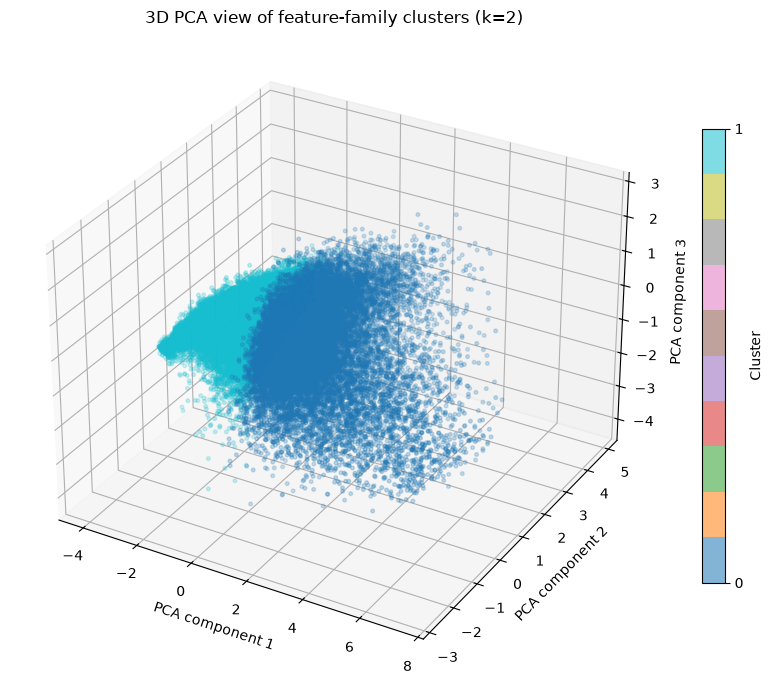

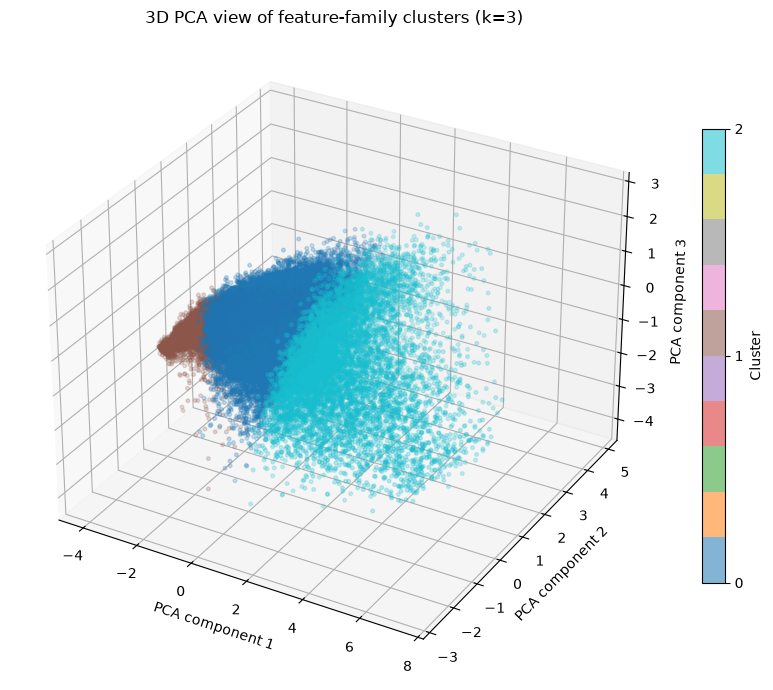

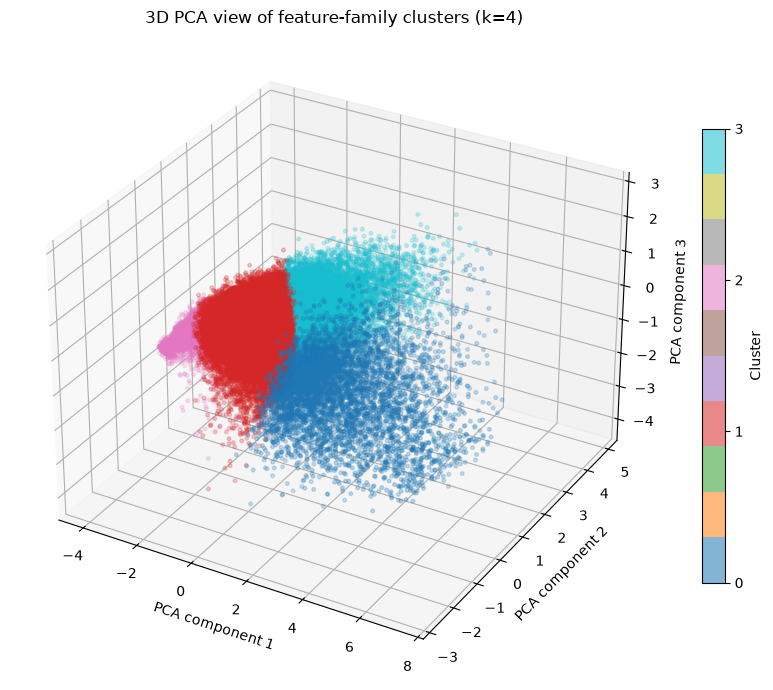

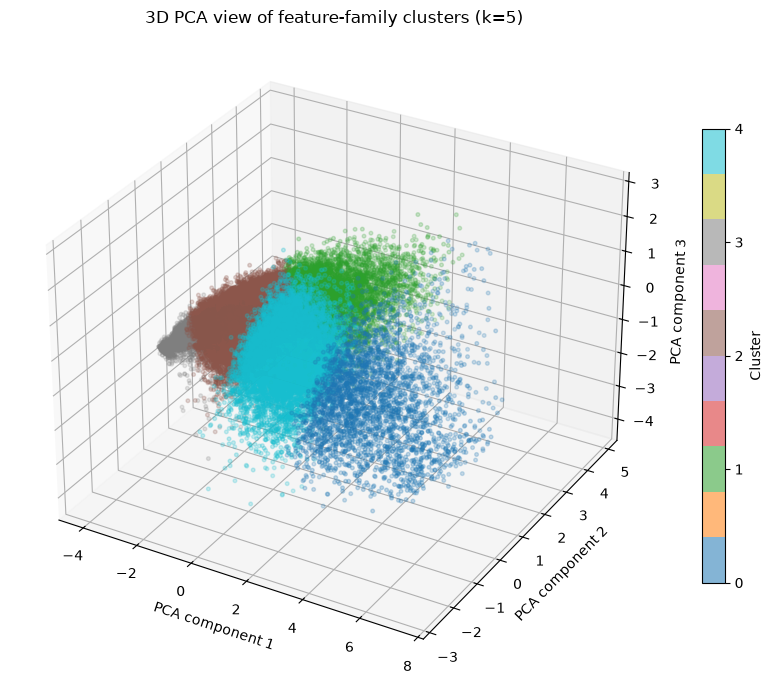

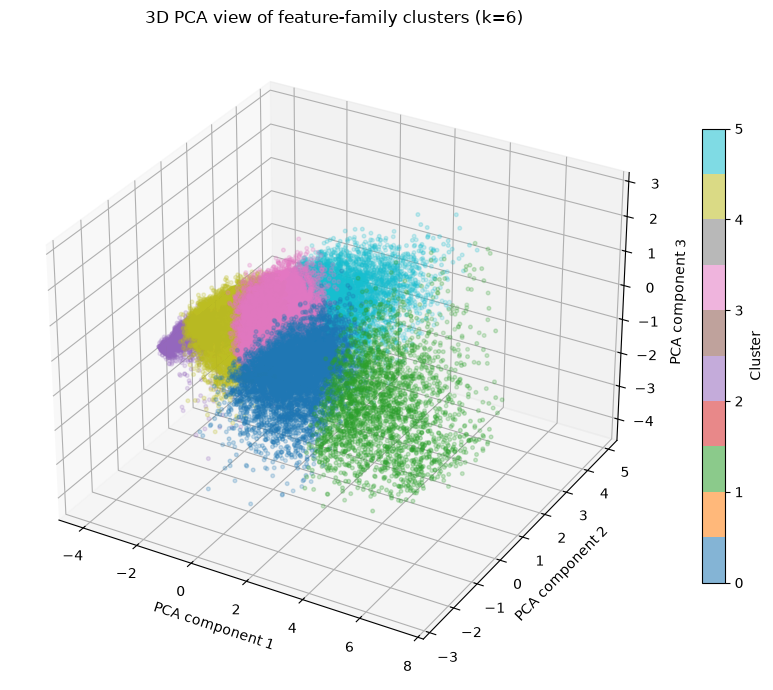

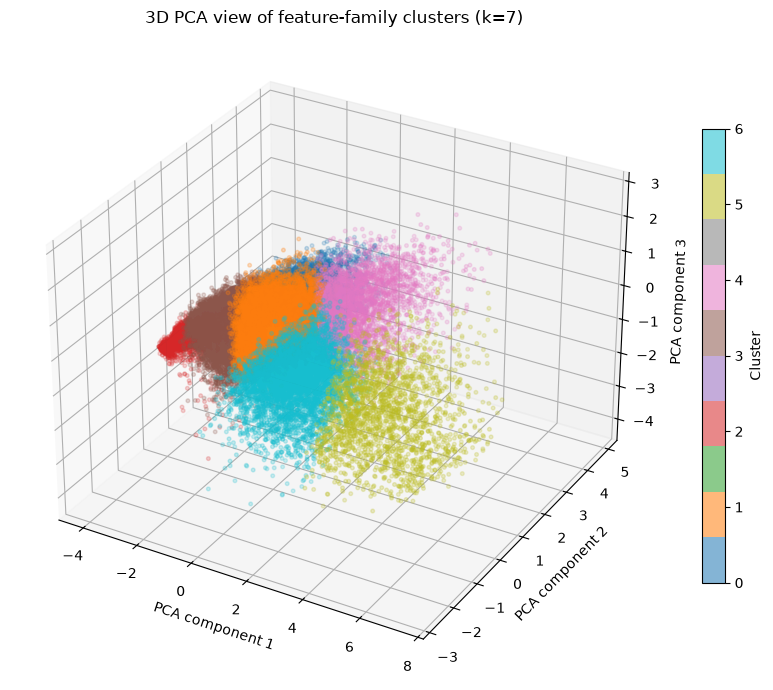

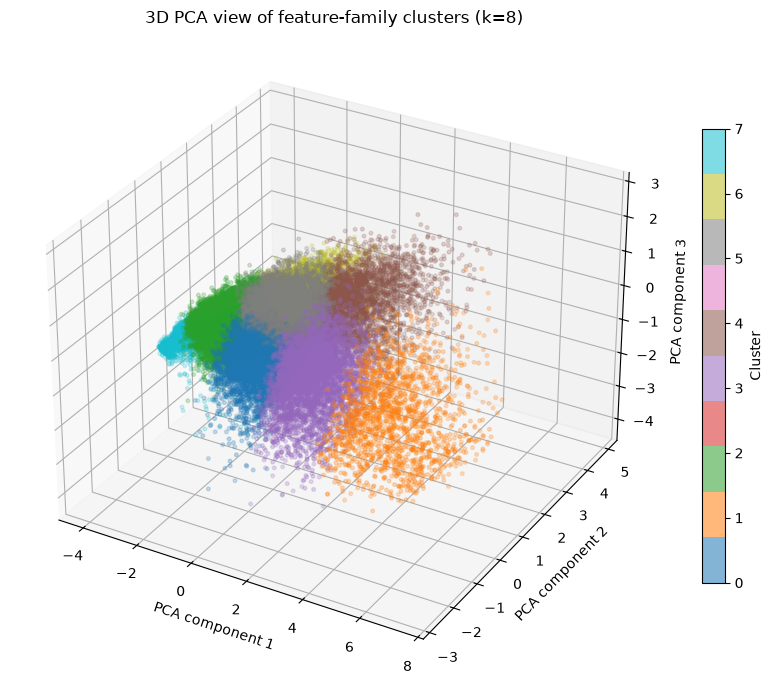

3D PCA explained variance:


,pca_component,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,0.5454,0.5454
1,2,0.1615,0.7069
2,3,0.1053,0.8121


Saved 3D PCA cluster projections for k values: [2, 3, 4, 5, 6, 7, 8]


In [ ]:
#3d pca projection for cluster visual checks; this uses the same scaled feature-family matrix from the clustering section.
cluster_3d_projection_summary_df = pd.DataFrame()
cluster_3d_projection_df = pd.DataFrame()

required_3d_objects = ["family_scaled", "cluster_prediction_df"]
missing_3d_objects = [name for name in required_3d_objects if name not in globals()]
if missing_3d_objects:
    print("3D cluster projection skipped because the clustering inputs are unavailable:", missing_3d_objects)
else:
    fixed_cluster_prediction_df = cluster_prediction_df.reset_index(drop=True).copy()
    n_rows = min(len(fixed_cluster_prediction_df), family_scaled.shape[0])
    fixed_cluster_prediction_df = fixed_cluster_prediction_df.iloc[:n_rows].copy()
    fixed_family_scaled = family_scaled[:n_rows]

    pca_3d_model = PCA(n_components=3, random_state=42)
    pca_3d_coordinates = pca_3d_model.fit_transform(fixed_family_scaled)
    explained_variance = pca_3d_model.explained_variance_ratio_

    cluster_3d_projection_summary_df = pd.DataFrame({"pca_component": [1, 2, 3],
        "explained_variance_ratio": explained_variance,
        "cumulative_explained_variance_ratio": np.cumsum(explained_variance)})

    #use the fixed-k labels when available because they include the clinically interpretable alternatives.
    projection_solution_labels = {}
    if "cluster_fixed_k_pca_df" in globals() and not cluster_fixed_k_pca_df.empty:
        #loop through each item in this feature block
        for k_value, k_df in cluster_fixed_k_pca_df.groupby("solution_k"):
            labels = k_df.sort_index()["cluster_label"].to_numpy()
        
            if len(labels) >= n_rows:
                projection_solution_labels[int(k_value)] = labels[:n_rows]

    #fall back to the silhouette-selected clustering labels if fixed-k labels are not in memory.
    if not projection_solution_labels and "cluster_pca_df" in globals() and not cluster_pca_df.empty:
        labels = cluster_pca_df.sort_index()["cluster_label"].to_numpy()
    
        if len(labels) >= n_rows:
            projection_solution_labels[int(cluster_pca_df["cluster_label"].nunique())] = labels[:n_rows]

    #if neither previous output exists in memory, recreate the standard fixed k values from the scaled matrix.
    if not projection_solution_labels:
        for k_value in [2, 3, 4, 5]:
            projection_solution_labels[k_value] = KMeans(n_clusters=k_value, random_state=42, n_init=50).fit_predict(fixed_family_scaled)

    projection_rows = []
    #loop through each item in this feature block
    for k_value, labels in projection_solution_labels.items():
        plot_df = fixed_cluster_prediction_df[[col for col in ["subject_id", "hadm_id", "readmitted_30d", "predicted_probability"] if col in fixed_cluster_prediction_df.columns]].copy()
        plot_df["solution_k"] = k_value
        plot_df["cluster_label"] = labels
        plot_df["pca_component_1"] = pca_3d_coordinates[:, 0]
        plot_df["pca_component_2"] = pca_3d_coordinates[:, 1]
        plot_df["pca_component_3"] = pca_3d_coordinates[:, 2]
        projection_rows.append(plot_df)

        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection="3d")
        scatter = ax.scatter(plot_df["pca_component_1"], plot_df["pca_component_2"], plot_df["pca_component_3"],
            c=plot_df["cluster_label"], cmap="tab10", s=7, alpha=0.55)
        ax.set_xlabel("PCA component 1")
        ax.set_ylabel("PCA component 2")
        ax.set_zlabel("PCA component 3")
        ax.set_title(f"3D PCA view of feature-family clusters (k={k_value})")
        fig.colorbar(scatter, ax=ax, ticks=range(int(k_value)), shrink=0.7, label="Cluster")
        plt.tight_layout()
        plt.savefig(wp3_6_image_output_path / f"t3_6_cluster_fixed_k_{k_value}_pca_3d_projection.png", dpi=300)
        plt.show()

    #save this table or artefact for later review
    cluster_3d_projection_df = pd.concat(projection_rows, ignore_index=True) if projection_rows else pd.DataFrame()
    cluster_3d_projection_summary_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_pca_3d_explained_variance.csv", index=False)
    cluster_3d_projection_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_pca_3d_coordinates.csv", index=False)
    print("3D PCA explained variance:")
    display(cluster_3d_projection_summary_df.round(4))
    print("Saved 3D PCA cluster projections for k values:", sorted(projection_solution_labels.keys()))

#### **Cluster Interpretation Tables**

The cluster plots show geometric separation, but the write-up needs interpretable patient profiles. This section converts the cluster outputs into labelled summaries: how each cluster differs from the overall test cohort, which feature families distinguish it, where the model performs well or poorly, and which admissions are most representative of each profile.




In [ ]:
#cluster interpretation tables for write-up; these tables turn the fixed-k clusters into readable patient-profile summaries.
cluster_interpretation_summary_df = pd.DataFrame()
cluster_distinguishing_family_df = pd.DataFrame()
cluster_representative_cases_df = pd.DataFrame()
cluster_error_profile_df = pd.DataFrame()

preferred_cluster_solution_k = 4

#make feature-family names easier to read in cluster labels
def _format_family_label(feature_family):
    return str(feature_family).replace("_", " ")

#build a short cluster label from the strongest feature-family signals
def _build_cluster_label(row):
    high_families = [row.get("top_high_family_1"), row.get("top_high_family_2"), row.get("top_high_family_3")]
    high_families = [_format_family_label(family) for family in high_families if pd.notna(family)]

    if not high_families:
        return "Unlabelled patient profile"
    return "High " + " / ".join(high_families[:2])

#describe how separable each cluster is based on pr-auc and threshold behaviour
def _model_strength_label(row):
    pr_auc = row.get("pr_auc_average_precision", np.nan)
    recall = row.get("recall_sensitivity", np.nan)
    specificity = row.get("specificity", np.nan)
    if pd.notna(pr_auc) and pr_auc >= 0.75:
        return "model-detectable high-separation profile"
    if pd.notna(recall) and recall < 0.35 and pd.notna(specificity) and specificity >= 0.90:
        return "rule-out leaning profile with low recall"
    if pd.notna(pr_auc) and pr_auc < 0.50:
        return "prediction-difficult mixed profile"
    return "moderate-separation profile"

#describe whether each cluster has higher, lower, or average observed risk
def _risk_label(readmission_rate, overall_rate):
    if pd.isna(readmission_rate) or pd.isna(overall_rate):
        return "risk unavailable"
    if readmission_rate >= overall_rate + 0.08:
        return "higher observed readmission risk"
    if readmission_rate <= overall_rate - 0.05:
        return "lower observed readmission risk"
    return "near-average observed readmission risk"

if "cluster_fixed_k_profile_df" not in globals() or cluster_fixed_k_profile_df.empty:
    print("Cluster interpretation skipped because fixed-k cluster profiles are unavailable.")
else:
    cluster_profile_source_df = cluster_fixed_k_profile_df.copy()
    #only feature-family columns should be interpreted as cluster-family scores.
    #columns such as mean_predicted_probability also start with "mean_", but they are model outputs, not family scores.
    known_non_family_mean_cols = {"mean_predicted_probability"}
    family_mean_cols = [col for col in cluster_profile_source_df.columns
        if col.startswith("mean_") and col not in known_non_family_mean_cols]
    family_cols = [col.replace("mean_", "", 1) for col in family_mean_cols]
    if "fixed_family_matrix_df" in globals():
        family_cols = [col for col in family_cols if col in fixed_family_matrix_df.columns]
        family_mean_cols = [f"mean_{col}" for col in family_cols if f"mean_{col}" in cluster_profile_source_df.columns]

    #focus the main interpretation on k=4 when available because it gives a good balance of detail and sample size.
    available_k_values = sorted(cluster_profile_source_df["solution_k"].dropna().unique().astype(int).tolist())
    interpretation_k = preferred_cluster_solution_k if preferred_cluster_solution_k in available_k_values else available_k_values[0]
    interpretation_profile_df = cluster_profile_source_df.loc[cluster_profile_source_df["solution_k"] == interpretation_k].copy()

    overall_readmission_rate = all_prediction_df["readmitted_30d"].mean() if "all_prediction_df" in globals() and not all_prediction_df.empty else interpretation_profile_df["readmission_rate"].mean()
    overall_predicted_probability = all_prediction_df["predicted_probability"].mean() if "all_prediction_df" in globals() and not all_prediction_df.empty else interpretation_profile_df["mean_predicted_probability"].mean()

    interpretation_rows = []
    distinguishing_rows = []
    #loop through each item in this feature block
    for _, profile_row in interpretation_profile_df.iterrows():
        cluster_label = int(profile_row["cluster_label"])
        family_scores = profile_row[family_mean_cols].rename(lambda x: x.replace("mean_", "", 1)).sort_values(ascending=False)
        top_high = family_scores.head(3)
        top_low = family_scores.tail(3).sort_values()
        risk_lift = profile_row["readmission_rate"] / overall_readmission_rate if overall_readmission_rate else np.nan
        predicted_risk_lift = profile_row["mean_predicted_probability"] / overall_predicted_probability if overall_predicted_probability else np.nan

        suggested_label = "High " + " / ".join([_format_family_label(name) for name in top_high.index[:2]])
        model_strength = _model_strength_label(profile_row)
        risk_summary = _risk_label(profile_row["readmission_rate"], overall_readmission_rate)
        interpretation = (
            f"{risk_summary}; {model_strength}. Main distinguishing families: "
            f"{', '.join([_format_family_label(name) for name in top_high.index[:3]])}.")

        interpretation_rows.append({"solution_k": interpretation_k,
            "cluster_label": cluster_label,
            "suggested_cluster_label": suggested_label,
            "admissions": int(profile_row["admissions"]),
            "readmission_rate": profile_row["readmission_rate"],
            "overall_readmission_rate": overall_readmission_rate,
            "readmission_rate_difference": profile_row["readmission_rate"] - overall_readmission_rate,
            "readmission_risk_lift": risk_lift,
            "mean_predicted_probability": profile_row["mean_predicted_probability"],
            "overall_mean_predicted_probability": overall_predicted_probability,
            "predicted_risk_lift": predicted_risk_lift,
            "roc_auc": profile_row.get("roc_auc", np.nan),
            "pr_auc_average_precision": profile_row.get("pr_auc_average_precision", np.nan),
            "precision": profile_row.get("precision", np.nan),
            "recall_sensitivity": profile_row.get("recall_sensitivity", np.nan),
            "specificity": profile_row.get("specificity", np.nan),
            "model_strength_label": model_strength,
            "risk_label": risk_summary,
            "interpretation_sentence": interpretation,
            "top_high_families": ", ".join([_format_family_label(name) for name in top_high.index[:3]]),
            "top_low_families": ", ".join([_format_family_label(name) for name in top_low.index[:3]])})

        #loop through each item in this feature block
        for rank, (family_name, family_score) in enumerate(family_scores.items(), start=1):
            distinguishing_rows.append({"solution_k": interpretation_k,
                "cluster_label": cluster_label,
                "feature_family": family_name,
                "family_label": _format_family_label(family_name),
                "mean_family_score": family_score,
                "absolute_family_score": abs(family_score),
                "rank_within_cluster": rank,
                "direction": "higher" if family_score >= 0 else "lower"})

    cluster_interpretation_summary_df = pd.DataFrame(interpretation_rows).sort_values(
        "readmission_rate", ascending=False)
    cluster_distinguishing_family_df = pd.DataFrame(distinguishing_rows).sort_values(
        ["cluster_label", "absolute_family_score"], ascending=[True, False])

    #representative cases: closest admissions to each cluster centre in family-score space.
    if "cluster_fixed_k_pca_df" in globals() and not cluster_fixed_k_pca_df.empty and "fixed_family_matrix_df" in globals():
        fixed_k_case_df = cluster_fixed_k_pca_df.loc[cluster_fixed_k_pca_df["solution_k"] == interpretation_k].reset_index(drop=True).copy()
        fixed_family_for_cases_df = fixed_family_matrix_df.reset_index(drop=True).iloc[:len(fixed_k_case_df)].copy()
        representative_rows = []
        for cluster_label, cluster_index in fixed_k_case_df.groupby("cluster_label").groups.items():
            cluster_indices = np.array(list(cluster_index))
            cluster_family_values = fixed_family_for_cases_df.iloc[cluster_indices][family_cols]
            cluster_centre = cluster_family_values.mean(axis=0)
            distances = np.sqrt(((cluster_family_values - cluster_centre) ** 2).sum(axis=1))
            closest_positions = distances.sort_values().head(3).index
            #loop through each item in this feature block
            for representative_rank, row_index in enumerate(closest_positions, start=1):
                case_row = fixed_k_case_df.loc[row_index].copy()
                representative_rows.append({"solution_k": interpretation_k,
                    "cluster_label": int(cluster_label),
                    "representative_rank": representative_rank,
                    "distance_to_cluster_centre": distances.loc[row_index],
                    **{col: case_row[col] for col in ["subject_id", "hadm_id", "readmitted_30d", "predicted_probability"] if col in case_row.index}})
        cluster_representative_cases_df = pd.DataFrame(representative_rows).sort_values(["cluster_label", "representative_rank"])

    #error burden table adds counts and rates, not only precision/recall.
    if "cluster_fixed_k_pca_df" in globals() and not cluster_fixed_k_pca_df.empty and "cluster_prediction_df" in globals() and not cluster_prediction_df.empty:
        fixed_k_case_df = cluster_fixed_k_pca_df.loc[cluster_fixed_k_pca_df["solution_k"] == interpretation_k].reset_index(drop=True).copy()
        prediction_source_df = cluster_prediction_df.reset_index(drop=True).iloc[:len(fixed_k_case_df)].copy()
        selected_threshold = float(recommended_model_comparison_df.iloc[0]["threshold"]) if not recommended_model_comparison_df.empty else 0.5
        prediction_source_df["cluster_label"] = fixed_k_case_df["cluster_label"].to_numpy()
        prediction_source_df["cluster_predicted_label"] = (prediction_source_df["predicted_probability"] >= selected_threshold).astype(int)
        error_rows = []
        for cluster_label, cluster_df in prediction_source_df.groupby("cluster_label"):
            y_true = cluster_df["readmitted_30d"].astype(int)
            y_pred = cluster_df["cluster_predicted_label"].astype(int)
            tp = int(((y_true == 1) & (y_pred == 1)).sum())
            fp = int(((y_true == 0) & (y_pred == 1)).sum())
            tn = int(((y_true == 0) & (y_pred == 0)).sum())
            fn = int(((y_true == 1) & (y_pred == 0)).sum())
            error_rows.append({"solution_k": interpretation_k,
                "cluster_label": int(cluster_label),
                "admissions": len(cluster_df),
                "true_positives": tp,
                "false_positives": fp,
                "true_negatives": tn,
                "false_negatives": fn,
                "false_positive_rate": fp / (fp + tn) if (fp + tn) else np.nan,
                "false_negative_rate": fn / (fn + tp) if (fn + tp) else np.nan,
                "positive_prediction_rate": (tp + fp) / len(cluster_df) if len(cluster_df) else np.nan,
                "selected_threshold": selected_threshold})
        cluster_error_profile_df = pd.DataFrame(error_rows).sort_values("false_negative_rate", ascending=False)

    #save this table or artefact for later review
    cluster_interpretation_summary_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_interpretation_summary.csv", index=False)
    cluster_distinguishing_family_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_distinguishing_families.csv", index=False)
    cluster_representative_cases_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_representative_cases.csv", index=False)
    cluster_error_profile_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_error_profile.csv", index=False)

    print(f"Cluster interpretation uses fixed k={interpretation_k}.")
    print("Cluster interpretation summary:")
    display(cluster_interpretation_summary_df.round(4))
    print("Top distinguishing families by cluster:")
    #summarise row-level records to admission-level features
    display(cluster_distinguishing_family_df.groupby("cluster_label").head(5).round(4))
    if not cluster_representative_cases_df.empty:
        print("Representative admissions closest to each cluster centre:")
        display(cluster_representative_cases_df.round(4))
    if not cluster_error_profile_df.empty:
        print("Cluster error profile:")
        display(cluster_error_profile_df.round(4))

Cluster interpretation uses fixed k=4.
Cluster interpretation summary:


,solution_k,cluster_label,suggested_cluster_label,admissions,readmission_rate,overall_readmission_rate,readmission_rate_difference,readmission_risk_lift,mean_predicted_probability,overall_mean_predicted_probability,predicted_risk_lift,roc_auc,pr_auc_average_precision,precision,recall_sensitivity,specificity,model_strength_label,risk_label,interpretation_sentence,top_high_families,top_low_families
0,4,3,High prior utilisation / psychiatric history,9699,0.2946,0.1963,0.0982,1.5002,0.3601,0.3002,1.1995,0.7944,0.6602,0.5130,0.7158,0.7163,moderate-separation profile,higher observed readmission risk,higher observed readmission risk; moderate-sep...,"prior utilisation, psychiatric history, medica...","lab vital burden, medical complexity, order ac..."
1,4,2,High prior utilisation / psychiatric history,7963,0.2841,0.1963,0.0877,1.4468,0.3326,0.3002,1.1080,0.9030,0.8377,0.6657,0.8134,0.8379,model-detectable high-separation profile,higher observed readmission risk,higher observed readmission risk; model-detect...,"prior utilisation, psychiatric history, ed adm...","medication emar, order activity, medical compl..."
2,4,0,High medication emar / medical complexity,5748,0.1874,0.1963,-0.0090,0.9543,0.2300,0.3002,0.7661,0.7680,0.4445,0.4383,0.4225,0.8752,prediction-difficult mixed profile,near-average observed readmission risk,near-average observed readmission risk; predic...,"medication emar, medical complexity, order act...","prior utilisation, psychiatric history, discha..."
3,4,1,High discharge social / lab vital burden,23761,0.1314,0.1963,-0.0649,0.6694,0.1832,0.3002,0.6104,0.7040,0.3066,0.3962,0.1985,0.9542,rule-out leaning profile with low recall,lower observed readmission risk,lower observed readmission risk; rule-out lean...,"discharge social, lab vital burden, order acti...","prior utilisation, medication emar, psychiatri..."


Top distinguishing families by cluster:


,solution_k,cluster_label,feature_family,family_label,mean_family_score,absolute_family_score,rank_within_cluster,direction
16,4,0,medication_emar,medication emar,0.5987,0.5987,1,higher
17,4,0,medical_complexity,medical complexity,0.4888,0.4888,2,higher
18,4,0,order_activity,order activity,0.3365,0.3365,3,higher
19,4,0,lab_vital_burden,lab vital burden,0.3240,0.3240,4,higher
20,4,0,ed_admission_pathway,ed admission pathway,0.3031,0.3031,5,higher
31,4,1,prior_utilisation,prior utilisation,-0.0957,0.0957,8,lower
30,4,1,medication_emar,medication emar,-0.0805,0.0805,7,lower
29,4,1,psychiatric_history,psychiatric history,-0.0783,0.0783,6,lower
24,4,1,discharge_social,discharge social,0.0692,0.0692,1,higher
28,4,1,medical_complexity,medical complexity,-0.0355,0.0355,5,lower


Representative admissions closest to each cluster centre:


,solution_k,cluster_label,representative_rank,distance_to_cluster_centre,subject_id,hadm_id,readmitted_30d,predicted_probability
0,4,0,1,0.1531,13219116.0,22102586.0,0.0,0.3598
1,4,0,2,0.1556,14056241.0,22100362.0,0.0,0.1407
2,4,0,3,0.1557,10148710.0,22444443.0,0.0,0.1905
3,4,1,1,0.0440,16450866.0,21908312.0,0.0,0.1153
4,4,1,2,0.0891,10602633.0,28070534.0,0.0,0.0938
5,4,1,3,0.0921,13474913.0,22319856.0,0.0,0.1234
6,4,2,1,0.0891,11761121.0,25962138.0,1.0,0.3554
7,4,2,2,0.0909,10038688.0,22936433.0,0.0,0.2842
8,4,2,3,0.0930,15774622.0,27054102.0,0.0,0.0714
9,4,3,1,0.1410,17107885.0,28932395.0,1.0,0.4008


Cluster error profile:


,solution_k,cluster_label,admissions,true_positives,false_positives,true_negatives,false_negatives,false_positive_rate,false_negative_rate,positive_prediction_rate,selected_threshold
1,4,1,23761,620,945,19693,2503,0.0458,0.8015,0.0659,0.36
0,4,0,5748,455,583,4088,622,0.1248,0.5775,0.1806,0.36
3,4,3,9699,2045,1941,4901,812,0.2837,0.2842,0.4110,0.36
2,4,2,7963,1840,924,4777,422,0.1621,0.1866,0.3471,0.36


### **3.6.8 Statistical Uncertainty and Exploratory Tests**

This section adds statistical uncertainty around the final evaluation outputs. Bootstrap confidence intervals estimate how much the reported test-set metrics may vary if the held-out cohort were resampled. Paired bootstrap comparisons compare models on the same admissions. Cluster tests are exploratory and are used to describe whether cluster profiles differ meaningfully by outcome or feature-family scores.




In [ ]:
#estimate uncertainty around model metrics, subgroup summaries, and cluster profiles
bootstrap_iterations = 500
bootstrap_random_seed = 42
bootstrap_top_model_count = 10
bootstrap_rng = np.random.default_rng(bootstrap_random_seed)

model_metric_bootstrap_ci_df = pd.DataFrame()
paired_model_bootstrap_difference_df = pd.DataFrame()
subgroup_performance_ci_df = pd.DataFrame()
cluster_family_statistical_tests_df = pd.DataFrame()
cluster_outcome_statistical_tests_df = pd.DataFrame()

#calculate auc-style metrics only when both outcome classes are present
def _safe_auc_metric(metric_function, y_true, y_probability):

    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return metric_function(y_true, y_probability)

#calculate discrimination, calibration, and threshold metrics in one reusable bundle
def _metric_bundle(y_true, y_probability, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_probability = np.asarray(y_probability).astype(float)
    y_predicted = (y_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_predicted, labels=[0, 1]).ravel()
    return {"roc_auc": _safe_auc_metric(roc_auc_score, y_true, y_probability),
        "pr_auc_average_precision": _safe_auc_metric(average_precision_score, y_true, y_probability),
        "brier_score": brier_score_loss(y_true, y_probability),
        "precision": precision_score(y_true, y_predicted, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_predicted, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "f1_score": f1_score(y_true, y_predicted, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_predicted)}

#bootstrap metric values so confidence intervals can be estimated
def _bootstrap_metric_ci(y_true, y_probability, threshold, iterations=500, rng=None):
    rng = np.random.default_rng(42) if rng is None else rng
    y_true = np.asarray(y_true).astype(int)
    y_probability = np.asarray(y_probability).astype(float)
    n_rows = len(y_true)
    metric_rows = []
    #loop through each item in this feature block
    for _ in range(iterations):
        sample_index = rng.integers(0, n_rows, size=n_rows)
        sample_y = y_true[sample_index]
    
        if pd.Series(sample_y).nunique() < 2:
            continue
        metric_rows.append(_metric_bundle(sample_y, y_probability[sample_index], threshold))
    return pd.DataFrame(metric_rows)

#summarise bootstrap metric distributions into 95 percent confidence intervals
def _ci_summary_from_bootstrap(bootstrap_df, id_values):
    rows = []
    if bootstrap_df.empty:
        return pd.DataFrame(rows)
    for metric_name in bootstrap_df.columns:
        values = pd.to_numeric(bootstrap_df[metric_name], errors="coerce").dropna()
        if values.empty:
            continue
        rows.append({**id_values,
            "metric": metric_name,
            "bootstrap_iterations_used": len(values),
            "bootstrap_mean": values.mean(),
            "bootstrap_median": values.median(),
            "ci_lower_2_5": values.quantile(0.025),
            "ci_upper_97_5": values.quantile(0.975)})
    return pd.DataFrame(rows)

#align two prediction tables by admission ids before comparing model probabilities
def _align_model_predictions(reference_df, comparison_df):
    id_columns = [col for col in ["subject_id", "hadm_id"] if col in reference_df.columns and col in comparison_df.columns]
    if len(id_columns) == 2:
        reference_cols = id_columns + ["readmitted_30d", "predicted_probability"]
        comparison_cols = id_columns + ["readmitted_30d", "predicted_probability"]
        #join the derived features back to the admission table
        aligned_df = reference_df[reference_cols].merge(comparison_df[comparison_cols], on=id_columns,
            suffixes=("_reference", "_comparison"), how="inner")
        aligned_df = aligned_df.loc[aligned_df["readmitted_30d_reference"].eq(aligned_df["readmitted_30d_comparison"])].copy()
        return aligned_df["readmitted_30d_reference"].to_numpy(), aligned_df["predicted_probability_reference"].to_numpy(), aligned_df["predicted_probability_comparison"].to_numpy()
    n_rows = min(len(reference_df), len(comparison_df))
    return (reference_df["readmitted_30d"].iloc[:n_rows].to_numpy(),
        reference_df["predicted_probability"].iloc[:n_rows].to_numpy(),
        comparison_df["predicted_probability"].iloc[:n_rows].to_numpy())

#calculate a wilson confidence interval for a subgroup rate or proportion
def _wilson_interval(successes, total, alpha=0.05):
    if total <= 0:
        return (np.nan, np.nan)
    if proportion_confint_available:
        return proportion_confint(successes, total, alpha=alpha, method="wilson")
    proportion = successes / total
    z_value = 1.96
    standard_error = np.sqrt(proportion * (1 - proportion) / total)
    return (max(0, proportion - z_value * standard_error), min(1, proportion + z_value * standard_error))

#add lower and upper confidence interval columns for one rate
def _add_rate_ci(row, success_column, total_value, prefix):
    successes = int(row.get(success_column, 0)) if pd.notna(row.get(success_column, np.nan)) else 0
    lower, upper = _wilson_interval(successes, int(total_value))
    row[f"{prefix}_ci_lower_95"] = lower
    row[f"{prefix}_ci_upper_95"] = upper
    return row

#adjust multiple p-values using the benjamini-hochberg false-discovery method
def _benjamini_hochberg(p_values):
    p_values = pd.Series(p_values, dtype="float64")
    q_values = pd.Series(np.nan, index=p_values.index, dtype="float64")
    valid = p_values.dropna().sort_values()
    if valid.empty:
        return q_values
    n_tests = len(valid)
    adjusted = valid * n_tests / np.arange(1, n_tests + 1)
    adjusted = adjusted.iloc[::-1].cummin().iloc[::-1].clip(upper=1)
    q_values.loc[adjusted.index] = adjusted
    return q_values

if all_prediction_df.empty or recommended_model_comparison_df.empty:
    print("Bootstrap model uncertainty skipped because model predictions or recommended model rows are unavailable.")
else:
    model_ci_rows = []
    top_model_rows = recommended_model_comparison_df.head(bootstrap_top_model_count).copy()
    threshold_lookup = top_model_rows.set_index("model_family")["threshold"].to_dict()
    for _, model_row in top_model_rows.iterrows():
        model_family = model_row["model_family"]
        model_predictions = all_prediction_df.loc[all_prediction_df["model_family"].eq(model_family)].copy()
        if model_predictions.empty:
            continue
        bootstrap_df = _bootstrap_metric_ci(model_predictions["readmitted_30d"],
            model_predictions["predicted_probability"], float(model_row["threshold"]),
            iterations=bootstrap_iterations, rng=bootstrap_rng)
        model_ci_rows.append(_ci_summary_from_bootstrap(bootstrap_df,
            {"model_family": model_family, "threshold": float(model_row["threshold"])}))
    model_metric_bootstrap_ci_df = pd.concat(model_ci_rows, ignore_index=True) if model_ci_rows else pd.DataFrame()
    #save this table or artefact for later review
    model_metric_bootstrap_ci_df.to_csv(wp3_6_csv_output_path / "t3_6_model_metric_bootstrap_confidence_intervals.csv", index=False)
    print("Bootstrap metric confidence interval rows:", len(model_metric_bootstrap_ci_df))
    if not model_metric_bootstrap_ci_df.empty:
        display(model_metric_bootstrap_ci_df.head(40).round(4))

    paired_rows = []
    reference_family = top_model_rows.iloc[0]["model_family"]
    reference_predictions = all_prediction_df.loc[all_prediction_df["model_family"].eq(reference_family)].copy()
    reference_threshold = float(top_model_rows.iloc[0]["threshold"])
    for _, comparison_row in top_model_rows.iloc[1:].iterrows():
        comparison_family = comparison_row["model_family"]
        comparison_predictions = all_prediction_df.loc[all_prediction_df["model_family"].eq(comparison_family)].copy()
        if comparison_predictions.empty or reference_predictions.empty:
            continue
        y_aligned, ref_prob, comp_prob = _align_model_predictions(reference_predictions, comparison_predictions)
        if len(y_aligned) == 0 or pd.Series(y_aligned).nunique() < 2:
            continue
        comparison_threshold = float(comparison_row["threshold"])
        difference_rows = []
        #loop through each item in this feature block
        for _ in range(bootstrap_iterations):
            sample_index = bootstrap_rng.integers(0, len(y_aligned), size=len(y_aligned))
            sample_y = y_aligned[sample_index]
        
            if pd.Series(sample_y).nunique() < 2:
                continue
            reference_metrics = _metric_bundle(sample_y, ref_prob[sample_index], reference_threshold)
            comparison_metrics = _metric_bundle(sample_y, comp_prob[sample_index], comparison_threshold)
            difference_rows.append({metric_name: comparison_metrics[metric_name] - reference_metrics[metric_name]
                for metric_name in ["roc_auc", "pr_auc_average_precision", "brier_score", "precision",
                    "recall_sensitivity", "specificity", "f1_score", "balanced_accuracy"]})
        difference_df = pd.DataFrame(difference_rows)
        for metric_name in difference_df.columns:
            values = pd.to_numeric(difference_df[metric_name], errors="coerce").dropna()
            if values.empty:
                continue
            paired_rows.append({"reference_model_family": reference_family,
                "comparison_model_family": comparison_family,
                "metric": metric_name,
                "difference_direction": "comparison_minus_reference",
                "bootstrap_iterations_used": len(values),
                "mean_difference": values.mean(),
                "median_difference": values.median(),
                "ci_lower_2_5": values.quantile(0.025),
                "ci_upper_97_5": values.quantile(0.975),
                "probability_comparison_greater_than_reference": (values > 0).mean()})
    paired_model_bootstrap_difference_df = pd.DataFrame(paired_rows)
    paired_model_bootstrap_difference_df.to_csv(wp3_6_csv_output_path / "t3_6_paired_model_bootstrap_differences.csv", index=False)
    print("Paired bootstrap model-comparison rows:", len(paired_model_bootstrap_difference_df))
    if not paired_model_bootstrap_difference_df.empty:
        display(paired_model_bootstrap_difference_df.head(40).round(4))

if "subgroup_performance_df" in globals() and not subgroup_performance_df.empty:
    subgroup_performance_ci_df = subgroup_performance_df.copy()
    ci_rows = []
    for _, row in subgroup_performance_ci_df.iterrows():
        enriched_row = row.copy()
        admissions = int(row.get("admissions", row.get("true_positives", 0) + row.get("false_positives", 0) + row.get("false_negatives", 0) + row.get("true_negatives", 0)))
        tp = int(row.get("true_positives", 0))
        fp = int(row.get("false_positives", 0))
        fn = int(row.get("false_negatives", 0))
        tn = int(row.get("true_negatives", 0))
        enriched_row = _add_rate_ci(enriched_row, "true_positives", tp + fn, "recall_sensitivity")
        enriched_row = _add_rate_ci(enriched_row, "true_positives", tp + fp, "precision")
        enriched_row = _add_rate_ci(enriched_row, "true_negatives", tn + fp, "specificity")
        enriched_row["readmission_rate_ci_lower_95"], enriched_row["readmission_rate_ci_upper_95"] = _wilson_interval(tp + fn, admissions)
        ci_rows.append(enriched_row)
    subgroup_performance_ci_df = pd.DataFrame(ci_rows)
    subgroup_performance_ci_df.to_csv(wp3_6_csv_output_path / "t3_6_subgroup_performance_with_confidence_intervals.csv", index=False)
    print("Subgroup confidence interval rows:", len(subgroup_performance_ci_df))
    display(subgroup_performance_ci_df.head(30).round(4))
else:
    print("Subgroup confidence intervals skipped because subgroup_performance_df is unavailable or empty.")

#exploratory cluster tests compare cluster labels with outcomes and feature-family scores.
if "cluster_fixed_k_pca_df" in globals() and not cluster_fixed_k_pca_df.empty and "fixed_family_matrix_df" in globals():
    available_k_values = sorted(cluster_fixed_k_pca_df["solution_k"].dropna().astype(int).unique().tolist())
    statistical_test_k = preferred_cluster_solution_k if "preferred_cluster_solution_k" in globals() and preferred_cluster_solution_k in available_k_values else available_k_values[0]
    cluster_test_case_df = cluster_fixed_k_pca_df.loc[cluster_fixed_k_pca_df["solution_k"].eq(statistical_test_k)].reset_index(drop=True).copy()
    family_test_df = fixed_family_matrix_df.reset_index(drop=True).iloc[:len(cluster_test_case_df)].copy()
    family_test_df["cluster_label"] = cluster_test_case_df["cluster_label"].to_numpy()

    family_test_rows = []
    family_test_columns = [col for col in family_test_df.columns if col != "cluster_label"]
    for family_column in family_test_columns:
        grouped_values = [pd.to_numeric(group_df[family_column], errors="coerce").dropna().to_numpy()
            #summarise row-level records to admission-level features
            for _, group_df in family_test_df.groupby("cluster_label")]
        grouped_values = [values for values in grouped_values if len(values) > 0]
        if len(grouped_values) < 2:
            continue
        test_statistic, p_value = stats.kruskal(*grouped_values)
        family_test_rows.append({"solution_k": statistical_test_k,
            "feature_family": family_column,
            "test": "kruskal_wallis",
            "test_statistic": test_statistic,
            "p_value": p_value})
    cluster_family_statistical_tests_df = pd.DataFrame(family_test_rows)
    if not cluster_family_statistical_tests_df.empty:
        cluster_family_statistical_tests_df["q_value_bh"] = _benjamini_hochberg(cluster_family_statistical_tests_df["p_value"])
        cluster_family_statistical_tests_df = cluster_family_statistical_tests_df.sort_values("q_value_bh")
    cluster_family_statistical_tests_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_family_exploratory_tests.csv", index=False)

    outcome_test_rows = []
    for outcome_column in ["readmitted_30d", "predicted_probability"]:
        if outcome_column not in cluster_test_case_df.columns:
            continue
        if outcome_column == "readmitted_30d":
            contingency_table = pd.crosstab(cluster_test_case_df["cluster_label"], cluster_test_case_df[outcome_column])
            if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
                chi2_statistic, p_value, degrees_freedom, _ = stats.chi2_contingency(contingency_table)
                outcome_test_rows.append({"solution_k": statistical_test_k,
                    "outcome_or_score": outcome_column,
                    "test": "chi_square",
                    "test_statistic": chi2_statistic,
                    "degrees_freedom": degrees_freedom,
                    "p_value": p_value})
        else:
            grouped_values = [pd.to_numeric(group_df[outcome_column], errors="coerce").dropna().to_numpy()
                #summarise row-level records to admission-level features
                for _, group_df in cluster_test_case_df.groupby("cluster_label")]
            grouped_values = [values for values in grouped_values if len(values) > 0]
            if len(grouped_values) > 1:
                test_statistic, p_value = stats.kruskal(*grouped_values)
                outcome_test_rows.append({"solution_k": statistical_test_k,
                    "outcome_or_score": outcome_column,
                    "test": "kruskal_wallis",
                    "test_statistic": test_statistic,
                    "degrees_freedom": np.nan,
                    "p_value": p_value})
    cluster_outcome_statistical_tests_df = pd.DataFrame(outcome_test_rows)
    if not cluster_outcome_statistical_tests_df.empty:
        cluster_outcome_statistical_tests_df["q_value_bh"] = _benjamini_hochberg(cluster_outcome_statistical_tests_df["p_value"])
    cluster_outcome_statistical_tests_df.to_csv(wp3_6_csv_output_path / "t3_6_cluster_outcome_exploratory_tests.csv", index=False)

    print("Cluster exploratory family-test rows:", len(cluster_family_statistical_tests_df))
    if not cluster_family_statistical_tests_df.empty:
        display(cluster_family_statistical_tests_df.round(6))
    print("Cluster exploratory outcome-test rows:", len(cluster_outcome_statistical_tests_df))
    if not cluster_outcome_statistical_tests_df.empty:
        display(cluster_outcome_statistical_tests_df.round(6))
else:
    print("Cluster exploratory tests skipped because fixed-k cluster outputs are unavailable.")

Bootstrap metric confidence interval rows: 80


,model_family,threshold,metric,bootstrap_iterations_used,bootstrap_mean,bootstrap_median,ci_lower_2_5,ci_upper_97_5
0,Ensemble - LightGBM-heavy blend 50,0.36,roc_auc,500,0.8010,0.8010,0.7957,0.8066
1,Ensemble - LightGBM-heavy blend 50,0.36,pr_auc_average_precision,500,0.5962,0.5962,0.5869,0.6054
2,Ensemble - LightGBM-heavy blend 50,0.36,brier_score,500,0.1209,0.1209,0.1191,0.1225
3,Ensemble - LightGBM-heavy blend 50,0.36,precision,500,0.5303,0.5301,0.5202,0.5407
4,Ensemble - LightGBM-heavy blend 50,0.36,recall_sensitivity,500,0.5318,0.5321,0.5219,0.5425
5,Ensemble - LightGBM-heavy blend 50,0.36,specificity,500,0.8841,0.8841,0.8809,0.8873
6,Ensemble - LightGBM-heavy blend 50,0.36,f1_score,500,0.5311,0.5310,0.5225,0.5400
7,Ensemble - LightGBM-heavy blend 50,0.36,balanced_accuracy,500,0.7080,0.7080,0.7027,0.7137
8,Ensemble - LightGBM-heavy blend 60,0.35,roc_auc,500,0.8012,0.8012,0.7961,0.8064
9,Ensemble - LightGBM-heavy blend 60,0.35,pr_auc_average_precision,500,0.5964,0.5967,0.5875,0.6054


Paired bootstrap model-comparison rows: 72


,reference_model_family,comparison_model_family,metric,difference_direction,bootstrap_iterations_used,mean_difference,median_difference,ci_lower_2_5,ci_upper_97_5,probability_comparison_greater_than_reference
0,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 60,roc_auc,comparison_minus_reference,500,-0.0000,-0.0000,-0.0001,0.0001,0.332
1,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 60,pr_auc_average_precision,comparison_minus_reference,500,-0.0001,-0.0001,-0.0002,0.0000,0.108
2,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 60,brier_score,comparison_minus_reference,500,-0.0008,-0.0008,-0.0008,-0.0007,0.000
3,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 60,precision,comparison_minus_reference,500,0.0004,0.0004,-0.0007,0.0014,0.738
4,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 60,recall_sensitivity,comparison_minus_reference,500,0.0005,0.0004,-0.0005,0.0016,0.762
5,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 60,specificity,comparison_minus_reference,500,0.0001,0.0001,-0.0004,0.0006,0.602
6,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 60,f1_score,comparison_minus_reference,500,0.0004,0.0004,-0.0005,0.0013,0.810
7,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 60,balanced_accuracy,comparison_minus_reference,500,0.0003,0.0003,-0.0003,0.0009,0.814
8,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 70,roc_auc,comparison_minus_reference,500,-0.0001,-0.0001,-0.0003,0.0001,0.170
9,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 70,pr_auc_average_precision,comparison_minus_reference,500,-0.0002,-0.0002,-0.0004,0.0000,0.046


Subgroup confidence interval rows: 60


,model,threshold,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc_average_precision,brier_score,true_negatives,false_positives,false_negatives,true_positives,subgroup_column,subgroup_value,admissions,readmission_rate,recall_sensitivity_ci_lower_95,recall_sensitivity_ci_upper_95,precision_ci_lower_95,precision_ci_upper_95,specificity_ci_lower_95,specificity_ci_upper_95,readmission_rate_ci_lower_95,readmission_rate_ci_upper_95
0,Ensemble - LightGBM-heavy blend 50,0.36,0.8245,0.6960,0.5375,0.4899,0.9022,0.5126,0.7971,0.5800,0.1173,17354,1882,2277,2187,gender,F,23700,0.1884,0.4753,0.5046,0.5221,0.5528,0.8979,0.9063,0.1834,0.1934
1,Ensemble - LightGBM-heavy blend 50,0.36,0.8043,0.7181,0.5248,0.5712,0.8651,0.5470,0.8048,0.6117,0.1244,16105,2511,2082,2773,gender,M,23471,0.2069,0.5572,0.5850,0.5113,0.5382,0.8601,0.8699,0.2017,0.2121
2,Ensemble - LightGBM-heavy blend 50,0.36,0.8521,0.7980,0.6334,0.7047,0.8914,0.6672,0.8895,0.7725,0.0942,4283,522,378,902,age_group,18-29,6085,0.2104,0.6791,0.7290,0.6081,0.6581,0.8822,0.8999,0.2003,0.2208
3,Ensemble - LightGBM-heavy blend 50,0.36,0.7952,0.7267,0.5351,0.6033,0.8501,0.5672,0.8089,0.6420,0.1276,3267,576,436,663,age_group,30-39,4942,0.2224,0.5740,0.6318,0.5073,0.5627,0.8385,0.8611,0.2110,0.2342
4,Ensemble - LightGBM-heavy blend 50,0.36,0.7753,0.7297,0.5279,0.6415,0.8178,0.5792,0.8088,0.6422,0.1372,4476,997,623,1115,age_group,40-49,7211,0.2410,0.6187,0.6638,0.5066,0.5492,0.8074,0.8278,0.2313,0.2510
5,Ensemble - LightGBM-heavy blend 50,0.36,0.7821,0.7158,0.5213,0.5936,0.8381,0.5551,0.7964,0.6206,0.1345,6227,1203,897,1310,age_group,50-59,9637,0.2290,0.5729,0.6139,0.5017,0.5408,0.8295,0.8463,0.2207,0.2375
6,Ensemble - LightGBM-heavy blend 50,0.36,0.8111,0.6567,0.4712,0.4156,0.8978,0.4416,0.7572,0.4764,0.1257,6043,688,862,613,age_group,60-69,8206,0.1797,0.3907,0.4409,0.4442,0.4983,0.8903,0.9048,0.1716,0.1882
7,Ensemble - LightGBM-heavy blend 50,0.36,0.8468,0.6085,0.4588,0.2720,0.9451,0.3415,0.7412,0.4132,0.1100,4531,263,597,223,age_group,70-79,5614,0.1461,0.2426,0.3034,0.4150,0.5033,0.9383,0.9512,0.1371,0.1555
8,Ensemble - LightGBM-heavy blend 50,0.36,0.8703,0.5806,0.4820,0.1914,0.9698,0.2740,0.7180,0.3364,0.1027,4632,144,566,134,age_group,80+,5476,0.1278,0.1640,0.2222,0.4239,0.5406,0.9646,0.9743,0.1192,0.1369
9,Ensemble - LightGBM-heavy blend 50,0.36,0.7991,0.7324,0.5412,0.6125,0.8522,0.5747,0.8186,0.6489,0.1254,21487,3726,2780,4395,age_65plus,0,32388,0.2215,0.6012,0.6238,0.5303,0.5520,0.8478,0.8565,0.2170,0.2261


Cluster exploratory family-test rows: 8


,solution_k,feature_family,test,test_statistic,p_value,q_value_bh
0,4,prior_utilisation,kruskal_wallis,8929.241189,0.0,0.0
1,4,psychiatric_history,kruskal_wallis,21632.332632,0.0,0.0
2,4,order_activity,kruskal_wallis,27355.956665,0.0,0.0
3,4,medication_emar,kruskal_wallis,25748.853292,0.0,0.0
4,4,medical_complexity,kruskal_wallis,16451.773184,0.0,0.0
5,4,lab_vital_burden,kruskal_wallis,17020.700600,0.0,0.0
6,4,ed_admission_pathway,kruskal_wallis,28142.558559,0.0,0.0
7,4,discharge_social,kruskal_wallis,22498.331211,0.0,0.0


Cluster exploratory outcome-test rows: 2


,solution_k,outcome_or_score,test,test_statistic,degrees_freedom,p_value,q_value_bh
0,4,readmitted_30d,chi_square,1610.763173,3.0,0.0,0.0
1,4,predicted_probability,kruskal_wallis,5192.900073,NaN,0.0,0.0


### **3.6.9 Final Threshold and Run Provenance**

This section turns the model-comparison outputs into two compact audit tables. The first records the selected operating threshold and the expected trade-off at that threshold. The second records which dataset, feature matrix, model file, and output folders produced the final results. A small paired-correlation table checks whether the strongest models are making very similar probability rankings.


In [ ]:
#summarise the final threshold choice, run inputs, and agreement between saved model probabilities
final_threshold_recommendation_df = pd.DataFrame()
model_run_provenance_df = pd.DataFrame()
paired_probability_correlation_df = pd.DataFrame()

if "recommended_model_comparison_df" in globals() and not recommended_model_comparison_df.empty:
    threshold_columns = [col for col in ["model_selection_rank", "source_notebook", "model_family", "model_group",
        "model", "recommended_threshold_label", "threshold", "precision", "recall_sensitivity",
        "specificity", "f1_score", "balanced_accuracy", "roc_auc", "pr_auc_average_precision",
        "brier_score", "true_positives", "false_positives", "false_negatives", "true_negatives",
        "threshold_selection_note"] if col in recommended_model_comparison_df.columns]
    final_threshold_recommendation_df = recommended_model_comparison_df[threshold_columns].copy()
    final_threshold_recommendation_df["clinical_tradeoff_note"] = np.where(
        final_threshold_recommendation_df.get("recall_sensitivity", pd.Series(dtype=float)).ge(
            final_threshold_recommendation_df.get("precision", pd.Series(dtype=float))),
        "recall-leaning or balanced threshold", "precision-leaning threshold")
    #save this table or artefact for later review
    final_threshold_recommendation_df.to_csv(wp3_6_csv_output_path / "t3_6_final_threshold_recommendation.csv", index=False)
    print("Final threshold recommendation rows:", len(final_threshold_recommendation_df))
    display(final_threshold_recommendation_df.head(10).round(4))
else:
    print("Final threshold recommendation skipped because recommended model rows are unavailable.")

#record the exact files and matrix choice used by this final-evaluation notebook.
provenance_rows = []
for name in ["project_path", "wp3_input_variant", "wp3_1_output_path", "wp3_2_output_path",
    "wp3_3_output_path", "wp3_4_output_path", "wp3_5_output_path", "wp3_6_output_path"]:
    value = globals().get(name, np.nan)
    provenance_rows.append({"field": name, "value": str(value)})
#loop through each item in this feature block
for name in ["X_train", "X_test", "y_train", "y_test", "feature_names"]:
    value = globals().get(name)
    if hasattr(value, "shape"):
        provenance_rows.append({"field": f"{name}_shape", "value": str(value.shape)})
    elif value is not None and name == "feature_names":
        provenance_rows.append({"field": "feature_name_count", "value": str(len(value))})
if "best_model_selection_summary_df" in globals() and not best_model_selection_summary_df.empty:
    best_row = best_model_selection_summary_df.iloc[0]
    #loop through each item in this feature block
    for col in best_model_selection_summary_df.columns:
        provenance_rows.append({"field": f"selected_model_{col}", "value": str(best_row[col])})
model_run_provenance_df = pd.DataFrame(provenance_rows)
#save this table or artefact for later review
model_run_provenance_df.to_csv(wp3_6_csv_output_path / "t3_6_model_run_provenance.csv", index=False)
display(model_run_provenance_df.head(25))

#compare probability rankings from the strongest saved models on the same admissions.
if "all_prediction_df" in globals() and not all_prediction_df.empty:
    candidate_families = []
    if "recommended_model_comparison_df" in globals() and not recommended_model_comparison_df.empty and "model_family" in recommended_model_comparison_df.columns:
        candidate_families = recommended_model_comparison_df["model_family"].dropna().astype(str).drop_duplicates().head(8).tolist()
    else:
        candidate_families = all_prediction_df["model_family"].dropna().astype(str).drop_duplicates().head(8).tolist()
    id_cols_for_merge = [col for col in ["subject_id", "hadm_id"] if col in all_prediction_df.columns]
    correlation_rows = []
    for left_index, left_family in enumerate(candidate_families):
        left_df = all_prediction_df.loc[all_prediction_df["model_family"].astype(str).eq(left_family)].copy()
        #loop through each item in this feature block
        for right_family in candidate_families[left_index + 1:]:
            right_df = all_prediction_df.loc[all_prediction_df["model_family"].astype(str).eq(right_family)].copy()
        
            if id_cols_for_merge:
                merged_df = left_df[id_cols_for_merge + ["predicted_probability"]].merge(
                    right_df[id_cols_for_merge + ["predicted_probability"]], on=id_cols_for_merge,
                    suffixes=("_left", "_right"), how="inner")
            else:
                n_rows = min(len(left_df), len(right_df))
                merged_df = pd.DataFrame({"predicted_probability_left": left_df["predicted_probability"].iloc[:n_rows].to_numpy(),
                    "predicted_probability_right": right_df["predicted_probability"].iloc[:n_rows].to_numpy()})
            if len(merged_df) < 10:
                continue
            correlation_rows.append({"model_family_left": left_family,
                "model_family_right": right_family,
                "aligned_admissions": len(merged_df),
                "pearson_probability_correlation": merged_df["predicted_probability_left"].corr(merged_df["predicted_probability_right"], method="pearson"),
                "spearman_rank_correlation": merged_df["predicted_probability_left"].corr(merged_df["predicted_probability_right"], method="spearman"),
                "mean_absolute_probability_difference": (merged_df["predicted_probability_left"] - merged_df["predicted_probability_right"]).abs().mean()})
    paired_probability_correlation_df = pd.DataFrame(correlation_rows).sort_values(
        ["spearman_rank_correlation", "pearson_probability_correlation"], ascending=False).reset_index(drop=True) if correlation_rows else pd.DataFrame()
    paired_probability_correlation_df.to_csv(wp3_6_csv_output_path / "t3_6_paired_probability_correlations.csv", index=False)
    print("Paired probability-correlation rows:", len(paired_probability_correlation_df))
    if not paired_probability_correlation_df.empty:
        display(paired_probability_correlation_df.round(4))
else:
    print("Probability-correlation summary skipped because saved predictions are unavailable.")

Final threshold recommendation rows: 32


,model_selection_rank,source_notebook,model_family,model_group,model,recommended_threshold_label,threshold,precision,recall_sensitivity,specificity,f1_score,balanced_accuracy,roc_auc,pr_auc_average_precision,brier_score,true_positives,false_positives,false_negatives,true_negatives,threshold_selection_note,clinical_tradeoff_note
95,1,WP3.6,Ensemble - LightGBM-heavy blend 50,ensemble_lightgbm-heavy_blend_50,Ensemble - LightGBM-heavy blend 50,closest usable precision-recall threshold,0.36,0.5303,0.5322,0.8839,0.5313,0.7081,0.8012,0.5965,0.1208,4960,4393,4359,33459,Fallback: closest usable precision-recall bala...,recall-leaning or balanced threshold
96,2,WP3.6,Ensemble - LightGBM-heavy blend 60,ensemble_lightgbm-heavy_blend_60,Ensemble - LightGBM-heavy blend 60,closest usable precision-recall threshold,0.35,0.5307,0.5327,0.8840,0.5317,0.7083,0.8012,0.5964,0.1201,4964,4390,4355,33462,Fallback: closest usable precision-recall bala...,recall-leaning or balanced threshold
97,3,WP3.6,Ensemble - LightGBM-heavy blend 70,ensemble_lightgbm-heavy_blend_70,Ensemble - LightGBM-heavy blend 70,closest usable precision-recall threshold,0.34,0.5306,0.5332,0.8839,0.5319,0.7086,0.8011,0.5963,0.1194,4969,4395,4350,33457,Fallback: closest usable precision-recall bala...,recall-leaning or balanced threshold
98,4,WP3.6,Ensemble - LightGBM-heavy blend 80,ensemble_lightgbm-heavy_blend_80,Ensemble - LightGBM-heavy blend 80,closest usable precision-recall threshold,0.33,0.5299,0.5321,0.8838,0.5310,0.7079,0.8009,0.5961,0.1189,4959,4400,4360,33452,Fallback: closest usable precision-recall bala...,recall-leaning or balanced threshold
93,5,WP3.6,Ensemble - boosting plus neural average,ensemble_boosting_plus_neural_average,Ensemble - boosting plus neural average,closest usable precision-recall threshold,0.41,0.5291,0.5314,0.8835,0.5302,0.7075,0.8004,0.5958,0.1265,4952,4408,4367,33444,Fallback: closest usable precision-recall bala...,recall-leaning or balanced threshold
99,6,WP3.6,Ensemble - LightGBM-heavy blend 90,ensemble_lightgbm-heavy_blend_90,Ensemble - LightGBM-heavy blend 90,closest usable precision-recall threshold,0.32,0.5296,0.5326,0.8835,0.5311,0.7080,0.8006,0.5958,0.1185,4963,4409,4356,33443,Fallback: closest usable precision-recall bala...,recall-leaning or balanced threshold
43,7,WP3.4,Targeted LightGBM,lightgbm_targeted,Targeted LightGBM balanced precision-recall th...,balanced precision-recall threshold,0.32,0.5418,0.5189,0.8920,0.5301,0.7055,0.8002,0.5954,0.1182,4836,4089,4483,33763,Usable balanced precision-recall threshold sel...,precision-leaning threshold
92,8,WP3.6,Ensemble - boosting top 3 average,ensemble_boosting_top_3_average,Ensemble - boosting top 3 average,closest usable precision-recall threshold,0.35,0.5338,0.5258,0.8870,0.5298,0.7064,0.8003,0.5953,0.1199,4900,4279,4419,33573,Fallback: closest usable precision-recall bala...,precision-leaning threshold
94,9,WP3.6,Ensemble - LightGBM/XGBoost average,ensemble_lightgbm/xgboost_average,Ensemble - LightGBM/XGBoost average,closest usable precision-recall threshold,0.37,0.5350,0.5255,0.8875,0.5302,0.7065,0.8002,0.5947,0.1214,4897,4257,4422,33595,Fallback: closest usable precision-recall bala...,precision-leaning threshold
38,10,WP3.4,LightGBM,lightgbm,LightGBM balanced precision-recall threshold,balanced precision-recall threshold,0.60,0.5511,0.5054,0.8987,0.5273,0.7020,0.7996,0.5926,0.1598,4710,3836,4609,34016,Usable balanced precision-recall threshold sel...,precision-leaning threshold


,field,value
0,project_path,/scratch/DissProject
1,wp3_input_variant,shap_guided_reduced_feature_set
2,wp3_1_output_path,/scratch/DissProject/outputs/WP3_1
3,wp3_2_output_path,/scratch/DissProject/outputs/WP3_2
4,wp3_3_output_path,/scratch/DissProject/outputs/WP3_3
5,wp3_4_output_path,/scratch/DissProject/outputs/WP3_4
6,wp3_5_output_path,/scratch/DissProject/outputs/WP3_5
7,wp3_6_output_path,/scratch/DissProject/outputs/WP3_6
8,y_train_shape,"(191320,)"
9,y_test_shape,"(47171,)"


Paired probability-correlation rows: 28


,model_family_left,model_family_right,aligned_admissions,pearson_probability_correlation,spearman_rank_correlation,mean_absolute_probability_difference
0,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 60,47171,0.9998,0.9998,0.0068
1,Ensemble - LightGBM-heavy blend 60,Ensemble - LightGBM-heavy blend 70,47171,0.9998,0.9997,0.0068
2,Ensemble - LightGBM-heavy blend 70,Ensemble - LightGBM-heavy blend 80,47171,0.9998,0.9997,0.0068
3,Ensemble - LightGBM-heavy blend 80,Ensemble - LightGBM-heavy blend 90,47171,0.9998,0.9996,0.0068
4,Ensemble - LightGBM-heavy blend 90,Targeted LightGBM,47171,0.9998,0.9996,0.0068
5,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 70,47171,0.9993,0.9990,0.0137
6,Ensemble - LightGBM-heavy blend 60,Ensemble - LightGBM-heavy blend 80,47171,0.9993,0.9988,0.0137
7,Ensemble - LightGBM-heavy blend 70,Ensemble - LightGBM-heavy blend 90,47171,0.9993,0.9987,0.0137
8,Ensemble - LightGBM-heavy blend 80,Targeted LightGBM,47171,0.9993,0.9985,0.0137
9,Ensemble - LightGBM-heavy blend 50,Ensemble - LightGBM-heavy blend 80,47171,0.9985,0.9975,0.0205


### **3.6.10 Method Audit, Leakage Controls, and Stress Checks**

This section creates compact tables that document the analysis design, leakage controls, reproducibility details, and simple performance checks across time and admission-context groups. These outputs support the methods chapter without adding another modelling loop.


In [ ]:
#create method audit, leakage-control, reproducibility, and stress-test tables
methodology_audit_df = pd.DataFrame([{"analysis_layer": "primary analysis",
     "purpose": "rank admissions by 30-day psychiatric readmission risk",
     "implementation": "primary reduced structured ehr matrix with final selected boosting model",
     "main_metric": "pr_auc_average_precision",
     "supporting_outputs": "recommended model table, high-risk strata, calibration, threshold summaries"},
    {"analysis_layer": "secondary model comparison",
     "purpose": "compare interpretable baseline, tree ensembles, boosting models, and neural comparators",
     "implementation": "wp3.2 to wp3.5 saved predictions merged in wp3.6",
     "main_metric": "pr_auc_average_precision",
     "supporting_outputs": "all model rows, recommended rows, combined curves"},
    {"analysis_layer": "threshold analysis",
     "purpose": "choose an operating point after probability ranking has been assessed",
     "implementation": "balanced precision-recall, optimal f1, fixed recall, and cost-sensitive threshold tables",
     "main_metric": "precision, recall, specificity, f1",
     "supporting_outputs": "threshold tradeoff and final threshold recommendation tables"},
    {"analysis_layer": "feature-matrix sensitivity",
     "purpose": "test whether smaller audited matrices retain similar performance",
     "implementation": "full, clean, runtime-trimmed, primary reduced, and top-n feature comparisons",
     "main_metric": "pr_auc_average_precision and runtime",
     "supporting_outputs": "reduced matrix sensitivity and top-n sensitivity tables"},
    {"analysis_layer": "subgroup analysis",
     "purpose": "identify groups where the global model performs differently",
     "implementation": "global model restricted to subgroup plus selected subgroup-specific refits",
     "main_metric": "pr_auc_average_precision, recall, precision, f1",
     "supporting_outputs": "clinical, diagnosis, older, and medical-complexity subgroup tables"},
    {"analysis_layer": "time-frame sensitivity",
     "purpose": "check whether 30-day model scores also identify nearby or later psychiatric readmissions",
     "implementation": "fixed 30-day probabilities evaluated against 14-, 60-, 90-, and 365-day labels",
     "main_metric": "pr_auc_average_precision and error reclassification",
     "supporting_outputs": "outcome-window score transfer and cutoff proximity tables"},
    {"analysis_layer": "explanation analysis",
     "purpose": "explain global signal, local cases, false results, model consistency, and hourly sequence reliance",
     "implementation": "wp4 shap, paired shap, subgroup shap, and hourly occlusion summaries",
     "main_metric": "mean absolute shap or occlusion performance drop",
     "supporting_outputs": "wp4 global, local, paired, subgroup, and hourly explanation tables"}])

#save this table or artefact for later review
methodology_audit_df.to_csv(wp3_6_csv_output_path / "t3_6_methodology_audit_table.csv", index=False)
display(methodology_audit_df)

leakage_control_audit_df = pd.DataFrame([{"leakage_or_bias_risk": "same patient appearing in train and test",
     "control": "patient-level split with overlap audit",
     "evidence_table": "wp3.1 modelling preparation audit",
     "residual_risk": "low if patient overlap remains zero"},
    {"leakage_or_bias_risk": "future readmission information entering predictors",
     "control": "features are derived from index admission and prior history only",
     "evidence_table": "wp2.3 engineered dataset and wp3.1 feature audit",
     "residual_risk": "depends on accurate exclusion of future admissions"},
    {"leakage_or_bias_risk": "post-discharge variables used at prediction time",
     "control": "prediction context is at discharge using data available by discharge",
     "evidence_table": "wp3.6 model run provenance",
     "residual_risk": "late discharge fields are valid only for discharge-time prediction"},
    {"leakage_or_bias_risk": "feature-selection evidence overfitting",
     "control": "primary reduced matrix is compared against full and audited matrices as sensitivity",
     "evidence_table": "reduced feature sensitivity tables",
     "residual_risk": "reduced set should be described as development-informed"},
    {"leakage_or_bias_risk": "threshold chosen to favour held-out results",
     "control": "threshold families are reported separately from ranking metrics",
     "evidence_table": "threshold tradeoff and final threshold recommendation tables",
     "residual_risk": "operating threshold should be interpreted as cohort-specific"},
    {"leakage_or_bias_risk": "unavailable social and outpatient determinants",
     "control": "structured-data limitation is documented",
     "evidence_table": "limitations and feature availability review",
     "residual_risk": "important unobserved drivers may cap predictive performance"}])

leakage_control_audit_df.to_csv(wp3_6_csv_output_path / "t3_6_leakage_control_audit_table.csv", index=False)
display(leakage_control_audit_df)

#record reproducibility details that are useful when rerunning models on another machine.
package_rows = []
#loop through each item in this feature block
for package_name in ["numpy", "pandas", "sklearn", "scipy", "xgboost", "lightgbm", "catboost", "shap", "torch"]:
    try:
        module = __import__(package_name)
        package_rows.append({"field": f"package_{package_name}", "value": getattr(module, "__version__", "available")})
    except Exception:
        package_rows.append({"field": f"package_{package_name}", "value": "not available"})
reproducibility_rows = [
    {"field": "primary_random_seed", "value": "42"},
    {"field": "primary_feature_matrix", "value": str(globals().get("wp3_input_variant", "unknown"))},
    {"field": "prediction_target", "value": "30-day psychiatric readmission"},
    {"field": "split_unit", "value": "patient"},
    {"field": "training_rows", "value": str(len(y_train)) if "y_train" in globals() else "unknown"},
    {"field": "test_rows", "value": str(len(y_test)) if "y_test" in globals() else "unknown"},
    {"field": "training_prevalence", "value": str(round(float(y_train.mean()), 6)) if "y_train" in globals() else "unknown"},
    {"field": "test_prevalence", "value": str(round(float(y_test.mean()), 6)) if "y_test" in globals() else "unknown"},
    {"field": "feature_count", "value": str(len(feature_names)) if "feature_names" in globals() else "unknown"},
    {"field": "wp3_6_output_path", "value": str(wp3_6_output_path) if "wp3_6_output_path" in globals() else "unknown"}
] + package_rows
reproducibility_audit_df = pd.DataFrame(reproducibility_rows)
reproducibility_audit_df.to_csv(wp3_6_csv_output_path / "t3_6_reproducibility_audit_table.csv", index=False)
display(reproducibility_audit_df)

#evaluate the selected model across shifted admission year and admission-context groups when columns are available.
stress_test_performance_df = pd.DataFrame()
stress_group_min_rows = 500
stress_group_columns = ["admission_year", "admission_type", "admission_location_grouped",
    "discharge_location_grouped", "insurance", "language", "race"]

if not all_prediction_df.empty and not recommended_model_comparison_df.empty and wp2_3_dataset_path.exists():
    stress_model_family = recommended_model_comparison_df.iloc[0]["model_family"]
    stress_threshold = float(recommended_model_comparison_df.iloc[0]["threshold"])
    stress_predictions = all_prediction_df.loc[all_prediction_df["model_family"].eq(stress_model_family)].copy()
    header_columns = pd.read_csv(wp2_3_dataset_path, nrows=0).columns.tolist()
    available_context_columns = [col for col in ["admittime", "admission_type", "admission_location_grouped",
        "discharge_location_grouped", "insurance", "language", "race"] if col in header_columns]

    if {"subject_id", "hadm_id"}.issubset(stress_predictions.columns) and available_context_columns:
        context_df = pd.read_csv(wp2_3_dataset_path, usecols=["subject_id", "hadm_id"] + available_context_columns)
    
        if "admittime" in context_df.columns:
            context_df["admission_year"] = pd.to_datetime(context_df["admittime"], errors="coerce").dt.year
        #join the derived features back to the admission table
        stress_df = stress_predictions.merge(context_df, on=["subject_id", "hadm_id"], how="left")
        stress_rows = []
        #loop through each item in this feature block
        for group_column in [col for col in stress_group_columns if col in stress_df.columns]:
            grouped_values = stress_df[group_column].fillna("Missing")
            #loop through each item in this feature block
            for group_value, group_df in stress_df.groupby(grouped_values, dropna=False):
            
                if len(group_df) < stress_group_min_rows or group_df["readmitted_30d"].nunique() < 2:
                    continue
                metrics = evaluate_probability_at_threshold(stress_model_family, group_df["readmitted_30d"].astype(int),
                    group_df["predicted_probability"].astype(float), stress_threshold)
                metrics.update({"stress_group": group_column,
                    "stress_group_value": str(group_value),
                    "admissions": len(group_df),
                    "readmission_rate": group_df["readmitted_30d"].mean(),
                    "threshold_role": "final_recommended_threshold"})
                stress_rows.append(metrics)
        stress_test_performance_df = pd.DataFrame(stress_rows)
        if not stress_test_performance_df.empty:
            stress_test_performance_df = stress_test_performance_df.sort_values(["stress_group", "pr_auc_average_precision"], ascending=[True, False])
    #save this table or artefact for later review
    stress_test_performance_df.to_csv(wp3_6_csv_output_path / "t3_6_context_stress_test_performance.csv", index=False)
    print("Context stress-test rows:", len(stress_test_performance_df))
    if not stress_test_performance_df.empty:
        display(stress_test_performance_df[["stress_group", "stress_group_value", "admissions",
            "readmission_rate", "threshold", "roc_auc", "pr_auc_average_precision", "precision",
            "recall_sensitivity", "specificity", "f1_score"]].round(4))
else:
    print("Context stress test skipped because predictions, recommended rows, or engineered data are unavailable.")

,analysis_layer,purpose,implementation,main_metric,supporting_outputs
0,primary analysis,rank admissions by 30-day psychiatric readmiss...,primary reduced structured ehr matrix with fin...,pr_auc_average_precision,"recommended model table, high-risk strata, cal..."
1,secondary model comparison,"compare interpretable baseline, tree ensembles...",wp3.2 to wp3.5 saved predictions merged in wp3.6,pr_auc_average_precision,"all model rows, recommended rows, combined curves"
2,threshold analysis,choose an operating point after probability ra...,"balanced precision-recall, optimal f1, fixed r...","precision, recall, specificity, f1",threshold tradeoff and final threshold recomme...
3,feature-matrix sensitivity,test whether smaller audited matrices retain s...,"full, clean, runtime-trimmed, primary reduced,...",pr_auc_average_precision and runtime,reduced matrix sensitivity and top-n sensitivi...
4,subgroup analysis,identify groups where the global model perform...,global model restricted to subgroup plus selec...,"pr_auc_average_precision, recall, precision, f1","clinical, diagnosis, older, and medical-comple..."
5,time-frame sensitivity,check whether 30-day model scores also identif...,fixed 30-day probabilities evaluated against 1...,pr_auc_average_precision and error reclassific...,outcome-window score transfer and cutoff proxi...
6,explanation analysis,"explain global signal, local cases, false resu...","wp4 shap, paired shap, subgroup shap, and hour...",mean absolute shap or occlusion performance drop,"wp4 global, local, paired, subgroup, and hourl..."


,leakage_or_bias_risk,control,evidence_table,residual_risk
0,same patient appearing in train and test,patient-level split with overlap audit,wp3.1 modelling preparation audit,low if patient overlap remains zero
1,future readmission information entering predic...,features are derived from index admission and ...,wp2.3 engineered dataset and wp3.1 feature audit,depends on accurate exclusion of future admiss...
2,post-discharge variables used at prediction time,prediction context is at discharge using data ...,wp3.6 model run provenance,late discharge fields are valid only for disch...
3,feature-selection evidence overfitting,primary reduced matrix is compared against ful...,reduced feature sensitivity tables,reduced set should be described as development...
4,threshold chosen to favour held-out results,threshold families are reported separately fro...,threshold tradeoff and final threshold recomme...,operating threshold should be interpreted as c...
5,small subgroup instability,minimum subgroup sizes and global-restricted c...,subgroup-specific model tables,subgroup refits remain exploratory if samples ...
6,unavailable social and outpatient determinants,structured-data limitation is documented,limitations and feature availability review,important unobserved drivers may cap predictiv...


,field,value
0,primary_random_seed,42
1,primary_feature_matrix,shap_guided_reduced_feature_set
2,prediction_target,30-day psychiatric readmission
3,split_unit,patient
4,training_rows,191320
5,test_rows,47171
6,training_prevalence,0.198824
7,test_prevalence,0.197558
8,feature_count,1674
9,wp3_6_output_path,/scratch/DissProject/outputs/WP3_6


Context stress-test rows: 102


,stress_group,stress_group_value,admissions,readmission_rate,threshold,roc_auc,pr_auc_average_precision,precision,recall_sensitivity,specificity,f1_score
75,admission_location_grouped,Internal transfer involving psych,1181,0.1660,0.36,0.8607,0.7280,0.7170,0.5816,0.9543,0.6423
74,admission_location_grouped,Emergency room,22833,0.2182,0.36,0.8116,0.6388,0.5452,0.5902,0.8626,0.5668
76,admission_location_grouped,Other,4830,0.2002,0.36,0.7904,0.5905,0.5389,0.5377,0.8848,0.5383
77,admission_location_grouped,Physician / clinic referral,12106,0.1892,0.36,0.7844,0.5539,0.5080,0.4863,0.8901,0.4969
79,admission_location_grouped,Transfer from skilled nursing facility,736,0.1848,0.36,0.7727,0.5012,0.4727,0.3824,0.9033,0.4228
...,...,...,...,...,...,...,...,...,...,...,...
98,race,UNKNOWN,1278,0.0485,0.36,0.8545,0.5943,0.7619,0.5161,0.9918,0.6154
96,race,HISPANIC/LATINO - PUERTO RICAN,1226,0.2007,0.36,0.7886,0.5683,0.4864,0.5813,0.8459,0.5296
101,race,WHITE - RUSSIAN,500,0.1700,0.36,0.7722,0.5654,0.6441,0.4471,0.9494,0.5278
100,race,WHITE - OTHER EUROPEAN,1262,0.1965,0.36,0.7835,0.5605,0.5270,0.4718,0.8964,0.4979


### **3.6.11 Combined Curves**

**Create final workbook and output file summary**

The workbook collects the final comparison tables in one place for write-up and appendix use. Individual CSV files are also retained for quick inspection.




**Combined final discrimination and calibration curves**

These figures overlay the main final models so discrimination and calibration can be read visually without overloading the results section.




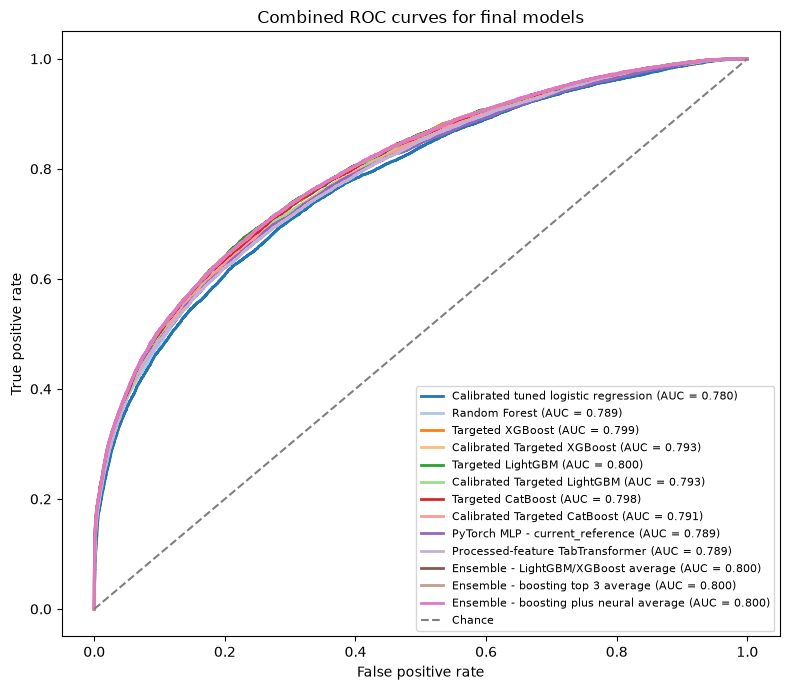

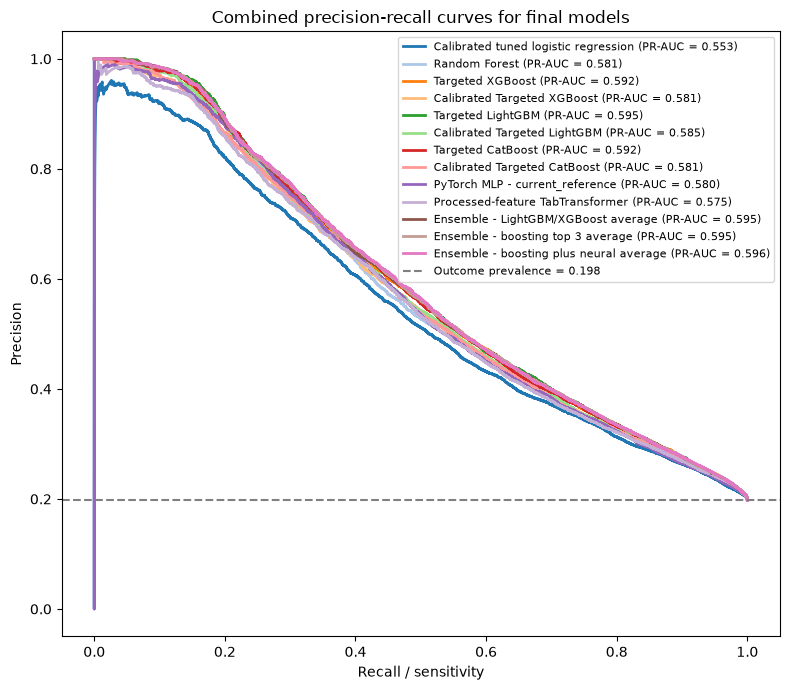

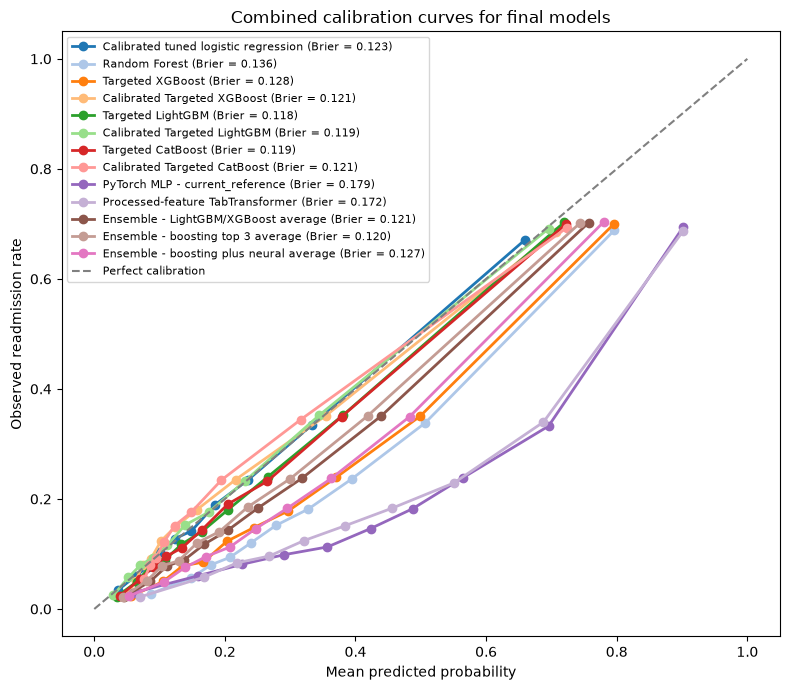

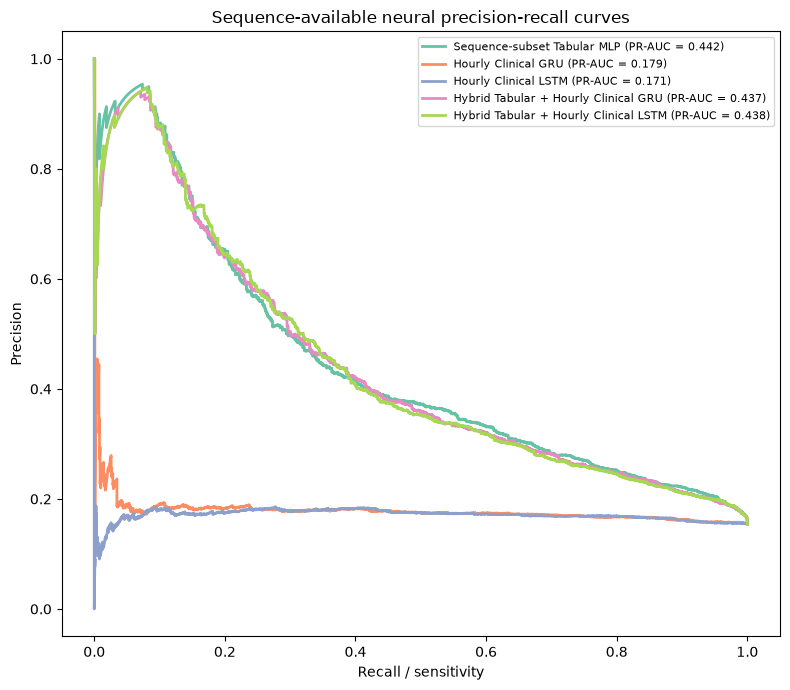

Combined curve figures saved to:
/scratch/DissProject/outputs/WP3_6/t3_6_combined_roc_curves.png
/scratch/DissProject/outputs/WP3_6/t3_6_combined_precision_recall_curves.png
/scratch/DissProject/outputs/WP3_6/t3_6_combined_calibration_curves.png


In [ ]:
#plot combined roc, precision-recall, and calibration curves for the main final models.
#the full-cohort wp3.5 neural models are included here as comparator models.
#hourly/sequence-only neural models are not included in this main overlay because they use only the sequence-available subset.
combined_curve_model_families = ["Calibrated tuned logistic regression",
    "Random Forest", "Targeted XGBoost", "Calibrated Targeted XGBoost",
    "Targeted LightGBM", "Calibrated Targeted LightGBM",
    "Targeted CatBoost", "Calibrated Targeted CatBoost",
    "PyTorch MLP - current_reference", "Processed-feature TabTransformer",
    "Ensemble - LightGBM/XGBoost average", "Ensemble - boosting top 3 average",
    "Ensemble - boosting plus neural average"]

available_curve_model_families = [model_family for model_family in combined_curve_model_families
    if model_family in set(all_prediction_df.get("model_family", pd.Series(dtype=str)))]
if all_prediction_df.empty or not available_curve_model_families:
    print("Combined curve plots skipped because saved prediction rows are unavailable.")
else:
    curve_label_df = recommended_model_comparison_df.set_index("model_family")
    outcome_prevalence = all_prediction_df.drop_duplicates(["subject_id", "hadm_id"])["readmitted_30d"].mean()
    curve_colours = dict(zip(available_curve_model_families, plt.cm.tab20.colors[:len(available_curve_model_families)]))

    plt.figure(figsize=(8, 7))
    #loop through each item in this feature block
    for model_family in available_curve_model_families:
        model_predictions = all_prediction_df.loc[all_prediction_df["model_family"] == model_family].copy()

        if model_predictions["readmitted_30d"].nunique() < 2:
            continue
        false_positive_rate, true_positive_rate, _ = roc_curve(
            model_predictions["readmitted_30d"], model_predictions["predicted_probability"])
        roc_auc_value = curve_label_df.loc[model_family, "roc_auc"] if model_family in curve_label_df.index else roc_auc_score(
            model_predictions["readmitted_30d"], model_predictions["predicted_probability"])
        plt.plot(false_positive_rate, true_positive_rate, label=f"{model_family} (AUC = {roc_auc_value:.3f})",
            color=curve_colours[model_family], linewidth=2)
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Chance")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Combined ROC curves for final models")
    plt.legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.savefig(wp3_6_image_output_path / "t3_6_combined_roc_curves.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 7))
    for model_family in available_curve_model_families:
        model_predictions = all_prediction_df.loc[all_prediction_df["model_family"] == model_family].copy()
        if model_predictions["readmitted_30d"].nunique() < 2:
            continue
        precision_values, recall_values, _ = precision_recall_curve(
            model_predictions["readmitted_30d"], model_predictions["predicted_probability"])
        pr_auc_value = curve_label_df.loc[model_family, "pr_auc_average_precision"] if model_family in curve_label_df.index else average_precision_score(
            model_predictions["readmitted_30d"], model_predictions["predicted_probability"])
        plt.plot(recall_values, precision_values, label=f"{model_family} (PR-AUC = {pr_auc_value:.3f})",
            color=curve_colours[model_family], linewidth=2)
    plt.axhline(outcome_prevalence, color="gray", linestyle="--", label=f"Outcome prevalence = {outcome_prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Combined precision-recall curves for final models")
    plt.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.savefig(wp3_6_image_output_path / "t3_6_combined_precision_recall_curves.png", dpi=300)
    plt.show()

    if calibration_table_df.empty:
        print("Combined calibration plot skipped because calibration bins are unavailable.")
    else:
        plt.figure(figsize=(8, 7))
        #loop through each item in this feature block
        for model_family in available_curve_model_families:
            model_calibration_df = calibration_table_df.loc[calibration_table_df["model_family"] == model_family].copy()
    
            if model_calibration_df.empty:
                continue
            model_calibration_df = model_calibration_df.sort_values("mean_predicted_probability")
            brier_value = curve_label_df.loc[model_family, "brier_score"] if model_family in curve_label_df.index else np.nan
            plt.plot(model_calibration_df["mean_predicted_probability"], model_calibration_df["observed_readmission_rate"],
                marker="o", linewidth=2, label=f"{model_family} (Brier = {brier_value:.3f})", color=curve_colours[model_family])
        plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Perfect calibration")
        plt.xlabel("Mean predicted probability")
        plt.ylabel("Observed readmission rate")
        plt.title("Combined calibration curves for final models")
        plt.legend(fontsize=8, loc="upper left")
        plt.tight_layout()
        plt.savefig(wp3_6_image_output_path / "t3_6_combined_calibration_curves.png", dpi=300)
        plt.show()

    #sequence-only neural models are plotted separately because their rows are restricted to admissions with hourly sequence data.
    sequence_curve_model_families = ["Sequence-subset Tabular MLP", "Hourly Clinical GRU", "Hourly Clinical LSTM",
        "Hybrid Tabular + Hourly Clinical GRU", "Hybrid Tabular + Hourly Clinical LSTM"]
    available_sequence_curve_model_families = [model_family for model_family in sequence_curve_model_families
        if model_family in set(all_prediction_df.get("model_family", pd.Series(dtype=str)))]

    if available_sequence_curve_model_families:
        sequence_colours = dict(zip(available_sequence_curve_model_families,
            plt.cm.Set2.colors[:len(available_sequence_curve_model_families)]))
        plt.figure(figsize=(8, 7))
        for model_family in available_sequence_curve_model_families:
            model_predictions = all_prediction_df.loc[all_prediction_df["model_family"] == model_family].copy()
            if model_predictions["readmitted_30d"].nunique() < 2:
                continue
            precision_values, recall_values, _ = precision_recall_curve(
                model_predictions["readmitted_30d"], model_predictions["predicted_probability"])
            pr_auc_value = curve_label_df.loc[model_family, "pr_auc_average_precision"] if model_family in curve_label_df.index else average_precision_score(
                model_predictions["readmitted_30d"], model_predictions["predicted_probability"])
            plt.plot(recall_values, precision_values, label=f"{model_family} (PR-AUC = {pr_auc_value:.3f})",
                color=sequence_colours[model_family], linewidth=2)
        plt.xlabel("Recall / sensitivity")
        plt.ylabel("Precision")
        plt.title("Sequence-available neural precision-recall curves")
        plt.legend(fontsize=8, loc="upper right")
        plt.tight_layout()
        plt.savefig(wp3_6_image_output_path / "t3_6_sequence_neural_precision_recall_curves.png", dpi=300)
        plt.show()

    print("Combined curve figures saved to:")
    print(wp3_6_output_path / "t3_6_combined_roc_curves.png")
    print(wp3_6_output_path / "t3_6_combined_precision_recall_curves.png")
    print(wp3_6_output_path / "t3_6_combined_calibration_curves.png")

In [ ]:
#write final wp3.6 workbook and file summary
workbook_tables = {"all_model_rows": all_model_performance_df,
    "recommended_models": recommended_model_comparison_df,
    "model_selection_summary": best_model_selection_summary_df,
    "probability_ensemble": ensemble_model_performance_df if "ensemble_model_performance_df" in globals() else pd.DataFrame(),
    "probability_ensemble_thresholds": ensemble_threshold_tradeoff_df if "ensemble_threshold_tradeoff_df" in globals() else pd.DataFrame(),
    "threshold_tradeoffs": threshold_tradeoff_df,
    "optimal_f1_thresholds": optimal_f1_threshold_df if "optimal_f1_threshold_df" in globals() else pd.DataFrame(),
    "class_imbalance": class_imbalance_summary_df,
    "fixed_recall_thresholds": fixed_recall_threshold_df,
    "cost_sensitive_thresholds": cost_sensitive_threshold_df,
    "cutoff_proximity_errors": cutoff_proximity_error_summary_df,
    "cutoff_proximity_cases": cutoff_proximity_case_summary_df,
    "cutoff_adjusted_metrics": cutoff_proximity_adjusted_metrics_df,
    "score_transfer_outcomes": score_transfer_outcome_df,
    "score_transfer_errors": score_transfer_error_reclassification_df,
    "error_anatomy_summary": error_anatomy_summary_df,
    "fp_future_readmission": false_positive_future_readmission_df,
    "probability_band_errors": prediction_probability_band_df,
    "borderline_errors": borderline_threshold_error_df,
    "high_confidence_errors": high_confidence_error_df,
    "risk_strata_error_mix": risk_strata_error_mix_df,
    "subgroup_error_burden": subgroup_error_burden_df,
    "non_psych_subgroup": non_psychiatric_subgroup_df,
    "top_n_feature_sensitivity": top_n_feature_sensitivity_df,
    "top_n_feature_names": top_n_feature_names_df,
    "high_risk_strata": high_risk_strata_df,
    "high_risk_summary": high_risk_summary_df,
    "calibration_bins": calibration_table_df,
    "calibration_summary": calibration_summary_df,
    "decision_curve": net_benefit_df,
    "reduced_feature_sets": reduced_feature_set_summary_df,
    "reduced_removed_features": recommended_removed_features_df,
    "reduced_performance": reduced_feature_performance_df,
    "cluster_fixed_k_selection": cluster_fixed_k_selection_df if "cluster_fixed_k_selection_df" in globals() else pd.DataFrame(),
    "cluster_fixed_k_profiles": cluster_fixed_k_profile_df if "cluster_fixed_k_profile_df" in globals() else pd.DataFrame(),
    "cluster_fixed_k_interpretation": cluster_fixed_k_interpretation_df if "cluster_fixed_k_interpretation_df" in globals() else pd.DataFrame(),
    "cluster_3d_projection_summary": cluster_3d_projection_summary_df if "cluster_3d_projection_summary_df" in globals() else pd.DataFrame(),
    "cluster_interpretation": cluster_interpretation_summary_df if "cluster_interpretation_summary_df" in globals() else pd.DataFrame(),
    "cluster_distinguishing": cluster_distinguishing_family_df if "cluster_distinguishing_family_df" in globals() else pd.DataFrame(),
    "cluster_error_profile": cluster_error_profile_df if "cluster_error_profile_df" in globals() else pd.DataFrame(),
    "metric_bootstrap_ci": model_metric_bootstrap_ci_df if "model_metric_bootstrap_ci_df" in globals() else pd.DataFrame(),
    "paired_bootstrap_diff": paired_model_bootstrap_difference_df if "paired_model_bootstrap_difference_df" in globals() else pd.DataFrame(),
    "cluster_family_tests": cluster_family_statistical_tests_df if "cluster_family_statistical_tests_df" in globals() else pd.DataFrame(),
    "cluster_outcome_tests": cluster_outcome_statistical_tests_df if "cluster_outcome_statistical_tests_df" in globals() else pd.DataFrame(),
    "final_threshold_recommendation": final_threshold_recommendation_df if "final_threshold_recommendation_df" in globals() else pd.DataFrame(),
    "model_run_provenance": model_run_provenance_df if "model_run_provenance_df" in globals() else pd.DataFrame(),
    "paired_probability_corr": paired_probability_correlation_df if "paired_probability_correlation_df" in globals() else pd.DataFrame(),
    "methodology_audit": methodology_audit_df if "methodology_audit_df" in globals() else pd.DataFrame(),
    "leakage_control_audit": leakage_control_audit_df if "leakage_control_audit_df" in globals() else pd.DataFrame(),
    "reproducibility_audit": reproducibility_audit_df if "reproducibility_audit_df" in globals() else pd.DataFrame(),
    "context_stress_tests": stress_test_performance_df if "stress_test_performance_df" in globals() else pd.DataFrame()}

workbook_path = wp3_6_output_path / "t3_6_final_model_comparison_tables.xlsx"
with pd.ExcelWriter(workbook_path) as writer:
    #loop through each item in this feature block
    for sheet_name, table_df in workbook_tables.items():

        if table_df is not None and not table_df.empty:
            #save this table or artefact for later review
            table_df.to_excel(writer, sheet_name=make_safe_sheet_name(sheet_name), index=False)

#also place the main comparison tables in the shared wp3 folder for easy access
if not all_model_performance_df.empty:
    #save this table or artefact for later review
    all_model_performance_df.to_excel(wp3_output_path / "t3_6_all_wp3_model_performance_comparison.xlsx", index=False)
    all_model_performance_df.to_csv(wp3_6_csv_output_path / "final_model_comparison.csv", index=False)
if not recommended_model_comparison_df.empty:
    recommended_model_comparison_df.to_excel(wp3_output_path / "t3_6_recommended_wp3_model_performance_comparison.xlsx", index=False)
    recommended_model_comparison_df.to_csv(wp3_6_csv_output_path / "recommended_model_comparison.csv", index=False)
if not high_risk_summary_df.empty:
    high_risk_summary_df.to_csv(wp3_6_csv_output_path / "high_risk_strata.csv", index=False)
if "subgroup_performance_df" in globals() and not subgroup_performance_df.empty:
    subgroup_performance_df.to_csv(wp3_6_csv_output_path / "subgroup_performance.csv", index=False)

final_model_summary_path = wp3_6_output_path / "final_model_summary.xlsx"
with pd.ExcelWriter(final_model_summary_path) as writer:
    summary_exports = {"recommended_models": recommended_model_comparison_df,
        "model_selection_summary": best_model_selection_summary_df,
    "probability_ensemble": ensemble_model_performance_df if "ensemble_model_performance_df" in globals() else pd.DataFrame(),
    "probability_ensemble_thresholds": ensemble_threshold_tradeoff_df if "ensemble_threshold_tradeoff_df" in globals() else pd.DataFrame(),
        "class_imbalance": class_imbalance_summary_df,
        "fixed_recall_thresholds": fixed_recall_threshold_df,
        "cost_sensitive_thresholds": cost_sensitive_threshold_df,
        "cutoff_proximity_errors": cutoff_proximity_error_summary_df,
        "cutoff_proximity_cases": cutoff_proximity_case_summary_df,
        "cutoff_adjusted_metrics": cutoff_proximity_adjusted_metrics_df,
        "score_transfer_outcomes": score_transfer_outcome_df,
        "score_transfer_errors": score_transfer_error_reclassification_df,
        "error_anatomy_summary": error_anatomy_summary_df,
        "fp_future_readmission": false_positive_future_readmission_df,
        "probability_band_errors": prediction_probability_band_df,
        "high_confidence_errors": high_confidence_error_df,
        "risk_strata_error_mix": risk_strata_error_mix_df,
        "high_risk_summary": high_risk_summary_df,
        "calibration_summary": calibration_summary_df,
        "reduced_feature_sets": reduced_feature_set_summary_df,
            "non_psych_subgroup": non_psychiatric_subgroup_df,
        "top_n_feature_sensitivity": top_n_feature_sensitivity_df,
                    "final_threshold_recommendation": final_threshold_recommendation_df if "final_threshold_recommendation_df" in globals() else pd.DataFrame(),
        "model_run_provenance": model_run_provenance_df if "model_run_provenance_df" in globals() else pd.DataFrame(),
        "paired_probability_corr": paired_probability_correlation_df if "paired_probability_correlation_df" in globals() else pd.DataFrame(),
    "methodology_audit": methodology_audit_df if "methodology_audit_df" in globals() else pd.DataFrame(),
    "leakage_control_audit": leakage_control_audit_df if "leakage_control_audit_df" in globals() else pd.DataFrame(),
    "reproducibility_audit": reproducibility_audit_df if "reproducibility_audit_df" in globals() else pd.DataFrame(),
    "context_stress_tests": stress_test_performance_df if "stress_test_performance_df" in globals() else pd.DataFrame()}
    for sheet_name, table_df in summary_exports.items():
        if table_df is not None and not table_df.empty:
            table_df.to_excel(writer, sheet_name=make_safe_sheet_name(sheet_name), index=False)

#keep individual csv files and also collect them into an excel archive workbook.
#the archive mirrors the eda approach: every csv table gets its own workbook sheet where excel limits allow it.
excel_max_rows = 1048576
excel_max_columns = 16384
csv_file_paths = sorted(wp3_6_csv_output_path.glob("*.csv"))
csv_archive_path = wp3_6_output_path / "t3_6_csv_archive_tables.xlsx"
csv_archive_index_rows = []
used_archive_sheet_names = set()

#make each excel sheet name valid and unique within the workbook
def make_unique_sheet_name(base_name, used_names):
    safe_name = make_safe_sheet_name(base_name)
    if safe_name not in used_names:
        used_names.add(safe_name)
        return safe_name
    counter = 2
    while True:
        suffix = f"_{counter}"
        candidate = make_safe_sheet_name(safe_name[:31 - len(suffix)] + suffix)
        if candidate not in used_names:
            used_names.add(candidate)
            return candidate
        counter += 1

if csv_file_paths:
    with pd.ExcelWriter(csv_archive_path, engine="xlsxwriter",
        engine_kwargs={"options": {"constant_memory": True, "strings_to_urls": False}}) as writer:
        #loop through each item in this feature block
        for csv_file_path in csv_file_paths:
            archive_status = "written"
            archive_note = ""
            rows_written = 0
            column_count = np.nan
            sheet_name = make_unique_sheet_name(csv_file_path.stem, used_archive_sheet_names)
            try:
                archive_df = pd.read_csv(csv_file_path)
                original_rows = len(archive_df)
                original_columns = len(archive_df.columns)
                column_count = original_columns

                if original_columns > excel_max_columns:
                    archive_status = "skipped"
                    archive_note = f"column count {original_columns} exceeds Excel limit {excel_max_columns}"
                else:
                    if original_rows > excel_max_rows - 1:
                        archive_df = archive_df.head(excel_max_rows - 1).copy()
                        archive_status = "truncated"
                        archive_note = f"truncated from {original_rows} rows to Excel sheet limit"
                    #save this table or artefact for later review
                    archive_df.to_excel(writer, sheet_name=sheet_name, index=False)
                    rows_written = len(archive_df)
            except Exception as error:
                archive_status = "error"
                archive_note = str(error)[:500]
                try:
                    fallback_df = pd.DataFrame({"source_csv_file": [csv_file_path.name],
                        "archive_status": [archive_status], "archive_note": [archive_note]})
                    fallback_df.to_excel(writer, sheet_name=sheet_name, index=False)
                except Exception:
                    pass

            try:
                file_row_count = sum(1 for _ in open(csv_file_path, "r", encoding="utf-8", errors="ignore")) - 1
            except Exception:
                file_row_count = np.nan

            csv_archive_index_rows.append({"source_csv_file": csv_file_path.name,
                "archive_sheet_name": sheet_name,
                "archive_status": archive_status,
                "archive_note": archive_note,
                "rows_estimated": file_row_count,
                "rows_written_to_excel": rows_written,
                "columns": column_count,
                "file_size_mb": round(csv_file_path.stat().st_size / (1024 * 1024), 3)})

        csv_archive_index_df = pd.DataFrame(csv_archive_index_rows)
        #save this table or artefact for later review
        csv_archive_index_df.to_excel(writer, sheet_name="csv_archive_index", index=False)
else:
    csv_archive_index_df = pd.DataFrame()

#save this table or artefact for later review
csv_archive_index_df.to_csv(wp3_6_csv_output_path / "t3_6_csv_file_index.csv", index=False)

output_summary_rows = []
#loop through each item in this feature block
for file_path in sorted(wp3_6_output_path.rglob("*")):
    if file_path.is_file():
        output_summary_rows.append({"output_folder": str(file_path.parent.relative_to(wp3_6_output_path)),
            "output_file": file_path.name,
            "file_size_mb": round(file_path.stat().st_size / (1024 * 1024), 3)})

output_file_summary_df = pd.DataFrame(output_summary_rows)
output_file_summary_df.to_excel(wp3_6_output_path / "t3_6_output_file_summary.xlsx", index=False)

print("Indexed WP3.6 CSV files:", len(csv_file_paths))
print("Individual CSV files remain in:")
print(wp3_6_csv_output_path)
print("CSV archive workbook:")
print(csv_archive_path)
print("CSV index file:")
print(wp3_6_csv_output_path / "t3_6_csv_file_index.csv")
print("WP3.6 image files are saved in:")
print(wp3_6_image_output_path)
print("WP3.6 output files:")
display(output_file_summary_df)
print("WP3.6 complete. Outputs saved to:")
print(wp3_6_output_path)

Indexed WP3.6 CSV files: 82
Individual CSV files remain in:
/scratch/DissProject/outputs/WP3_6/csv_tables
CSV archive workbook:
/scratch/DissProject/outputs/WP3_6/t3_6_csv_archive_tables.xlsx
CSV index file:
/scratch/DissProject/outputs/WP3_6/csv_tables/t3_6_csv_file_index.csv
WP3.6 image files are saved in:
/scratch/DissProject/outputs/WP3_6/images
WP3.6 output files:


,output_folder,output_file,file_size_mb
0,csv_tables,final_model_comparison.csv,0.032
1,csv_tables,high_risk_strata.csv,0.017
2,csv_tables,recommended_model_comparison.csv,0.017
3,csv_tables,subgroup_performance.csv,0.016
4,csv_tables,t3_6_all_model_performance_rows.csv,0.026
...,...,...,...
161,.,t3_6_csv_archive_tables.xlsx,7.525
162,.,t3_6_final_model_comparison_tables.xlsx,0.819
163,.,t3_6_output_file_summary.xlsx,0.009
164,.,wp3_6_csv_table_workbook.xlsx,67.391


WP3.6 complete. Outputs saved to:
/scratch/DissProject/outputs/WP3_6


**Consolidated CSV Table Workbook**

This cell keeps the individual CSV files and also creates one Excel workbook where each CSV table is available as a separate sheet. The workbook is for easier review and sharing; the CSV files remain the primary machine-readable outputs.


In [ ]:
#compile csv tables into one workbook while preserving the original csv files
possible_output_roots = []
#loop through each item in this feature block
for output_name in ['wp3_6_output_path']:
    if output_name in globals():
        output_root = globals()[output_name]

        if isinstance(output_root, Path) and output_root.exists() and output_root not in possible_output_roots:
            possible_output_roots.append(output_root)
if not possible_output_roots:
    print("no wp3 output roots were available for workbook compilation")
else:
    primary_output_root = possible_output_roots[0]
    workbook_path = primary_output_root / f"{primary_output_root.name.lower()}_csv_table_workbook.xlsx"
    csv_paths = []
    #loop through each item in this feature block
    for output_root in possible_output_roots:
        csv_paths.extend(sorted(path for path in output_root.rglob("*.csv") if path.is_file()))
    csv_paths = sorted(dict.fromkeys(csv_paths))

    #make sheet name
    def make_sheet_name(csv_path, used_names):
        relative_name = csv_path.relative_to(primary_output_root.parent).with_suffix("").as_posix()
        relative_name = re.sub(r"[^0-9a-zA-Z]+", "_", relative_name).strip("_").lower()
        parts = [part for part in relative_name.split("_") if part not in ["outputs", primary_output_root.name.lower(), "csv", "tables"]]
        base_name = "_".join(parts[-4:]) if parts else csv_path.stem.lower()
        base_name = base_name[:31] or "table"
        sheet_name = base_name
        counter = 1
        while sheet_name in used_names:
            suffix = f"_{counter}"
            sheet_name = base_name[:31 - len(suffix)] + suffix
            counter += 1
        used_names.add(sheet_name)
        return sheet_name

    workbook_index_rows = []
    used_sheet_names = set()
    max_excel_rows = 200000
    with pd.ExcelWriter(workbook_path) as writer:
        #loop through each item in this feature block
        for csv_path in csv_paths:
            try:
                table_df = pd.read_csv(csv_path)
            except Exception as error:
                workbook_index_rows.append({"csv_path": str(csv_path), "sheet_name": "", "rows": np.nan,
                    "columns": np.nan, "rows_written": 0, "note": f"read_failed: {error}"})
                continue
            sheet_name = make_sheet_name(csv_path, used_sheet_names)
            rows_written = min(len(table_df), max_excel_rows)
            #save this table or artefact for later review
            table_df.head(max_excel_rows).to_excel(writer, sheet_name=sheet_name, index=False)
            workbook_index_rows.append({"csv_path": str(csv_path), "sheet_name": sheet_name, "rows": len(table_df),
                "columns": table_df.shape[1], "rows_written": rows_written,
                "note": "truncated_for_excel" if len(table_df) > max_excel_rows else "complete"})
        workbook_index_df = pd.DataFrame(workbook_index_rows)
        #save this table or artefact for later review
        workbook_index_df.to_excel(writer, sheet_name="workbook_index", index=False)
    #save this table or artefact for later review
    workbook_index_df.to_csv(primary_output_root / f"{primary_output_root.name.lower()}_csv_table_workbook_index.csv", index=False)
    print("csv table workbook saved to:")
    print(workbook_path)
    display(workbook_index_df)

csv table workbook saved to:
/scratch/DissProject/outputs/WP3_6/wp3_6_csv_table_workbook.xlsx


,csv_path,sheet_name,rows,columns,rows_written,note
0,/scratch/DissProject/outputs/WP3_6/csv_tables/...,6_final_model_comparison,100,32,100,complete
1,/scratch/DissProject/outputs/WP3_6/csv_tables/...,6_high_risk_strata,96,13,96,complete
2,/scratch/DissProject/outputs/WP3_6/csv_tables/...,6_recommended_model_comparison,32,36,32,complete
3,/scratch/DissProject/outputs/WP3_6/csv_tables/...,wp3_6_subgroup_performance,60,19,60,complete
4,/scratch/DissProject/outputs/WP3_6/csv_tables/...,all_model_performance_rows,92,26,92,complete
...,...,...,...,...,...,...
116,/scratch/DissProject/outputs/WP3_6/reduced_fea...,audit_threshold_search_traini_3,99,15,99,complete
117,/scratch/DissProject/outputs/WP3_6/reduced_fea...,feature_set_feature_importanc_1,954,4,954,complete
118,/scratch/DissProject/outputs/WP3_6/reduced_fea...,feature_set_test_predictions_1,47171,15,47171,complete
119,/scratch/DissProject/outputs/WP3_6/reduced_fea...,set_threshold_search_training_1,99,15,99,complete
